# AutoSPECTRA  
## Deep-Learning Intrusion Detection for the Connected Car (CAN Bus)

**Module:** Advanced Artificial Intelligence Projects in Data Science (55-710603)  
**Assessment:** AI Project and Pitch  
**Project:** Group 7 — AutoSPECTRA

This Kaggle-ready notebook implements the complete technical pipeline proposed for AutoSPECTRA:

1. Memory-aware loading of the HCRL Car-Hacking Dataset.
2. Leakage-resistant chronological splitting and CAN-frame windowing.
3. Extensive exploratory data analysis (EDA).
4. Feature-based baselines: Logistic Regression, Random Forest, and Extra Trees.
5. Computer-vision route: recurrence-style CAN images with a CNN.
6. Sequence route: an LSTM classifier.
7. Unsupervised route: an LSTM autoencoder trained only on normal traffic.
8. Soft-voting fusion of Random Forest, CNN, and LSTM probabilities.
9. Critical metrics: class-wise precision/recall/F1, macro-F1, ROC-AUC, PR-AUC, false-positive rate, false-negative rate, calibration, inference time, throughput, model size, and estimated detection latency.
10. A reproducible, template-based NLP incident-report generator.
11. Model, metric, plot, and report export for the final report and live pitch.

### Kaggle setup

1. Open a new Kaggle notebook.
2. Use **Add Input** and attach: `pranavjha24/car-hacking-dataset`.
3. In **Settings → Accelerator**, select a GPU for faster CNN/LSTM training.
4. Run all cells from top to bottom.
5. Outputs are written to `/kaggle/working/autospectra_outputs`.

### Important methodology improvement

The raw files contain millions of highly similar, time-adjacent CAN frames. A random frame-level split can place near-identical traffic in both training and testing and produce misleadingly perfect results. This notebook instead creates windows inside chronological train/validation/test blocks and clears the window buffer at every boundary.

## Team Roles and Contributions

| No. | Team Member | Project Role | Main Responsibilities and Contributions |
|---|---|---|---|
| 1 | **Amit Das** | **Data Pipeline, Integration & Evaluation Lead** | Managed HCRL dataset discovery and validation; implemented DLC-aware CAN parsing; developed 64-frame windowing and the source/class-aware chronological split; engineered the 24 tabular features; trained and evaluated Logistic Regression, Random Forest, Extra Trees and XGBoost; maintained leakage checks, evaluation utilities and final reproducibility checks. |
| 2 | **Aahmad Sayeed** | **Computer Vision & CNN Lead** | Designed the CAN-to-image representation; generated 64 x 64 recurrence-style images from CAN windows; implemented and evaluated the Recurrence CNN; produced CNN confusion matrices, ROC/PR curves, confidence visualisations and recurrence examples; supported CNN probability integration into the final system. |
| 3 | **Maheswari Kamireddy** | **Sequence Learning, Autoencoder, Fusion & Ablation Lead** | Designed and trained the Bidirectional LSTM classifier; implemented the normal-only LSTM autoencoder; performed validation-only anomaly-threshold selection; contributed to RF + CNN + LSTM probability fusion and temperature calibration; conducted feature-group ablation and cross-model comparison; validated sequence-model and fusion settings for deployment. |
| 4 | **Miftha Thahniyath** | **NLP Incident Reporting, Flask Deployment & Live Demo Lead** | Designed the structured incident-report schema and controlled plain-language report generator; prepared prediction/error manifests and model metadata; developed and packaged the Flask application; implemented the upload -> prediction -> visualisation -> JSON/report workflow; maintained README/run instructions and coordinated the live demo and final artifact packaging. |
| 5 | **Nagireddy Nakka** | **Ethics, Responsible AI & Critical Evaluation Lead** | Evaluated false-positive and false-negative risks; assessed dataset bias, CAN-ID shortcut learning, privacy, dual-use and cross-vehicle generalisation limitations; critically interpreted detection latency and confidence; documented human-oversight requirements, responsible deployment controls, limitations and future research directions. |

### Collaborative Working Approach

Although each team member had a defined lead responsibility, **AutoSPECTRA was developed collaboratively**. Shared interfaces, validation rules, model outputs and GitHub evidence were reviewed across the team to ensure that the data pipeline, computer-vision model, sequence models, model fusion, responsible-AI analysis and Flask demonstration operated as one integrated system.

Individual contributions were documented through **weekly GitHub commits, issues, pull requests, technical notes, notebooks, review records and evidence artifacts**.

In [95]:

# 1. Imports, reproducibility, and environment information

import os
import gc
import json
import math
import time
import random
import hashlib
import platform
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.utils.class_weight import compute_class_weight
import joblib


try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as xgboost_error:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False
    print("XGBoost unavailable; continuing without it:", xgboost_error)


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SEED = 42

def seed_everything(seed: int = SEED) -> None:
    """Make NumPy, Python, and PyTorch runs as reproducible as practical."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3
PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Configuration

The default `FAST_MODE=True` setting is designed to finish within a normal Kaggle session while still training every proposed model. It does **not** use only the first rows. Instead, chronological reservoir sampling selects windows from the entire duration of every file.

For the final experiment, switch `FAST_MODE=False` after confirming that the complete pipeline works.

`STRIDE` is set equal to `WINDOW_SIZE` by default. Non-overlapping windows reduce near-duplicate leakage and make the evaluation more defensible. A smaller stride can be tested later as an ablation.

In [96]:

# 2. Experiment configuration


FAST_MODE = True

WINDOW_SIZE = 64
STRIDE = 64                 # Non-overlapping windows: prevents frame leakage.
CHUNK_SIZE = 400_000
TRAIN_FRACTION = 0.70
VALID_FRACTION = 0.15
TEST_FRACTION = 0.15
MIN_ATTACK_FRAMES = 1

# Versioned strategy name is included in the cache hash. Therefore this
# corrected notebook cannot accidentally load the old normal-only test cache.
SPLIT_STRATEGY = "source_class_chronological_v3"
REBUILD_CACHE = False

if FAST_MODE:
    MAX_WINDOWS_PER_CLASS = {
        "train": 3_500,
        "validation": 800,
        "test": 800,
    }
    CLASSIFIER_EPOCHS = 8
    AUTOENCODER_EPOCHS = 8
    BATCH_SIZE = 256
    RF_TREES = 220
    ET_TREES = 220
    XGB_TREES = 260
else:
    MAX_WINDOWS_PER_CLASS = {
        "train": 12_000,
        "validation": 2_500,
        "test": 2_500,
    }
    CLASSIFIER_EPOCHS = 15
    AUTOENCODER_EPOCHS = 12
    BATCH_SIZE = 256
    RF_TREES = 400
    ET_TREES = 400
    XGB_TREES = 500

# Each source/class reservoir must be large enough to supply all three
# chronological partitions before the final per-class balancing step.
GROUP_RESERVOIR_CAPACITY = (
    sum(MAX_WINDOWS_PER_CLASS.values()) + 256
)

LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 3
RUN_XGBOOST = True
RUN_DEEP_LEARNING = True
RUN_AUTOENCODER = True
RUN_FEATURE_ABLATION = True
RUN_EXPENSIVE_WINDOW_ABLATION = False

OUTPUT_DIR = Path("/kaggle/working/autospectra_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in (PLOT_DIR, MODEL_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {index: name for name, index in CLASS_TO_INDEX.items()}

SOURCE_FILES = {
    "DoS": "DoS_dataset.csv",
    "Fuzzy": "Fuzzy_dataset.csv",
    "Gear": "gear_dataset.csv",
    "RPM": "RPM_dataset.csv",
}

FEATURE_NAMES = [
    "duration_s",
    "message_rate_hz",
    "iat_mean_ms",
    "iat_std_ms",
    "iat_p95_ms",
    "iat_max_ms",
    "unique_id_count",
    "id_entropy",
    "max_id_ratio",
    "id_transition_rate",
    "can_id_mean_norm",
    "can_id_std_norm",
    "dominant_id_norm",
    "zero_id_ratio",
    "dlc_mean",
    "dlc_std",
    "payload_mean",
    "payload_std",
    "payload_entropy",
    "nonzero_byte_ratio",
    "byte_change_mean",
    "byte_change_std",
    "payload_sum_mean",
    "payload_sum_std",
]

CONFIG_FOR_CACHE = {
    "split_strategy": SPLIT_STRATEGY,
    "fast_mode": FAST_MODE,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "max_windows": MAX_WINDOWS_PER_CLASS,
    "group_reservoir_capacity": GROUP_RESERVOIR_CAPACITY,
    "min_attack_frames": MIN_ATTACK_FRAMES,
}
CONFIG_HASH = hashlib.md5(
    json.dumps(CONFIG_FOR_CACHE, sort_keys=True).encode("utf-8")
).hexdigest()[:10]

CACHE_FILE = OUTPUT_DIR / f"window_cache_{CONFIG_HASH}.npz"
CACHE_META_FILE = OUTPUT_DIR / f"window_metadata_{CONFIG_HASH}.csv"

print(json.dumps(CONFIG_FOR_CACHE, indent=2))
print("Corrected cache:", CACHE_FILE)


{
  "split_strategy": "source_class_chronological_v3",
  "fast_mode": true,
  "window_size": 64,
  "stride": 64,
  "max_windows": {
    "train": 3500,
    "validation": 800,
    "test": 800
  },
  "group_reservoir_capacity": 5356,
  "min_attack_frames": 1
}
Corrected cache: /kaggle/working/autospectra_outputs/window_cache_a6bed9825e.npz


## 3. Locate and validate the Kaggle input files

The notebook searches `/kaggle/input` recursively, so it remains usable even if Kaggle changes the mounted directory depth. The required files are the four attack captures. Normal windows are obtained from the frames labelled `R` inside those captures.

The separate `normal_run_data.txt` is displayed if present, but it is not required for the five-class experiment.

In [97]:

# 3. Dataset discovery


def locate_dataset_files(search_root: str = "/kaggle/input"):
    """Find the four expected HCRL Car-Hacking files anywhere below Kaggle input."""
    found = {}
    optional_normal = None

    for root, _, files in os.walk(search_root):
        lower_to_original = {filename.lower(): filename for filename in files}

        for attack_name, expected_filename in SOURCE_FILES.items():
            key = expected_filename.lower()
            if key in lower_to_original:
                found[attack_name] = Path(root) / lower_to_original[key]

        if "normal_run_data.txt" in lower_to_original:
            optional_normal = Path(root) / lower_to_original["normal_run_data.txt"]

    missing = sorted(set(SOURCE_FILES) - set(found))
    if missing:
        raise FileNotFoundError(
            "Missing required files for: "
            + ", ".join(missing)
            + ". Attach Kaggle dataset 'pranavjha24/car-hacking-dataset'."
        )

    return found, optional_normal

DATA_FILES, OPTIONAL_NORMAL_FILE = locate_dataset_files()

file_table = []
for attack_name, path in DATA_FILES.items():
    file_table.append({
        "Capture": attack_name,
        "Filename": path.name,
        "Path": str(path),
        "Size_MB": path.stat().st_size / (1024 ** 2),
    })

display(pd.DataFrame(file_table).sort_values("Capture"))
print("Optional normal file:", OPTIONAL_NORMAL_FILE)

,Capture,Filename,Path,Size_MB
0,DoS,DoS_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,181.254108
1,Fuzzy,Fuzzy_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,189.324157
2,Gear,gear_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,219.650663
3,RPM,RPM_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,228.483139


Optional normal file: /kaggle/input/datasets/pranavjha24/car-hacking-dataset/normal_run_data.txt


## 4. Memory-efficient raw parser and leakage-safe window builder

### Why this parser is different from a normal `read_csv`

The number of payload bytes depends on the Data Length Code (`DLC`). Consequently, the final `Flag` field occurs at a different comma position for short frames. The parser reads nine flexible post-DLC columns and reconstructs the eight payload bytes plus the flag using `DLC`.

### Window label

- A window with no injected frame (`T`) is `Normal`.
- A window containing at least `MIN_ATTACK_FRAMES` injected frames is assigned the attack class of its source capture.
- The per-window `attack_ratio` is retained only as metadata for analysis. It is **never** used as a model feature.

### Chronological split

Each raw capture is divided by original row order:

- First 70%: training
- Next 15%: validation
- Final 15%: test

A window is accepted only when its first and last frames belong to the same block. This prevents windows from crossing a split boundary.

In [98]:

# 4. Raw parsing, feature engineering, and corrected split builder


RAW_COLUMNS = ["Timestamp", "CAN_ID", "DLC"] + [f"X{i}" for i in range(9)]

# Hash-map conversion is faster than repeatedly calling int(text, 16)
# for millions of payload values.
HEX_BYTE_MAP = {}
for value in range(256):
    for key in {
        f"{value:02x}", f"{value:02X}",
        f"{value:x}", f"{value:X}",
    }:
        HEX_BYTE_MAP[key] = value

CAN_ID_MAP = {}
for value in range(0x800):
    for key in {
        f"{value:04x}", f"{value:04X}",
        f"{value:03x}", f"{value:03X}",
        f"{value:x}", f"{value:X}",
    }:
        CAN_ID_MAP[key] = value


def fast_line_count(path: Path) -> int:
    """Count rows with buffered binary reads."""
    with path.open("rb") as handle:
        return sum(1 for _ in handle)


def shannon_entropy(values: np.ndarray) -> float:
    """Shannon entropy in bits for a one-dimensional integer array."""
    _, counts = np.unique(values, return_counts=True)
    probabilities = counts / max(counts.sum(), 1)
    return float(
        -(probabilities * np.log2(probabilities + 1e-12)).sum()
    )


def convert_chunk(chunk: pd.DataFrame):
    """
    Convert one flexible-width HCRL raw chunk into compact NumPy arrays.

    The attack flag is not in a fixed column: it occurs immediately after
    the number of bytes specified by DLC. Missing payload positions remain 0.
    """
    chunk = chunk.dropna(
        subset=["Timestamp", "CAN_ID", "DLC"]
    ).copy()

    timestamps = pd.to_numeric(
        chunk["Timestamp"], errors="coerce"
    ).to_numpy(np.float64)

    dlc = (
        pd.to_numeric(chunk["DLC"], errors="coerce")
        .fillna(0)
        .clip(0, 8)
        .to_numpy(np.uint8)
    )

    can_text = chunk["CAN_ID"].astype(str).str.strip()
    can_ids_series = can_text.map(CAN_ID_MAP)

    missing_ids = can_ids_series.isna()
    if missing_ids.any():
        can_ids_series.loc[missing_ids] = (
            can_text.loc[missing_ids]
            .apply(lambda value: int(value, 16))
        )

    can_ids = (
        can_ids_series
        .fillna(0)
        .clip(0, 0x7FF)
        .to_numpy(np.uint16)
    )

    payload = np.zeros(
        (len(chunk), 8),
        dtype=np.uint8,
    )

    for byte_index in range(8):
        text = (
            chunk[f"X{byte_index}"]
            .astype(str)
            .str.strip()
        )
        numeric = (
            text.map(HEX_BYTE_MAP)
            .fillna(0)
            .clip(0, 255)
            .to_numpy(np.uint16)
        )
        valid = dlc > byte_index
        payload[valid, byte_index] = (
            numeric[valid].astype(np.uint8)
        )

    is_attack = np.zeros(
        len(chunk),
        dtype=bool,
    )

    for dlc_value in range(9):
        mask = dlc == dlc_value
        if not mask.any():
            continue

        flag_text = (
            chunk[f"X{dlc_value}"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        is_attack[mask] = (
            flag_text[mask]
            .eq("T")
            .to_numpy()
        )

    valid_timestamp = np.isfinite(timestamps)

    return (
        timestamps[valid_timestamp],
        can_ids[valid_timestamp],
        dlc[valid_timestamp],
        payload[valid_timestamp],
        is_attack[valid_timestamp],
    )


def build_sequence(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """
    Create the 64 x 11 sequence used by the CNN and LSTM.

    Channels:
      0    CAN ID / 2047
      1    DLC / 8
      2-9  payload bytes / 255
      10   log-scaled inter-arrival time
    """
    deltas = np.diff(
        timestamps,
        prepend=timestamps[0],
    )
    deltas = np.clip(deltas, 0, None)

    sequence = np.zeros(
        (len(timestamps), 11),
        dtype=np.float32,
    )

    sequence[:, 0] = np.clip(
        can_ids.astype(np.float32) / 2047.0,
        0,
        1,
    )
    sequence[:, 1] = (
        dlc.astype(np.float32) / 8.0
    )
    sequence[:, 2:10] = (
        payload.astype(np.float32) / 255.0
    )
    sequence[:, 10] = np.clip(
        np.log1p(deltas * 1_000_000.0) / 15.0,
        0,
        1,
    )

    return sequence.astype(np.float16)


def build_tabular_features(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """Engineer window features without flags, labels, or future values."""
    duration = max(
        float(timestamps[-1] - timestamps[0]),
        1e-9,
    )

    deltas = np.diff(timestamps)
    positive_deltas = np.clip(
        deltas,
        0,
        None,
    )
    iat_ms = positive_deltas * 1000.0

    unique_ids, id_counts = np.unique(
        can_ids,
        return_counts=True,
    )
    dominant_position = int(
        np.argmax(id_counts)
    )
    dominant_id = int(
        unique_ids[dominant_position]
    )
    max_id_ratio = float(
        id_counts[dominant_position]
        / len(can_ids)
    )

    payload_flat = payload.reshape(-1)

    if len(payload) > 1:
        payload_differences = np.abs(
            np.diff(
                payload.astype(np.float32),
                axis=0,
            )
        ).mean(axis=1)
    else:
        payload_differences = np.array(
            [0.0],
            dtype=np.float32,
        )

    payload_sums = (
        payload.sum(axis=1)
        .astype(np.float32)
    )

    return np.array([
        duration,
        len(timestamps) / duration,
        float(iat_ms.mean()) if len(iat_ms) else 0.0,
        float(iat_ms.std()) if len(iat_ms) else 0.0,
        float(np.percentile(iat_ms, 95)) if len(iat_ms) else 0.0,
        float(iat_ms.max()) if len(iat_ms) else 0.0,
        len(unique_ids),
        shannon_entropy(can_ids),
        max_id_ratio,
        (
            float(np.mean(can_ids[1:] != can_ids[:-1]))
            if len(can_ids) > 1
            else 0.0
        ),
        float(can_ids.mean() / 2047.0),
        float(can_ids.std() / 2047.0),
        dominant_id / 2047.0,
        float(np.mean(can_ids == 0)),
        float(dlc.mean()),
        float(dlc.std()),
        float(payload.mean()),
        float(payload.std()),
        shannon_entropy(payload_flat),
        float(np.mean(payload_flat != 0)),
        float(payload_differences.mean()),
        float(payload_differences.std()),
        float(payload_sums.mean()),
        float(payload_sums.std()),
    ], dtype=np.float32)


class Reservoir:
    """Deterministic fixed-capacity reservoir sampler."""

    def __init__(
        self,
        capacity: int,
        seed: int,
    ):
        self.capacity = int(capacity)
        self.rng = np.random.default_rng(seed)
        self.seen = 0
        self.items = []

    def choose_slot(self):
        self.seen += 1

        if len(self.items) < self.capacity:
            return len(self.items)

        candidate = int(
            self.rng.integers(0, self.seen)
        )

        return (
            candidate
            if candidate < self.capacity
            else None
        )

    def store(
        self,
        slot: int,
        item: dict,
    ):
        if slot == len(self.items):
            self.items.append(item)
        else:
            self.items[slot] = item


def make_reservoirs():
    """
    Keep separate reservoirs for each source capture and each label.

    This is the core correction: sampling occurs across the full capture
    before any split is assigned. Consequently, later attack windows remain
    available for validation and testing.
    """
    reservoirs = {}

    for source_index, source_attack in enumerate(SOURCE_FILES):
        reservoirs[source_attack] = {}

        for local_index, class_name in enumerate(
            ["Normal", source_attack]
        ):
            reservoirs[source_attack][class_name] = Reservoir(
                GROUP_RESERVOIR_CAPACITY,
                SEED
                + source_index * 100
                + local_index,
            )

    return reservoirs


def process_capture(
    path: Path,
    source_attack: str,
    total_rows: int,
    reservoirs: dict,
    chunk_size: int = CHUNK_SIZE,
):
    """
    Stream one full capture and create non-overlapping candidate windows.

    No train/validation/test decision is made here. Windows are first sampled
    across the entire source/class timeline and split later.
    """
    print(
        f"\nProcessing {source_attack}: "
        f"{path.name} ({total_rows:,} rows)"
    )

    carry = None
    carry_global_start = 0
    global_chunk_start = 0
    next_window_start = 0
    processed_windows = 0
    accepted_windows = 0

    reader = pd.read_csv(
        path,
        header=None,
        names=RAW_COLUMNS,
        dtype=str,
        chunksize=chunk_size,
        engine="c",
        on_bad_lines="skip",
    )

    for chunk_number, chunk in enumerate(
        reader,
        start=1,
    ):
        (
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
        ) = convert_chunk(chunk)

        current_length = len(timestamps)

        if carry is None:
            combined = (
                timestamps,
                can_ids,
                dlc,
                payload,
                flags,
            )
            combined_global_start = (
                global_chunk_start
            )
        else:
            combined = (
                np.concatenate(
                    [carry[0], timestamps]
                ),
                np.concatenate(
                    [carry[1], can_ids]
                ),
                np.concatenate(
                    [carry[2], dlc]
                ),
                np.concatenate(
                    [carry[3], payload],
                    axis=0,
                ),
                np.concatenate(
                    [carry[4], flags]
                ),
            )
            combined_global_start = (
                carry_global_start
            )

        combined_end_global = (
            combined_global_start
            + len(combined[0])
        )

        if next_window_start < combined_global_start:
            next_window_start = (
                combined_global_start
            )

        while (
            next_window_start + WINDOW_SIZE
            <= combined_end_global
        ):
            local_start = (
                next_window_start
                - combined_global_start
            )
            local_end = (
                local_start + WINDOW_SIZE
            )

            window_flags = combined[4][
                local_start:local_end
            ]
            attack_count = int(
                window_flags.sum()
            )

            if attack_count >= MIN_ATTACK_FRAMES:
                class_name = source_attack
                first_attack_position = int(
                    np.flatnonzero(
                        window_flags
                    )[0]
                )
            else:
                class_name = "Normal"
                first_attack_position = -1

            reservoir = reservoirs[
                source_attack
            ][class_name]

            selected_slot = (
                reservoir.choose_slot()
            )

            if selected_slot is not None:
                win_ts = combined[0][
                    local_start:local_end
                ]
                win_ids = combined[1][
                    local_start:local_end
                ]
                win_dlc = combined[2][
                    local_start:local_end
                ]
                win_payload = combined[3][
                    local_start:local_end
                ]

                features = build_tabular_features(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )
                sequence = build_sequence(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )

                if first_attack_position >= 0:
                    latency_upper_bound_ms = float(
                        (
                            win_ts[-1]
                            - win_ts[
                                first_attack_position
                            ]
                        )
                        * 1000.0
                    )
                else:
                    latency_upper_bound_ms = np.nan

                unique_ids, counts = np.unique(
                    win_ids,
                    return_counts=True,
                )
                dominant_id = int(
                    unique_ids[
                        np.argmax(counts)
                    ]
                )

                item = {
                    "sequence": sequence,
                    "features": features,
                    "label": CLASS_TO_INDEX[
                        class_name
                    ],
                    "metadata": {
                        "split": "unassigned",
                        "class_name": class_name,
                        "source_capture": source_attack,
                        "start_timestamp":
                            float(win_ts[0]),
                        "end_timestamp":
                            float(win_ts[-1]),
                        "global_start_row":
                            int(next_window_start),
                        "attack_frame_count":
                            attack_count,
                        "attack_ratio":
                            attack_count / WINDOW_SIZE,
                        "first_attack_position":
                            first_attack_position,
                        "latency_upper_bound_ms":
                            latency_upper_bound_ms,
                        "dominant_can_id":
                            dominant_id,
                        "dominant_can_id_hex":
                            f"0x{dominant_id:03X}",
                    },
                }

                reservoir.store(
                    selected_slot,
                    item,
                )
                accepted_windows += 1

            processed_windows += 1
            next_window_start += STRIDE

        keep = min(
            WINDOW_SIZE - 1,
            len(combined[0]),
        )

        carry = (
            combined[0][-keep:].copy(),
            combined[1][-keep:].copy(),
            combined[2][-keep:].copy(),
            combined[3][-keep:].copy(),
            combined[4][-keep:].copy(),
        )
        carry_global_start = (
            combined_end_global - keep
        )
        global_chunk_start += current_length

        if chunk_number % 5 == 0:
            print(
                f"  chunk {chunk_number:>2} | "
                f"rows read {global_chunk_start:,} | "
                f"candidate windows "
                f"{processed_windows:,} | "
                f"reservoir writes "
                f"{accepted_windows:,}"
            )

        del (
            chunk,
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
            combined,
        )
        gc.collect()

    print(
        f"Finished {source_attack}: "
        f"{processed_windows:,} candidate windows, "
        f"{accepted_windows:,} reservoir writes."
    )


def chronological_partition(
    items,
):
    """
    Divide one source/class group chronologically.

    Because windows are non-overlapping, boundaries do not share CAN frames.
    At least one item is retained in every split when the group has >= 3.
    """
    items = sorted(
        items,
        key=lambda item:
            item["metadata"]["global_start_row"],
    )

    number_of_items = len(items)

    if number_of_items < 3:
        raise RuntimeError(
            "A source/class group has fewer than three sampled "
            f"windows ({number_of_items}); cannot form all splits."
        )

    train_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * TRAIN_FRACTION
            )
        ),
    )

    validation_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * VALID_FRACTION
            )
        ),
    )

    # Reserve at least one item for test.
    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        validation_count = max(
            1,
            number_of_items
            - train_count
            - 1,
        )

    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        train_count = max(
            1,
            number_of_items
            - validation_count
            - 1,
        )

    train_end = train_count
    validation_end = (
        train_count + validation_count
    )

    partitions = {
        "train": items[:train_end],
        "validation":
            items[train_end:validation_end],
        "test":
            items[validation_end:],
    }

    if any(
        len(partition) == 0
        for partition in partitions.values()
    ):
        raise RuntimeError(
            "Chronological partition created an empty split."
        )

    return partitions


def deterministic_cap(
    items,
    capacity,
    seed,
):
    """Select a reproducible subset while retaining broad time coverage."""
    if len(items) <= capacity:
        return list(items)

    ordered = sorted(
        items,
        key=lambda item: (
            item["metadata"]["source_capture"],
            item["metadata"]["global_start_row"],
        ),
    )

    # Evenly spaced selection gives coverage across the complete period
    # instead of concentrating on one short interval.
    positions = np.linspace(
        0,
        len(ordered) - 1,
        num=capacity,
        dtype=int,
    )

    return [
        ordered[position]
        for position in positions
    ]


def finalise_reservoirs(
    reservoirs,
):
    """
    Build balanced train/validation/test arrays with every class present.

    Splitting is chronological inside each source/class group. Final caps are
    applied only after these partitions have been formed.
    """
    grouped_split_items = {
        split_name: {
            class_name: []
            for class_name in CLASS_NAMES
        }
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    }

    group_summary = []

    for source_attack in SOURCE_FILES:
        for class_name in [
            "Normal",
            source_attack,
        ]:
            group_items = reservoirs[
                source_attack
            ][class_name].items

            partitions = chronological_partition(
                group_items
            )

            group_summary.append({
                "Source_Capture":
                    source_attack,
                "Class":
                    class_name,
                "Sampled_Total":
                    len(group_items),
                "Train":
                    len(partitions["train"]),
                "Validation":
                    len(partitions["validation"]),
                "Test":
                    len(partitions["test"]),
            })

            for (
                split_name,
                split_items,
            ) in partitions.items():
                for item in split_items:
                    item["metadata"][
                        "split"
                    ] = split_name

                grouped_split_items[
                    split_name
                ][class_name].extend(
                    split_items
                )

    group_summary_df = pd.DataFrame(
        group_summary
    )
    print(
        "\nSource/class chronological "
        "partition summary:"
    )
    display(group_summary_df)

    output = {}

    for split_index, split_name in enumerate(
        ["train", "validation", "test"]
    ):
        selected_items = []

        for class_index, class_name in enumerate(
            CLASS_NAMES
        ):
            class_items = grouped_split_items[
                split_name
            ][class_name]

            if not class_items:
                raise RuntimeError(
                    f"No {class_name} windows were available "
                    f"for split '{split_name}'."
                )

            class_items = deterministic_cap(
                class_items,
                MAX_WINDOWS_PER_CLASS[
                    split_name
                ],
                SEED
                + split_index * 100
                + class_index,
            )

            selected_items.extend(
                class_items
            )

        rng = np.random.default_rng(
            SEED + split_index
        )
        rng.shuffle(selected_items)

        sequences = np.stack([
            item["sequence"]
            for item in selected_items
        ]).astype(np.float16)

        features = np.stack([
            item["features"]
            for item in selected_items
        ]).astype(np.float32)

        labels = np.array([
            item["label"]
            for item in selected_items
        ], dtype=np.int64)

        metadata = pd.DataFrame([
            item["metadata"]
            for item in selected_items
        ])

        output[split_name] = {
            "sequences": sequences,
            "features": features,
            "labels": labels,
            "metadata": metadata,
        }

    return output


## 5. Build or load the processed window cache

The first run scans the complete dataset and writes a cache. Later runs load that cache in seconds.

The cache includes:

- `sequences`: normalized frame-level arrays for CNN/LSTM models.
- `features`: engineered window-level variables for classical models.
- `labels`: five-class target.
- `metadata`: timestamps, source capture, attack-frame count, and other audit information.

Ground-truth-only metadata is kept separate from all model inputs.

In [99]:

# 5. Build/load cache


def save_window_cache(data):
    np.savez_compressed(
        CACHE_FILE,
        train_sequences=data["train"]["sequences"],
        train_features=data["train"]["features"],
        train_labels=data["train"]["labels"],
        validation_sequences=data["validation"]["sequences"],
        validation_features=data["validation"]["features"],
        validation_labels=data["validation"]["labels"],
        test_sequences=data["test"]["sequences"],
        test_features=data["test"]["features"],
        test_labels=data["test"]["labels"],
    )

    metadata_frames = []

    for split_name in ["train", "validation", "test"]:
        frame = data[split_name]["metadata"].copy()
        frame["cache_split"] = split_name
        frame["cache_row"] = np.arange(len(frame))
        metadata_frames.append(frame)

    pd.concat(
        metadata_frames, ignore_index=True
    ).to_csv(CACHE_META_FILE, index=False)

    with (
        OUTPUT_DIR / f"config_{CONFIG_HASH}.json"
    ).open("w") as handle:
        json.dump(CONFIG_FOR_CACHE, handle, indent=2)


def load_window_cache():
    arrays = np.load(CACHE_FILE, allow_pickle=False)
    metadata = pd.read_csv(CACHE_META_FILE)

    data = {}

    for split_name in ["train", "validation", "test"]:
        split_metadata = (
            metadata[
                metadata["cache_split"] == split_name
            ]
            .sort_values("cache_row")
            .reset_index(drop=True)
        )

        data[split_name] = {
            "sequences":
                arrays[f"{split_name}_sequences"],
            "features":
                arrays[f"{split_name}_features"],
            "labels":
                arrays[f"{split_name}_labels"],
            "metadata": split_metadata,
        }

    return data


if (
    CACHE_FILE.exists()
    and CACHE_META_FILE.exists()
    and not REBUILD_CACHE
):
    print("Loading corrected source/class chronological cache...")
    DATA = load_window_cache()
else:
    print("Counting rows before corrected source/class chronological extraction...")

    ROW_COUNTS = {
        attack_name: fast_line_count(path)
        for attack_name, path in DATA_FILES.items()
    }

    display(pd.DataFrame([
        {"Capture": name, "Rows": count}
        for name, count in ROW_COUNTS.items()
    ]))

    reservoirs = make_reservoirs()

    for source_attack, path in DATA_FILES.items():
        process_capture(
            path=path,
            source_attack=source_attack,
            total_rows=ROW_COUNTS[source_attack],
            reservoirs=reservoirs,
        )

    DATA = finalise_reservoirs(reservoirs)
    save_window_cache(DATA)


for split_name, split_data in DATA.items():
    print(
        split_name,
        "| sequences:", split_data["sequences"].shape,
        "| features:", split_data["features"].shape,
        "| labels:", split_data["labels"].shape,
    )

Loading corrected source/class chronological cache...
train | sequences: (17500, 64, 11) | features: (17500, 24) | labels: (17500,)
validation | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)
test | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)


In [100]:
# Validate class coverage and confirm that labels are never features.
summary_rows = []

for split_name in [
    "train",
    "validation",
    "test",
]:
    counts = (
        pd.Series(
            DATA[split_name]["labels"]
        )
        .value_counts()
        .sort_index()
    )

    for (
        class_index,
        class_name,
    ) in enumerate(CLASS_NAMES):
        summary_rows.append({
            "Split": split_name,
            "Class": class_name,
            "Windows": int(
                counts.get(
                    class_index,
                    0,
                )
            ),
        })

split_class_counts = pd.DataFrame(
    summary_rows
)

coverage_table = (
    split_class_counts
    .pivot(
        index="Class",
        columns="Split",
        values="Windows",
    )
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

display(coverage_table)

missing_pairs = [
    f"{class_name} in {split_name}"
    for class_name in CLASS_NAMES
    for split_name in [
        "train",
        "validation",
        "test",
    ]
    if coverage_table.loc[
        class_name,
        split_name,
    ] == 0
]

if missing_pairs:
    raise RuntimeError(
        "Invalid class coverage: "
        + ", ".join(missing_pairs)
        + ". Delete old caches or set REBUILD_CACHE=True, "
        "then rerun from the configuration cell."
    )

expected_class_indices = set(
    range(len(CLASS_NAMES))
)

for split_name in [
    "train",
    "validation",
    "test",
]:
    observed = set(
        np.unique(
            DATA[split_name]["labels"]
        )
    )

    if observed != expected_class_indices:
        raise RuntimeError(
            f"Split '{split_name}' contains labels "
            f"{sorted(observed)}, expected "
            f"{sorted(expected_class_indices)}."
        )

assert (
    DATA["train"]["features"].shape[1]
    == len(FEATURE_NAMES)
)

assert not any(
    "label" in name.lower()
    or "flag" in name.lower()
    or "attack_frame" in name.lower()
    for name in FEATURE_NAMES
)

assert STRIDE >= WINDOW_SIZE, (
    "Use non-overlapping windows to avoid shared-frame leakage."
)

print(
    "Coverage audit passed: all five classes occur in "
    "train, validation, and unseen test sets."
)
print(
    "Feature audit passed: no target or attack-flag feature "
    "is used by any model."
)


Split,test,train,validation
Class,,,
Normal,800,3500,800
DoS,800,3500,800
Fuzzy,800,3500,800
Gear,800,3500,800
RPM,800,3500,800


Coverage audit passed: all five classes occur in train, validation, and unseen test sets.
Feature audit passed: no target or attack-flag feature is used by any model.


# Part A — Exploratory Data Analysis

The EDA is performed on the balanced, chronologically sampled window dataset rather than loading all 16.5+ million frames into memory. The samples are drawn from the full duration of every capture.

The notebook saves every figure to `autospectra_outputs/plots`, allowing direct use in the report and presentation.

In [101]:

# 6. EDA preparation and plotting helpers


def save_current_figure(filename: str):
    path = PLOT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def feature_frame(split_name: str) -> pd.DataFrame:
    frame = pd.DataFrame(
        DATA[split_name]["features"],
        columns=FEATURE_NAMES,
    )
    frame["label"] = DATA[split_name]["labels"]
    frame["class_name"] = frame["label"].map(INDEX_TO_CLASS)
    return frame


train_feature_df = feature_frame("train")
validation_feature_df = feature_frame("validation")
test_feature_df = feature_frame("test")

all_feature_df = pd.concat(
    [
        train_feature_df.assign(split="train"),
        validation_feature_df.assign(split="validation"),
        test_feature_df.assign(split="test"),
    ],
    ignore_index=True,
)

display(all_feature_df.head())
display(
    all_feature_df
    .groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
)

,duration_s,message_rate_hz,iat_mean_ms,iat_std_ms,iat_p95_ms,iat_max_ms,unique_id_count,id_entropy,max_id_ratio,id_transition_rate,can_id_mean_norm,can_id_std_norm,dominant_id_norm,zero_id_ratio,dlc_mean,dlc_std,payload_mean,payload_std,payload_entropy,nonzero_byte_ratio,byte_change_mean,byte_change_std,payload_sum_mean,payload_sum_std,label,class_name,split
0,0.264037,242.390152,4.191066,2.748319,6.306648,10.962009,46.0,5.357509,0.078125,1.000000,0.406891,0.244652,0.194919,0.000000,7.90625,0.521978,81.121094,85.400490,5.936481,0.724609,95.924606,29.256168,648.968750,385.261932,2,Fuzzy,train
1,0.016088,3978.118164,0.255365,0.024606,0.324011,0.339031,21.0,2.913673,0.546875,0.904762,0.139953,0.194278,0.000000,0.546875,8.00000,0.000000,23.197266,56.627537,2.266834,0.259766,45.954365,33.072182,185.578125,263.217712,1,DoS,train
2,0.029371,2179.018311,0.466207,0.570609,0.861692,3.972054,47.0,5.397979,0.046875,1.000000,0.422753,0.234306,0.148999,0.000000,7.90625,0.744118,83.423828,84.282784,6.091401,0.736328,85.517860,26.185776,667.390625,373.622406,2,Fuzzy,train
3,0.031384,2039.256226,0.498159,0.570664,1.998591,2.286196,23.0,4.413299,0.062500,1.000000,0.330247,0.189908,0.000977,0.000000,7.90625,0.744118,47.980469,74.404350,4.087512,0.535156,71.829369,23.335186,383.843750,244.645355,0,Normal,train
4,0.027711,2309.559326,0.439856,0.688533,0.846696,4.805088,44.0,5.351410,0.046875,1.000000,0.370046,0.216780,0.343918,0.000000,7.90625,0.521978,74.398438,82.320885,5.737303,0.695312,90.676590,30.148375,595.187500,371.191956,2,Fuzzy,train


class_name,DoS,Fuzzy,Gear,Normal,RPM
split,,,,,
test,800,800,800,800,800
train,3500,3500,3500,3500,3500
validation,800,800,800,800,800


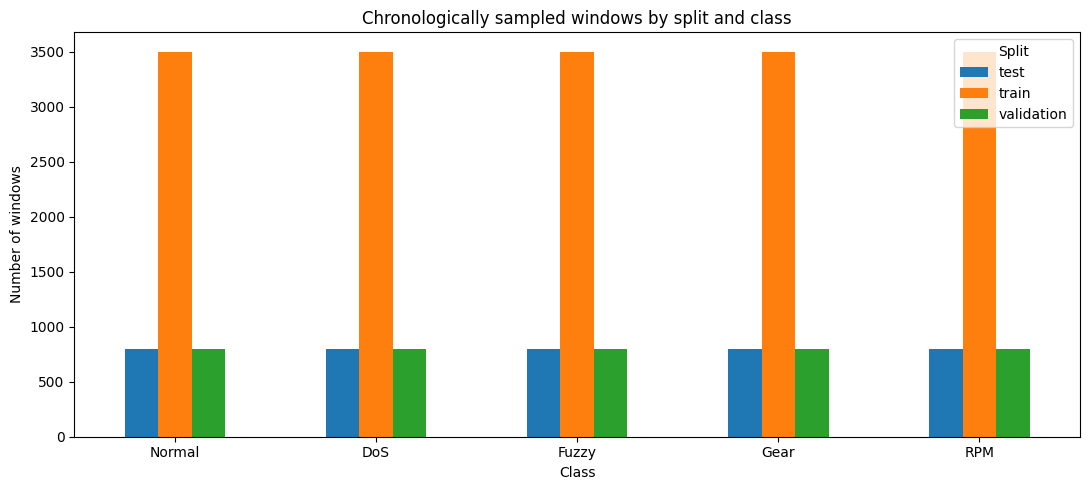

Saved: /kaggle/working/autospectra_outputs/plots/eda_01_split_class_counts.png


In [102]:
# EDA 1 — Window counts by chronological split and class
pivot_counts = (
    split_class_counts
    .pivot(index="Class", columns="Split", values="Windows")
    .reindex(CLASS_NAMES)
)

ax = pivot_counts.plot(kind="bar", figsize=(11, 5))
ax.set_title("Chronologically sampled windows by split and class")
ax.set_xlabel("Class")
ax.set_ylabel("Number of windows")
ax.tick_params(axis="x", rotation=0)
save_current_figure("eda_01_split_class_counts.png")

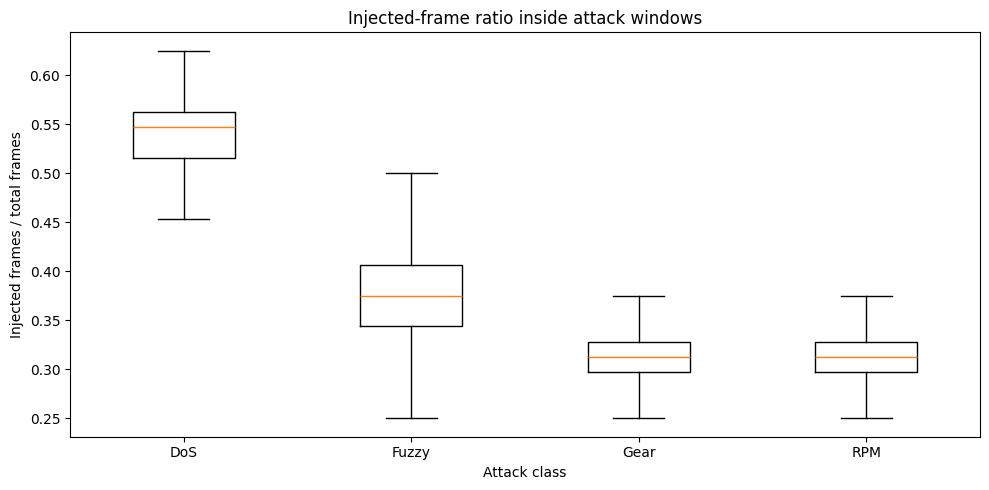

Saved: /kaggle/working/autospectra_outputs/plots/eda_02_attack_ratio_boxplot.png


,count,mean,median,min,max
class_name,,,,,
DoS,5100,0.537126,0.546875,0.015625,0.734375
Fuzzy,5100,0.377552,0.375000,0.015625,0.703125
Gear,5100,0.312947,0.312500,0.015625,0.484375
RPM,5100,0.315218,0.312500,0.015625,0.546875


In [103]:
# EDA 2 — Proportion of injected frames in attack-labelled windows
attack_metadata = pd.concat(
    [
        DATA[split]["metadata"].assign(dataset_split=split)
        for split in ["train", "validation", "test"]
    ],
    ignore_index=True,
)

attack_metadata = attack_metadata[
    attack_metadata["class_name"] != "Normal"
]

groups = [
    attack_metadata.loc[
        attack_metadata["class_name"] == class_name,
        "attack_ratio",
    ].to_numpy()
    for class_name in CLASS_NAMES[1:]
]

plt.figure(figsize=(10, 5))
plt.boxplot(
    groups,
    labels=CLASS_NAMES[1:],
    showfliers=False,
)
plt.title("Injected-frame ratio inside attack windows")
plt.xlabel("Attack class")
plt.ylabel("Injected frames / total frames")
save_current_figure("eda_02_attack_ratio_boxplot.png")

display(
    attack_metadata
    .groupby("class_name")["attack_ratio"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(CLASS_NAMES[1:])
)

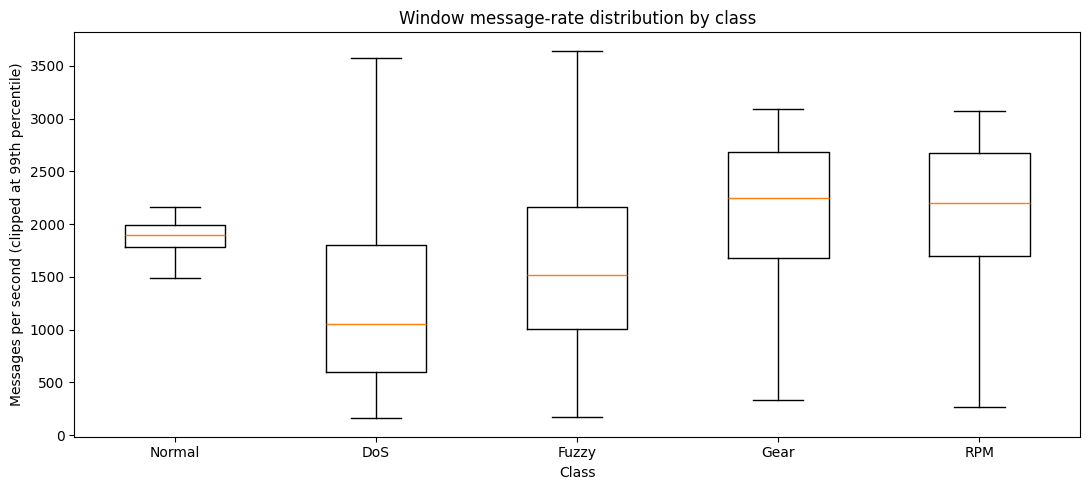

Saved: /kaggle/working/autospectra_outputs/plots/eda_03_message_rate_by_class.png


In [104]:
# EDA 3 — Message rate by class
groups = [
    train_feature_df.loc[
        train_feature_df["class_name"] == class_name,
        "message_rate_hz",
    ]
    .clip(
        upper=train_feature_df[
            "message_rate_hz"
        ].quantile(0.99)
    )
    .to_numpy()
    for class_name in CLASS_NAMES
]

plt.figure(figsize=(11, 5))
plt.boxplot(
    groups,
    labels=CLASS_NAMES,
    showfliers=False,
)
plt.title("Window message-rate distribution by class")
plt.xlabel("Class")
plt.ylabel(
    "Messages per second "
    "(clipped at 99th percentile)"
)
save_current_figure("eda_03_message_rate_by_class.png")

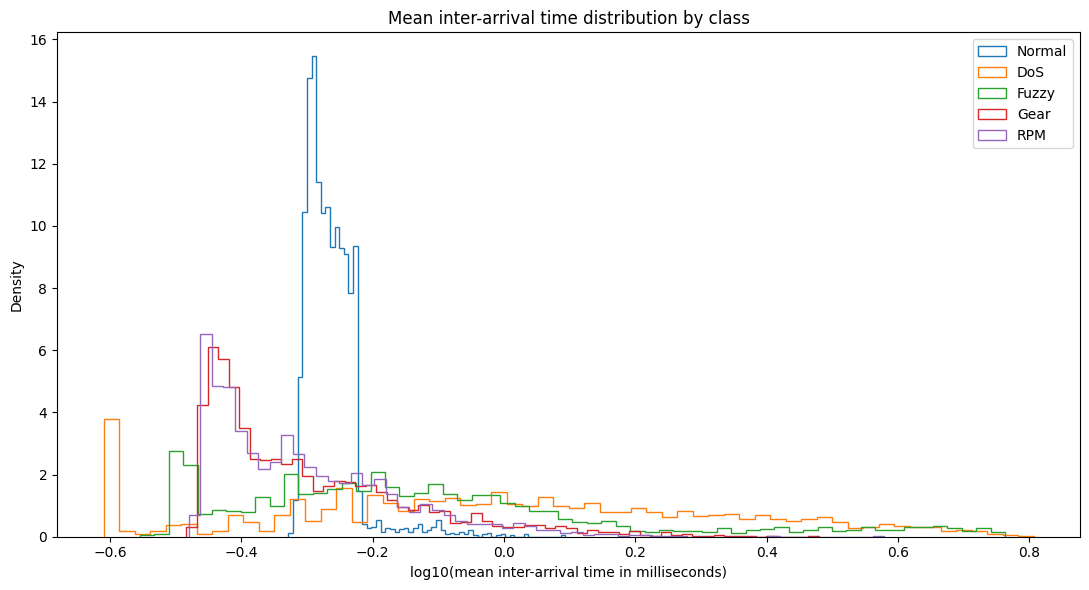

Saved: /kaggle/working/autospectra_outputs/plots/eda_04_inter_arrival_distribution.png


In [105]:
# EDA 4 — Inter-arrival-time distribution on a logarithmic x-axis
plt.figure(figsize=(11, 6))

for class_name in CLASS_NAMES:
    values = train_feature_df.loc[
        train_feature_df["class_name"] == class_name,
        "iat_mean_ms",
    ].to_numpy()

    values = np.clip(values, 1e-5, None)

    plt.hist(
        np.log10(values),
        bins=60,
        density=True,
        histtype="step",
        label=class_name,
    )

plt.title("Mean inter-arrival time distribution by class")
plt.xlabel(
    "log10(mean inter-arrival time in milliseconds)"
)
plt.ylabel("Density")
plt.legend()
save_current_figure("eda_04_inter_arrival_distribution.png")

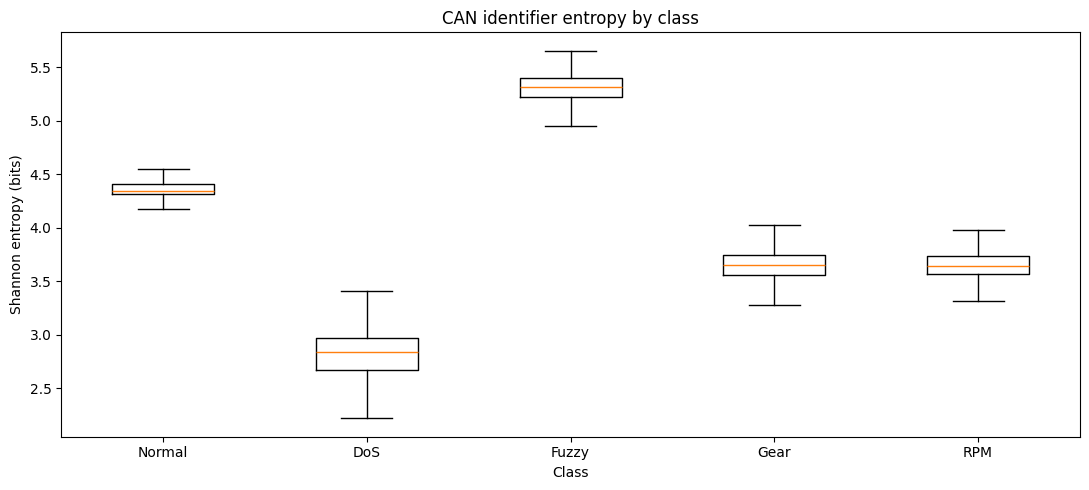

Saved: /kaggle/working/autospectra_outputs/plots/eda_05_can_id_entropy.png


In [106]:
# EDA 5 — CAN-ID entropy by class
groups = [
    train_feature_df.loc[
        train_feature_df["class_name"] == class_name,
        "id_entropy",
    ].to_numpy()
    for class_name in CLASS_NAMES
]

plt.figure(figsize=(11, 5))
plt.boxplot(
    groups,
    labels=CLASS_NAMES,
    showfliers=False,
)
plt.title("CAN identifier entropy by class")
plt.xlabel("Class")
plt.ylabel("Shannon entropy (bits)")
save_current_figure("eda_05_can_id_entropy.png")

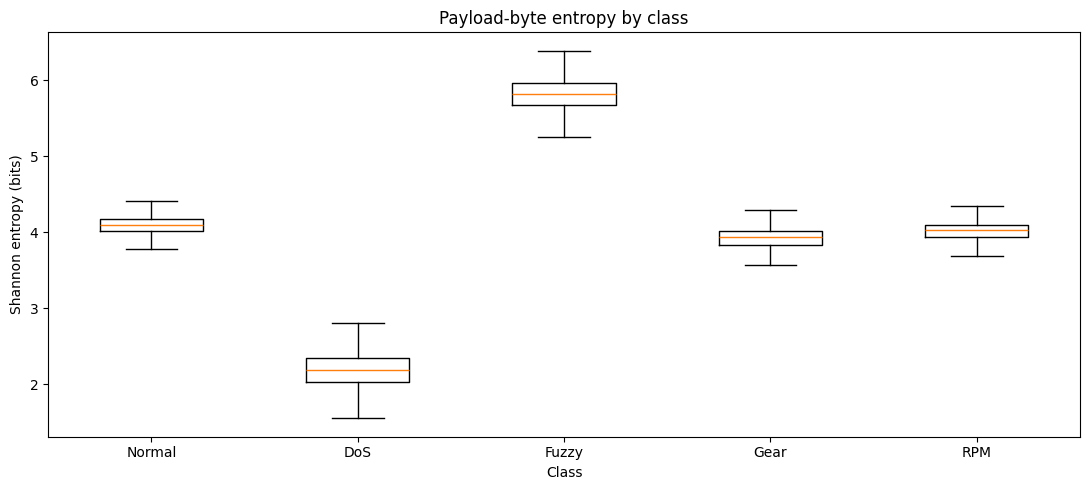

Saved: /kaggle/working/autospectra_outputs/plots/eda_06_payload_entropy.png


In [107]:
# EDA 6 — Payload entropy by class
groups = [
    train_feature_df.loc[
        train_feature_df["class_name"] == class_name,
        "payload_entropy",
    ].to_numpy()
    for class_name in CLASS_NAMES
]

plt.figure(figsize=(11, 5))
plt.boxplot(
    groups,
    labels=CLASS_NAMES,
    showfliers=False,
)
plt.title("Payload-byte entropy by class")
plt.xlabel("Class")
plt.ylabel("Shannon entropy (bits)")
save_current_figure("eda_06_payload_entropy.png")

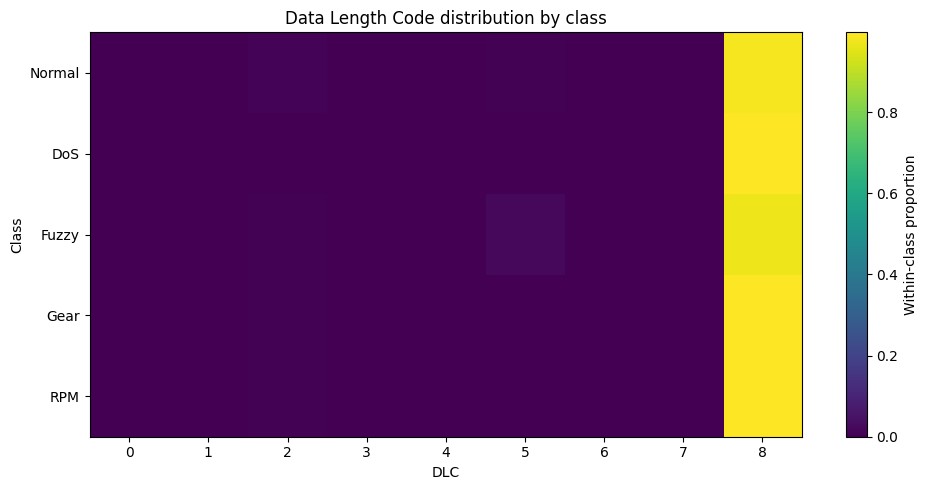

Saved: /kaggle/working/autospectra_outputs/plots/eda_07_dlc_heatmap.png


In [108]:
# EDA 7 — DLC distribution by class, reconstructed from sequences
dlc_counts = np.zeros(
    (len(CLASS_NAMES), 9),
    dtype=np.int64,
)

train_sequences_float = DATA[
    "train"
]["sequences"].astype(np.float32)

train_labels = DATA["train"]["labels"]

for class_index in range(len(CLASS_NAMES)):
    class_dlc = np.rint(
        train_sequences_float[
            train_labels == class_index,
            :,
            1,
        ]
        * 8
    ).astype(int)

    class_dlc = np.clip(class_dlc, 0, 8)

    dlc_counts[class_index] = np.bincount(
        class_dlc.ravel(),
        minlength=9,
    )

dlc_proportions = (
    dlc_counts
    / np.maximum(
        dlc_counts.sum(axis=1, keepdims=True),
        1,
    )
)

plt.figure(figsize=(10, 5))
image = plt.imshow(
    dlc_proportions,
    aspect="auto",
)
plt.colorbar(
    image,
    label="Within-class proportion",
)
plt.xticks(range(9), range(9))
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.title("Data Length Code distribution by class")
plt.xlabel("DLC")
plt.ylabel("Class")
save_current_figure("eda_07_dlc_heatmap.png")

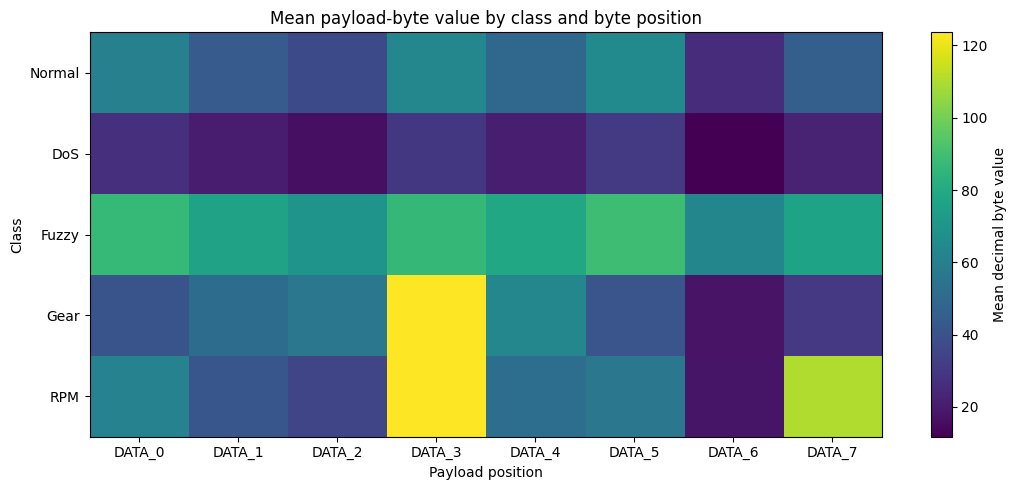

Saved: /kaggle/working/autospectra_outputs/plots/eda_08_payload_byte_heatmap.png


,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7
Normal,60.402325,43.743439,36.905544,63.521870,49.199104,64.681549,25.877453,45.814575
DoS,27.360792,20.864340,16.503315,29.698229,21.222218,30.941139,11.756817,23.052965
Fuzzy,86.516258,76.022743,69.838318,86.451126,78.367836,89.020638,63.167370,76.707382
Gear,40.601788,51.152508,55.983402,123.440086,63.747185,41.342873,17.799286,30.121141
RPM,61.241188,41.724205,35.072170,123.622704,52.326954,56.246628,18.066292,110.437546


In [109]:
# EDA 8 — Mean value of each payload-byte position by class
byte_means = np.zeros(
    (len(CLASS_NAMES), 8),
    dtype=np.float32,
)

for class_index in range(len(CLASS_NAMES)):
    class_sequences = train_sequences_float[
        train_labels == class_index
    ]

    byte_means[class_index] = (
        class_sequences[:, :, 2:10]
        .mean(axis=(0, 1))
        * 255.0
    )

plt.figure(figsize=(11, 5))
image = plt.imshow(
    byte_means,
    aspect="auto",
)
plt.colorbar(
    image,
    label="Mean decimal byte value",
)
plt.xticks(
    range(8),
    [f"DATA_{index}" for index in range(8)],
)
plt.yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
)
plt.title(
    "Mean payload-byte value "
    "by class and byte position"
)
plt.xlabel("Payload position")
plt.ylabel("Class")
save_current_figure("eda_08_payload_byte_heatmap.png")

display(
    pd.DataFrame(
        byte_means,
        index=CLASS_NAMES,
        columns=[f"DATA_{i}" for i in range(8)],
    )
)

,Class,Rank,CAN_ID,Count
0,Normal,1,0x316,12112
1,Normal,2,0x18F,12106
2,Normal,3,0x260,12095
3,Normal,4,0x2A0,12085
4,Normal,5,0x370,12068
5,Normal,6,0x43F,12061
6,Normal,7,0x2C0,12040
7,Normal,8,0x329,12036
8,Normal,9,0x002,12033
9,Normal,10,0x440,12031


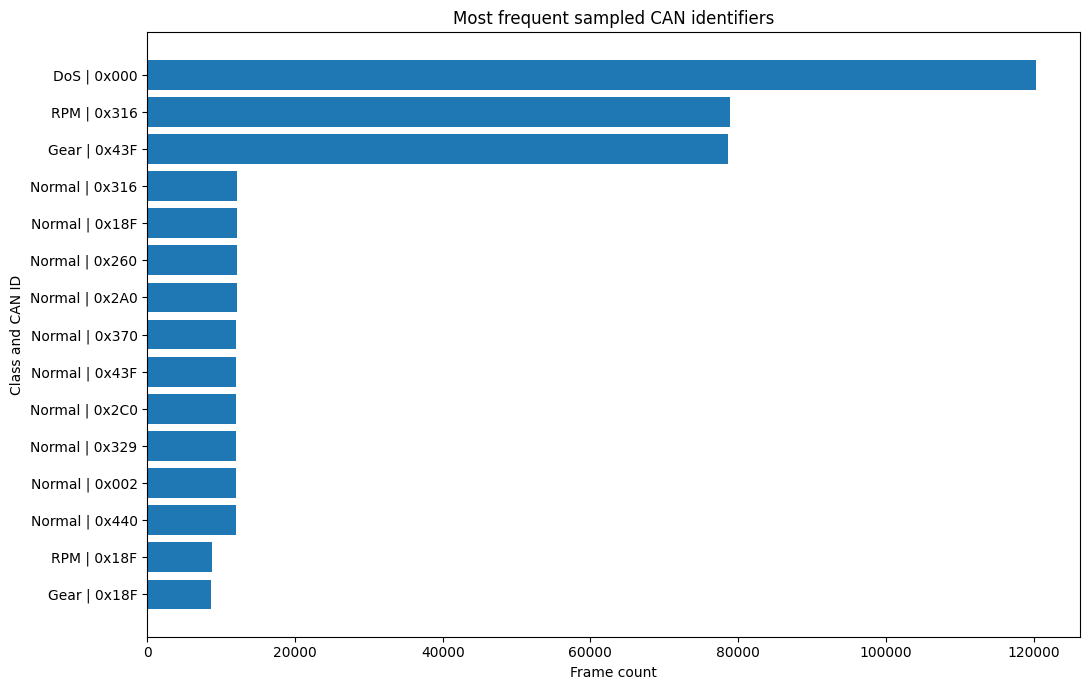

Saved: /kaggle/working/autospectra_outputs/plots/eda_09_top_can_ids.png


In [110]:
# EDA 9 — Most frequent CAN IDs in each class
top_id_rows = []

for class_index, class_name in enumerate(CLASS_NAMES):
    ids = np.rint(
        train_sequences_float[
            train_labels == class_index,
            :,
            0,
        ]
        * 2047
    ).astype(int).ravel()

    for rank, (can_id, count) in enumerate(
        Counter(ids).most_common(10),
        start=1,
    ):
        top_id_rows.append({
            "Class": class_name,
            "Rank": rank,
            "CAN_ID": f"0x{can_id:03X}",
            "Count": count,
        })

top_ids_df = pd.DataFrame(top_id_rows)
display(top_ids_df)

plot_top = (
    top_ids_df
    .assign(
        Class_ID=lambda frame:
            frame["Class"]
            + " | "
            + frame["CAN_ID"]
    )
    .sort_values("Count", ascending=False)
    .head(15)
    .sort_values("Count")
)

plt.figure(figsize=(11, 7))
plt.barh(
    plot_top["Class_ID"],
    plot_top["Count"],
)
plt.title("Most frequent sampled CAN identifiers")
plt.xlabel("Frame count")
plt.ylabel("Class and CAN ID")
save_current_figure("eda_09_top_can_ids.png")

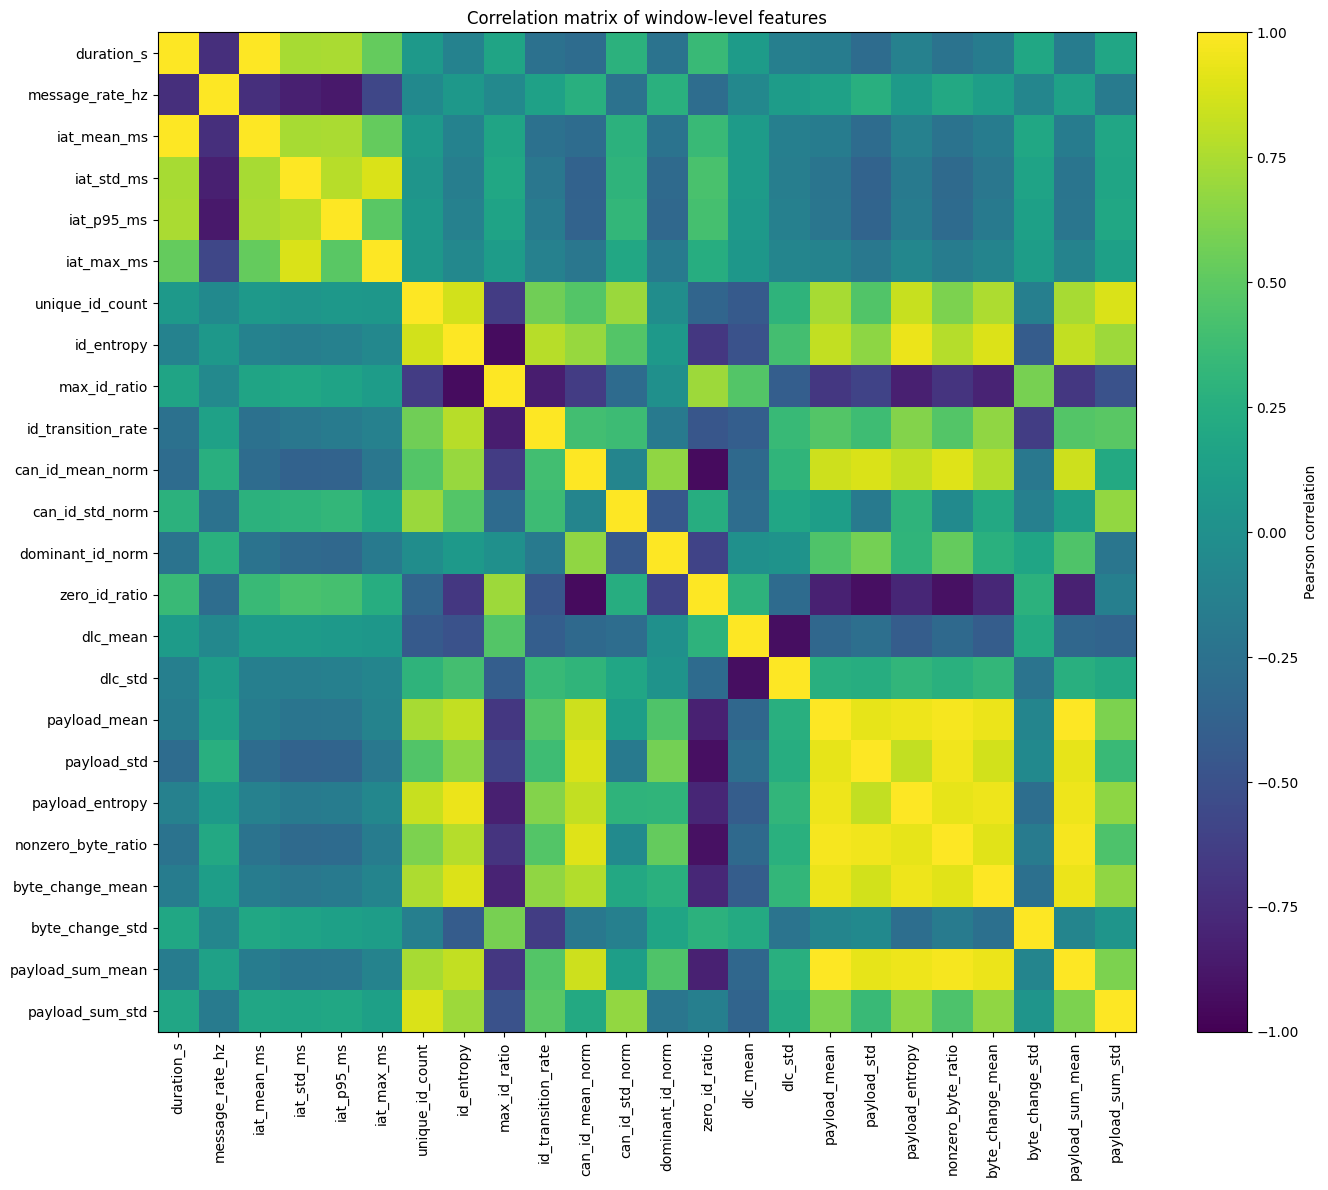

Saved: /kaggle/working/autospectra_outputs/plots/eda_10_feature_correlation.png


In [111]:
# EDA 10 — Correlation matrix for engineered features
correlation = train_feature_df[FEATURE_NAMES].corr()

plt.figure(figsize=(14, 12))
image = plt.imshow(
    correlation,
    aspect="auto",
    vmin=-1,
    vmax=1,
)
plt.colorbar(
    image,
    label="Pearson correlation",
)
plt.xticks(
    range(len(FEATURE_NAMES)),
    FEATURE_NAMES,
    rotation=90,
)
plt.yticks(
    range(len(FEATURE_NAMES)),
    FEATURE_NAMES,
)
plt.title("Correlation matrix of window-level features")
save_current_figure("eda_10_feature_correlation.png")

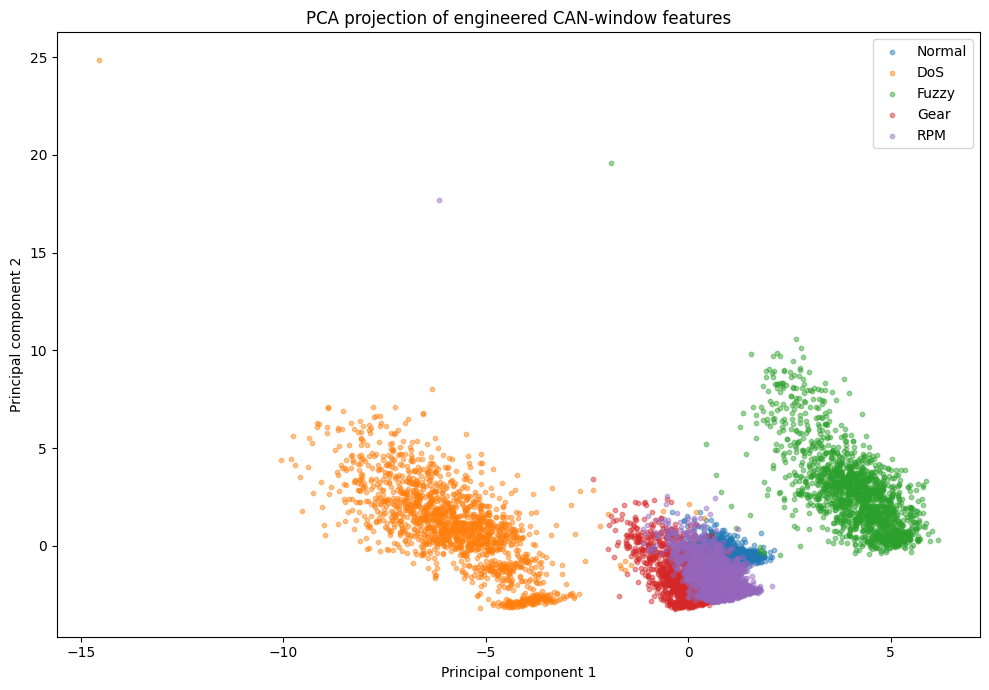

Saved: /kaggle/working/autospectra_outputs/plots/eda_11_pca_projection.png


In [112]:
# EDA 11 — Two-dimensional PCA projection of window features
sample_size = min(
    8_000,
    len(train_feature_df),
)

sample_indices = np.random.default_rng(
    SEED
).choice(
    len(train_feature_df),
    size=sample_size,
    replace=False,
)

X_pca_input = (
    train_feature_df
    .iloc[sample_indices][FEATURE_NAMES]
    .to_numpy()
)

y_pca = (
    train_feature_df
    .iloc[sample_indices]["class_name"]
    .to_numpy()
)

X_pca_scaled = StandardScaler().fit_transform(
    X_pca_input
)

projection = PCA(
    n_components=2,
    random_state=SEED,
).fit_transform(X_pca_scaled)

plt.figure(figsize=(10, 7))

for class_name in CLASS_NAMES:
    mask = y_pca == class_name

    plt.scatter(
        projection[mask, 0],
        projection[mask, 1],
        s=10,
        alpha=0.45,
        label=class_name,
    )

plt.title(
    "PCA projection of engineered "
    "CAN-window features"
)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.legend()
save_current_figure("eda_11_pca_projection.png")

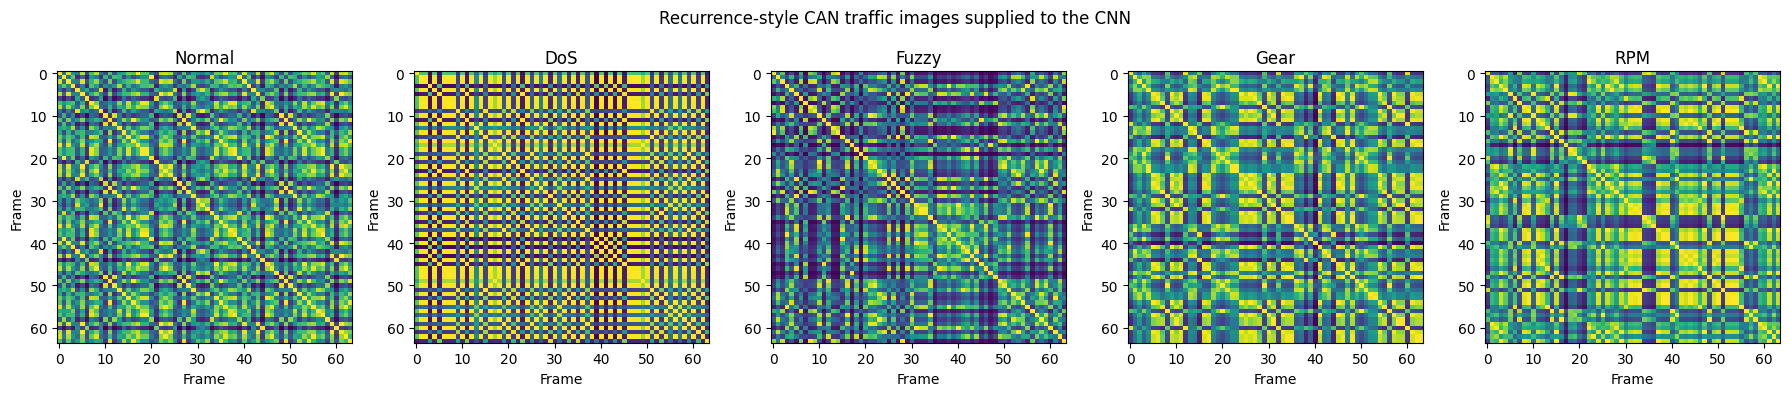

Saved: /kaggle/working/autospectra_outputs/plots/eda_12_recurrence_examples.png


In [113]:
# EDA 12 — Recurrence-style CAN image examples used by the CNN
def sequence_to_recurrence(
    sequence: np.ndarray,
    gamma: float = 8.0,
) -> np.ndarray:
    """
    Convert one [time, feature] CAN sequence into a recurrence image.

    The compact signal combines identifier, DLC, payload mean, and
    inter-arrival time. Pairwise absolute distance becomes similarity.
    """
    sequence = sequence.astype(np.float32)

    signal = (
        0.35 * sequence[:, 0]
        + 0.10 * sequence[:, 1]
        + 0.45 * sequence[:, 2:10].mean(axis=1)
        + 0.10 * sequence[:, 10]
    )

    distance = np.abs(
        signal[:, None]
        - signal[None, :]
    )

    return np.exp(
        -gamma * distance
    ).astype(np.float32)


fig, axes = plt.subplots(
    1,
    len(CLASS_NAMES),
    figsize=(18, 4),
)

for class_index, class_name in enumerate(CLASS_NAMES):
    example_index = int(
        np.flatnonzero(
            train_labels == class_index
        )[0]
    )

    recurrence = sequence_to_recurrence(
        DATA["train"]["sequences"][example_index]
    )

    axes[class_index].imshow(
        recurrence,
        aspect="auto",
    )
    axes[class_index].set_title(class_name)
    axes[class_index].set_xlabel("Frame")
    axes[class_index].set_ylabel("Frame")

fig.suptitle(
    "Recurrence-style CAN traffic images "
    "supplied to the CNN"
)

plt.tight_layout()

path = (
    PLOT_DIR
    / "eda_12_recurrence_examples.png"
)
plt.savefig(
    path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
print("Saved:", path)

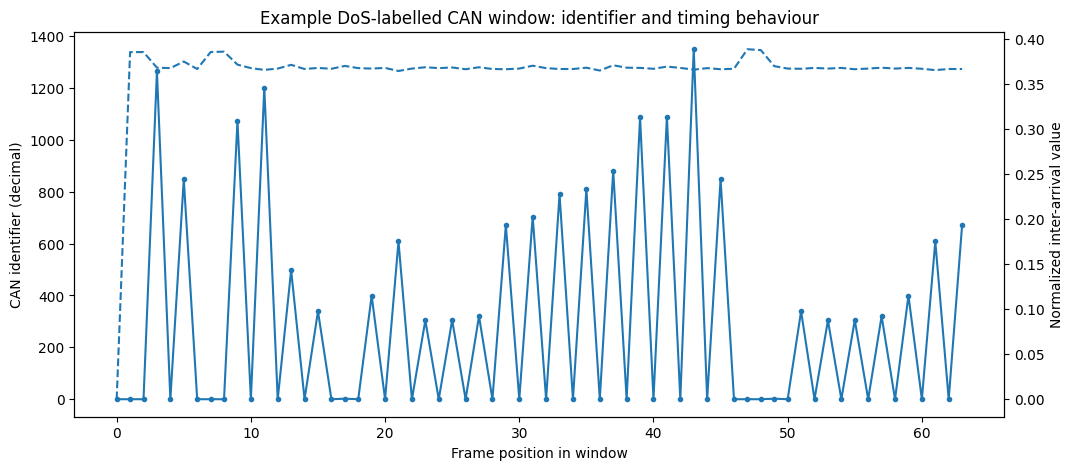

Saved: /kaggle/working/autospectra_outputs/plots/eda_13_dos_timeline.png


In [114]:
# EDA 13 — Example chronological window timeline
example_attack_index = int(
    np.flatnonzero(
        train_labels == CLASS_TO_INDEX["DoS"]
    )[0]
)

example_sequence = train_sequences_float[
    example_attack_index
]

frame_number = np.arange(WINDOW_SIZE)

can_id_values = np.rint(
    example_sequence[:, 0] * 2047
).astype(int)

inter_arrival_proxy = example_sequence[:, 10]

fig, first_axis = plt.subplots(
    figsize=(12, 5)
)

first_axis.plot(
    frame_number,
    can_id_values,
    marker=".",
    label="CAN ID",
)

first_axis.set_xlabel(
    "Frame position in window"
)
first_axis.set_ylabel(
    "CAN identifier (decimal)"
)

second_axis = first_axis.twinx()

second_axis.plot(
    frame_number,
    inter_arrival_proxy,
    linestyle="--",
    label="Log-scaled inter-arrival time",
)

second_axis.set_ylabel(
    "Normalized inter-arrival value"
)

plt.title(
    "Example DoS-labelled CAN window: "
    "identifier and timing behaviour"
)

path = PLOT_DIR / "eda_13_dos_timeline.png"

plt.savefig(
    path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
print("Saved:", path)

# Part B — Classical machine-learning baselines

Three tabular models are used:

1. **Logistic Regression:** transparent linear baseline.
2. **Random Forest:** proposal baseline and strong nonlinear model.
3. **Extra Trees:** additional tree-ensemble comparison.

All preprocessing is fitted on training data only. The validation split supports model comparison and fusion weighting. The test split is used for the final independent evaluation.

The metrics intentionally go beyond accuracy because normal traffic and attack traffic have unequal safety consequences.

In [115]:

# 7. Evaluation utilities


X_train_tab = DATA[
    "train"
]["features"].astype(np.float32)
y_train = DATA["train"]["labels"]

X_validation_tab = DATA[
    "validation"
]["features"].astype(np.float32)
y_validation = DATA["validation"]["labels"]

X_test_tab = DATA[
    "test"
]["features"].astype(np.float32)
y_test = DATA["test"]["labels"]

X_train_seq = DATA["train"]["sequences"]
X_validation_seq = DATA["validation"]["sequences"]
X_test_seq = DATA["test"]["sequences"]

evaluation_rows = []
prediction_store = {}


def expected_calibration_error(
    y_true,
    probabilities,
    bins: int = 10,
) -> float:
    """ECE based on confidence of the selected multiclass prediction."""
    predictions = probabilities.argmax(axis=1)
    confidences = probabilities.max(axis=1)
    correctness = predictions == y_true

    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0

    for lower, upper in zip(
        edges[:-1],
        edges[1:],
    ):
        if upper == 1.0:
            mask = (
                (confidences >= lower)
                & (confidences <= upper)
            )
        else:
            mask = (
                (confidences >= lower)
                & (confidences < upper)
            )

        if mask.any():
            bin_accuracy = correctness[mask].mean()
            bin_confidence = confidences[mask].mean()

            ece += (
                mask.mean()
                * abs(
                    bin_accuracy
                    - bin_confidence
                )
            )

    return float(ece)


def model_file_size_mb(path: Path) -> float:
    if path.exists():
        return path.stat().st_size / (1024 ** 2)
    return np.nan


def calculate_multiclass_metrics(
    model_name,
    y_true,
    probabilities,
    inference_seconds,
    model_size_mb=np.nan,
):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    observed_classes = set(np.unique(y_true))
    expected_classes = set(range(len(CLASS_NAMES)))

    if observed_classes != expected_classes:
        raise ValueError(
            f"{model_name}: test set class coverage is invalid. "
            f"Observed {sorted(observed_classes)}, "
            f"expected {sorted(expected_classes)}."
        )

    if probabilities.shape != (
        len(y_true),
        len(CLASS_NAMES),
    ):
        raise ValueError(
            f"{model_name}: probability shape "
            f"{probabilities.shape} does not match "
            f"({len(y_true)}, {len(CLASS_NAMES)})."
        )

    predictions = probabilities.argmax(axis=1)

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _,
    ) = precision_recall_fscore_support(
        y_true,
        predictions,
        labels=np.arange(len(CLASS_NAMES)),
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_true,
        predictions,
        average="weighted",
        zero_division=0,
    )

    binary_true = (
        y_true
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    binary_prediction = (
        predictions
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        binary_true,
        binary_prediction,
        labels=[0, 1],
    ).ravel()

    y_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    try:
        macro_roc_auc = roc_auc_score(
            y_true,
            probabilities,
            multi_class="ovr",
            average="macro",
        )
    except ValueError:
        macro_roc_auc = np.nan

    try:
        macro_pr_auc = average_precision_score(
            y_binary,
            probabilities,
            average="macro",
        )
    except ValueError:
        macro_pr_auc = np.nan

    row = {
        "Model": model_name,
        "Accuracy":
            accuracy_score(y_true, predictions),
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions,
            ),
        "Macro_Precision": macro_precision,
        "Macro_Recall": macro_recall,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1,
        "MCC":
            matthews_corrcoef(
                y_true,
                predictions,
            ),
        "Log_Loss":
            log_loss(
                y_true,
                probabilities,
                labels=np.arange(
                    len(CLASS_NAMES)
                ),
            ),
        "Macro_ROC_AUC_OVR": macro_roc_auc,
        "Macro_PR_AUC": macro_pr_auc,
        "Attack_FPR":
            fp / max(fp + tn, 1),
        "Attack_FNR":
            fn / max(fn + tp, 1),
        "ECE_10_bins":
            expected_calibration_error(
                y_true,
                probabilities,
                bins=10,
            ),
        "Inference_ms_per_window":
            inference_seconds
            * 1000.0
            / len(y_true),
        "Throughput_windows_per_second":
            len(y_true)
            / max(inference_seconds, 1e-9),
        "Model_Size_MB": model_size_mb,
    }

    return row, predictions


def plot_confusion(
    y_true,
    predictions,
    model_name,
):
    matrix = confusion_matrix(
        y_true,
        predictions,
        labels=np.arange(len(CLASS_NAMES)),
    )

    plt.figure(figsize=(8, 7))

    image = plt.imshow(
        matrix,
        aspect="auto",
    )

    plt.colorbar(
        image,
        label="Window count",
    )

    plt.xticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES,
        rotation=45,
    )

    plt.yticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES,
    )

    threshold = matrix.max() / 2.0

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            plt.text(
                column,
                row,
                f"{matrix[row, column]:,}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if matrix[row, column] > threshold
                    else "black"
                ),
            )

    plt.title(
        f"Confusion matrix — {model_name}"
    )
    plt.xlabel("Predicted class")
    plt.ylabel("True class")

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_confusion_{safe_name}.png"
    )


def plot_roc_curves(
    y_true,
    probabilities,
    model_name,
):
    y_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    plt.figure(figsize=(9, 7))

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):
        (
            false_positive_rate,
            true_positive_rate,
            _,
        ) = roc_curve(
            y_binary[:, class_index],
            probabilities[:, class_index],
        )

        curve_auc = auc(
            false_positive_rate,
            true_positive_rate,
        )

        plt.plot(
            false_positive_rate,
            true_positive_rate,
            label=(
                f"{class_name} "
                f"(AUC={curve_auc:.3f})"
            ),
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Chance",
    )

    plt.title(
        f"One-vs-rest ROC curves — {model_name}"
    )
    plt.xlabel("False-positive rate")
    plt.ylabel("True-positive rate")
    plt.legend()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_roc_{safe_name}.png"
    )


def plot_precision_recall_curves(
    y_true,
    probabilities,
    model_name,
):
    y_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    plt.figure(figsize=(9, 7))

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):
        precision, recall, _ = precision_recall_curve(
            y_binary[:, class_index],
            probabilities[:, class_index],
        )

        curve_auc = auc(
            recall,
            precision,
        )

        plt.plot(
            recall,
            precision,
            label=(
                f"{class_name} "
                f"(AUC={curve_auc:.3f})"
            ),
        )

    plt.title(
        "One-vs-rest precision–recall curves "
        f"— {model_name}"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_pr_{safe_name}.png"
    )


def plot_reliability(
    y_true,
    probabilities,
    model_name,
    bins=10,
):
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    correctness = (
        predictions == y_true
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        bins + 1,
    )

    mean_confidence = []
    empirical_accuracy = []

    for lower, upper in zip(
        edges[:-1],
        edges[1:],
    ):
        if upper == 1.0:
            mask = (
                (confidence >= lower)
                & (confidence <= upper)
            )
        else:
            mask = (
                (confidence >= lower)
                & (confidence < upper)
            )

        if mask.any():
            mean_confidence.append(
                confidence[mask].mean()
            )
            empirical_accuracy.append(
                correctness[mask].mean()
            )

    plt.figure(figsize=(7, 6))

    plt.plot(
        mean_confidence,
        empirical_accuracy,
        marker="o",
        label=model_name,
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    plt.title(
        f"Reliability diagram — {model_name}"
    )
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Observed accuracy")
    plt.legend()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_calibration_{safe_name}.png"
    )


def evaluate_and_store(
    model_name,
    y_true,
    probabilities,
    inference_seconds,
    model_path=None,
    make_all_plots=True,
):
    size_mb = (
        model_file_size_mb(model_path)
        if model_path
        else np.nan
    )

    metric_row, predictions = (
        calculate_multiclass_metrics(
            model_name,
            y_true,
            probabilities,
            inference_seconds,
            size_mb,
        )
    )

    evaluation_rows.append(metric_row)

    prediction_store[model_name] = {
        "probabilities": probabilities,
        "predictions": predictions,
    }

    print(f"\n{model_name}")
    print("-" * len(model_name))

    display(
        pd.DataFrame([metric_row])
        .T
        .rename(columns={0: "Value"})
    )

    display(
        pd.DataFrame(
            classification_report(
                y_true,
                predictions,
                labels=np.arange(
                    len(CLASS_NAMES)
                ),
                target_names=CLASS_NAMES,
                output_dict=True,
                zero_division=0,
            )
        ).T
    )

    plot_confusion(
        y_true,
        predictions,
        model_name,
    )

    if make_all_plots:
        plot_roc_curves(
            y_true,
            probabilities,
            model_name,
        )

        plot_precision_recall_curves(
            y_true,
            probabilities,
            model_name,
        )

        plot_reliability(
            y_true,
            probabilities,
            model_name,
        )

    return metric_row, predictions


Training Logistic Regression...

Logistic Regression
-------------------


,Value
Model,Logistic Regression
Accuracy,0.9965
Balanced_Accuracy,0.9965
Macro_Precision,0.99656
Macro_Recall,0.9965
Macro_F1,0.996511
Weighted_F1,0.996511
MCC,0.995635
Log_Loss,0.018683
Macro_ROC_AUC_OVR,0.999544


,precision,recall,f1-score,support
Normal,0.982801,1.0000,0.991326,800.0000
DoS,1.000000,0.9950,0.997494,800.0000
Fuzzy,1.000000,0.9950,0.997494,800.0000
Gear,1.000000,0.9950,0.997494,800.0000
RPM,1.000000,0.9975,0.998748,800.0000
accuracy,0.996500,0.9965,0.996500,0.9965
macro avg,0.996560,0.9965,0.996511,4000.0000
weighted avg,0.996560,0.9965,0.996511,4000.0000


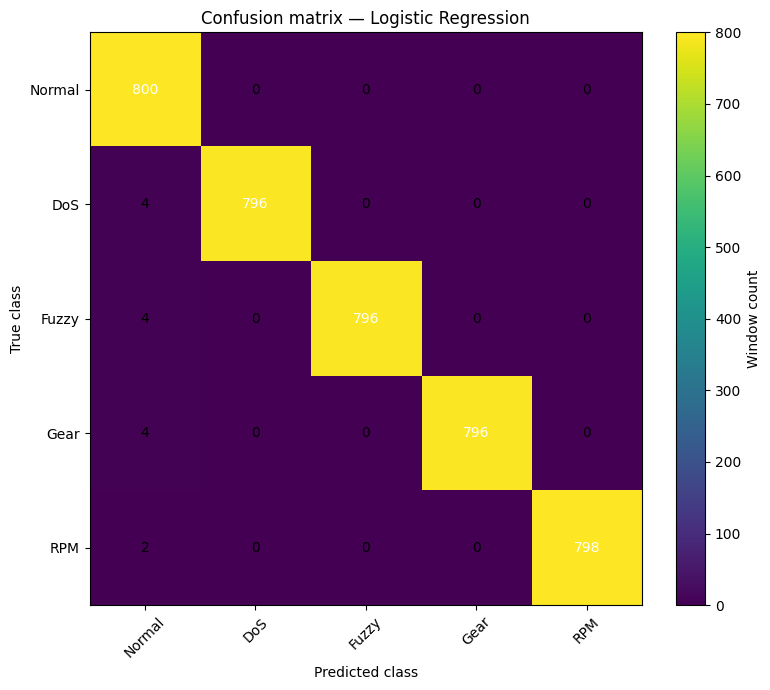

Saved: /kaggle/working/autospectra_outputs/plots/metrics_confusion_logistic_regression.png

Training Random Forest...

Random Forest
-------------


,Value
Model,Random Forest
Accuracy,0.99775
Balanced_Accuracy,0.99775
Macro_Precision,0.997775
Macro_Recall,0.99775
Macro_F1,0.997754
Weighted_F1,0.997754
MCC,0.997192
Log_Loss,0.033783
Macro_ROC_AUC_OVR,0.999475


,precision,recall,f1-score,support
Normal,0.988875,1.00000,0.994406,800.00000
DoS,1.000000,1.00000,1.000000,800.00000
Fuzzy,1.000000,0.99500,0.997494,800.00000
Gear,1.000000,0.99625,0.998121,800.00000
RPM,1.000000,0.99750,0.998748,800.00000
accuracy,0.997750,0.99775,0.997750,0.99775
macro avg,0.997775,0.99775,0.997754,4000.00000
weighted avg,0.997775,0.99775,0.997754,4000.00000


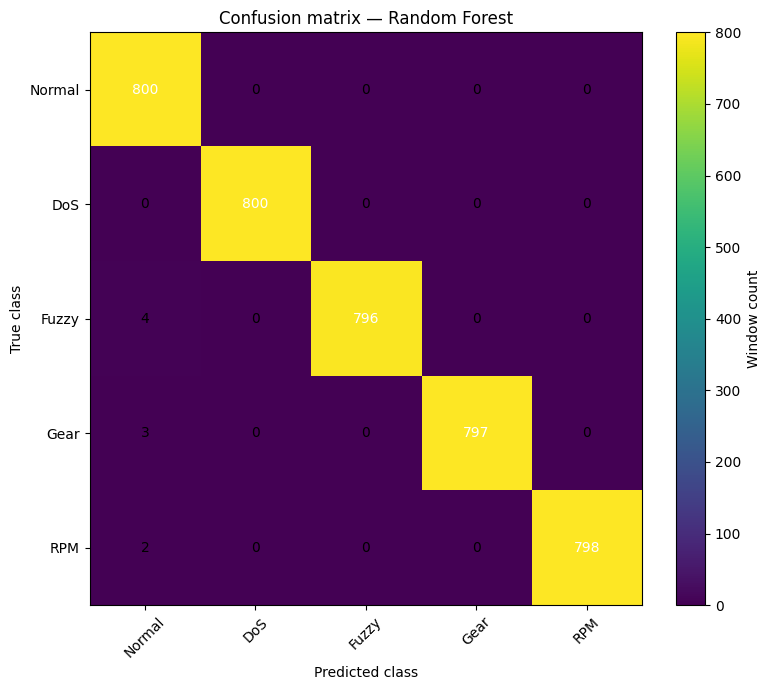

Saved: /kaggle/working/autospectra_outputs/plots/metrics_confusion_random_forest.png


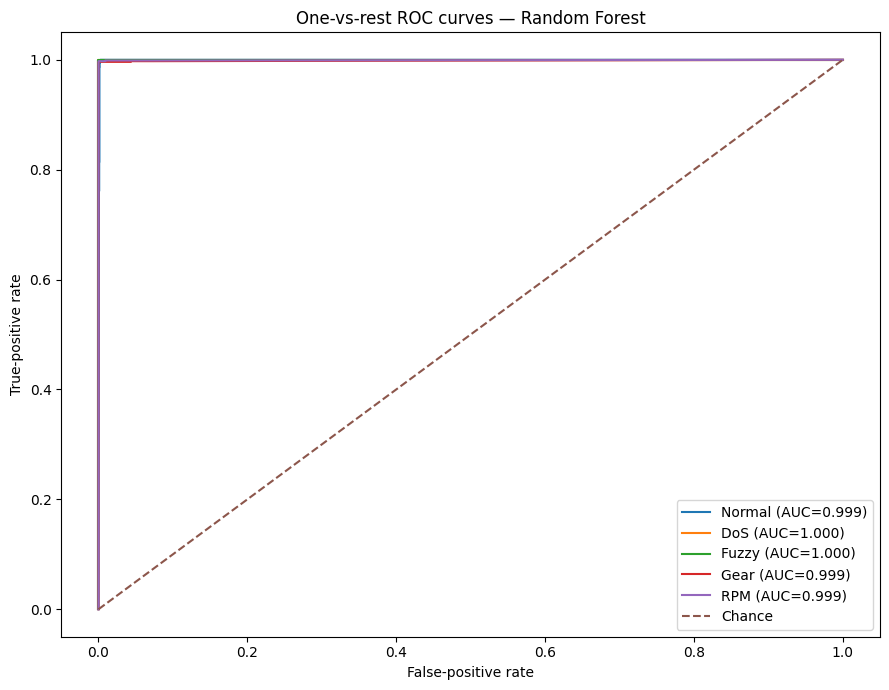

Saved: /kaggle/working/autospectra_outputs/plots/metrics_roc_random_forest.png


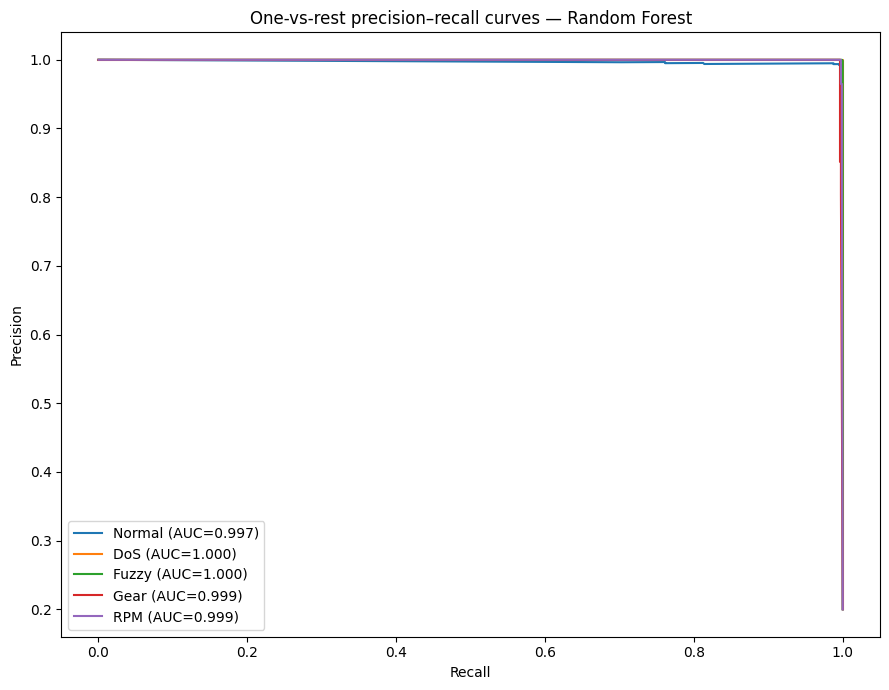

Saved: /kaggle/working/autospectra_outputs/plots/metrics_pr_random_forest.png


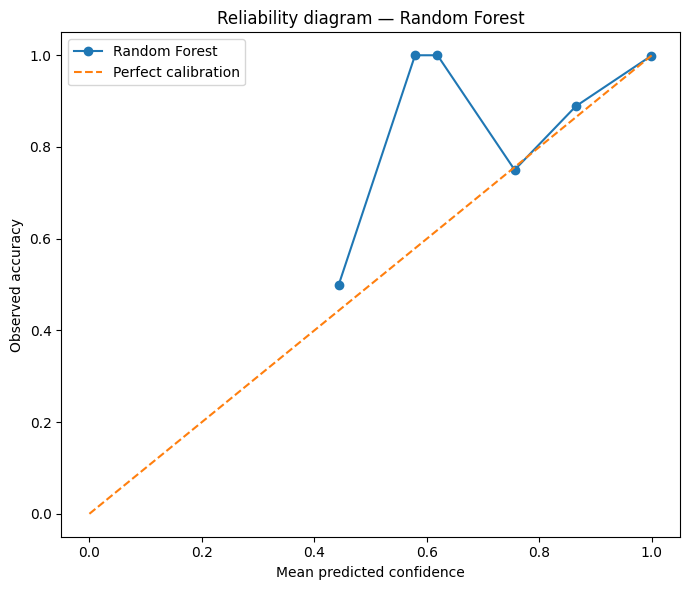

Saved: /kaggle/working/autospectra_outputs/plots/metrics_calibration_random_forest.png

Training Extra Trees...

Extra Trees
-----------


,Value
Model,Extra Trees
Accuracy,0.99725
Balanced_Accuracy,0.99725
Macro_Precision,0.997287
Macro_Recall,0.99725
Macro_F1,0.997256
Weighted_F1,0.997256
MCC,0.996569
Log_Loss,0.021083
Macro_ROC_AUC_OVR,0.999651


,precision,recall,f1-score,support
Normal,0.986436,1.00000,0.993172,800.00000
DoS,1.000000,0.99875,0.999375,800.00000
Fuzzy,1.000000,0.99500,0.997494,800.00000
Gear,1.000000,0.99500,0.997494,800.00000
RPM,1.000000,0.99750,0.998748,800.00000
accuracy,0.997250,0.99725,0.997250,0.99725
macro avg,0.997287,0.99725,0.997256,4000.00000
weighted avg,0.997287,0.99725,0.997256,4000.00000


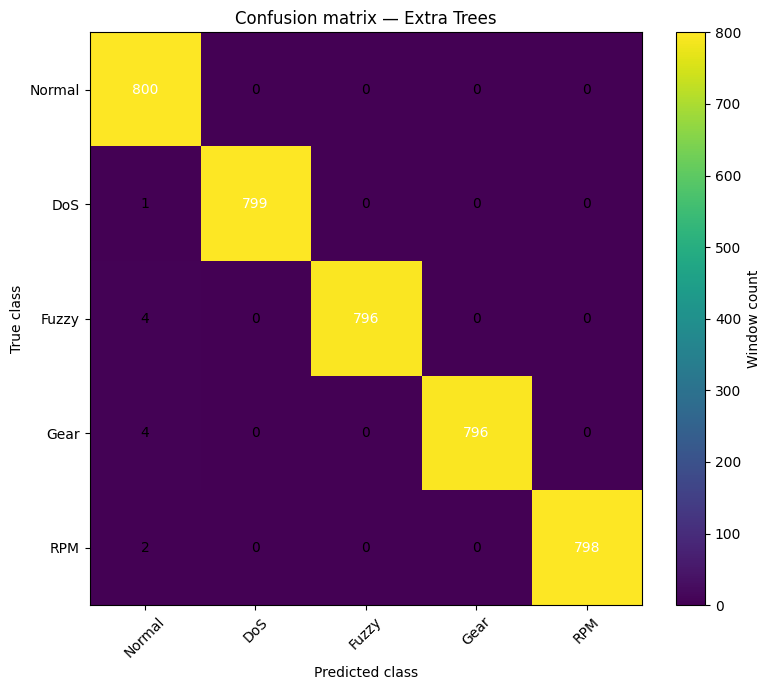

Saved: /kaggle/working/autospectra_outputs/plots/metrics_confusion_extra_trees.png

Training XGBoost...

XGBoost
-------


,Value
Model,XGBoost
Accuracy,0.99775
Balanced_Accuracy,0.99775
Macro_Precision,0.997775
Macro_Recall,0.99775
Macro_F1,0.997754
Weighted_F1,0.997754
MCC,0.997192
Log_Loss,0.012293
Macro_ROC_AUC_OVR,0.999828


,precision,recall,f1-score,support
Normal,0.988875,1.00000,0.994406,800.00000
DoS,1.000000,1.00000,1.000000,800.00000
Fuzzy,1.000000,0.99500,0.997494,800.00000
Gear,1.000000,0.99625,0.998121,800.00000
RPM,1.000000,0.99750,0.998748,800.00000
accuracy,0.997750,0.99775,0.997750,0.99775
macro avg,0.997775,0.99775,0.997754,4000.00000
weighted avg,0.997775,0.99775,0.997754,4000.00000


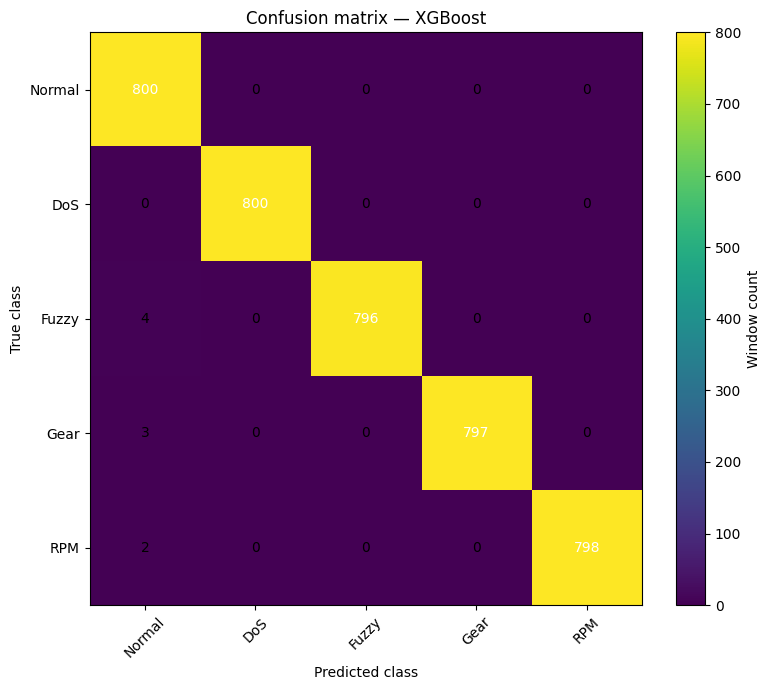

Saved: /kaggle/working/autospectra_outputs/plots/metrics_confusion_xgboost.png


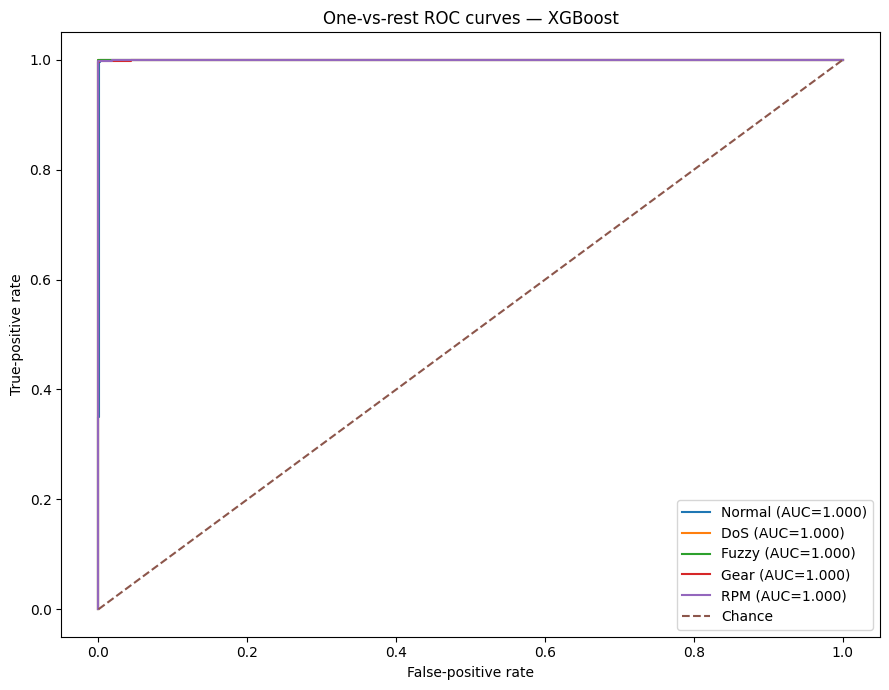

Saved: /kaggle/working/autospectra_outputs/plots/metrics_roc_xgboost.png


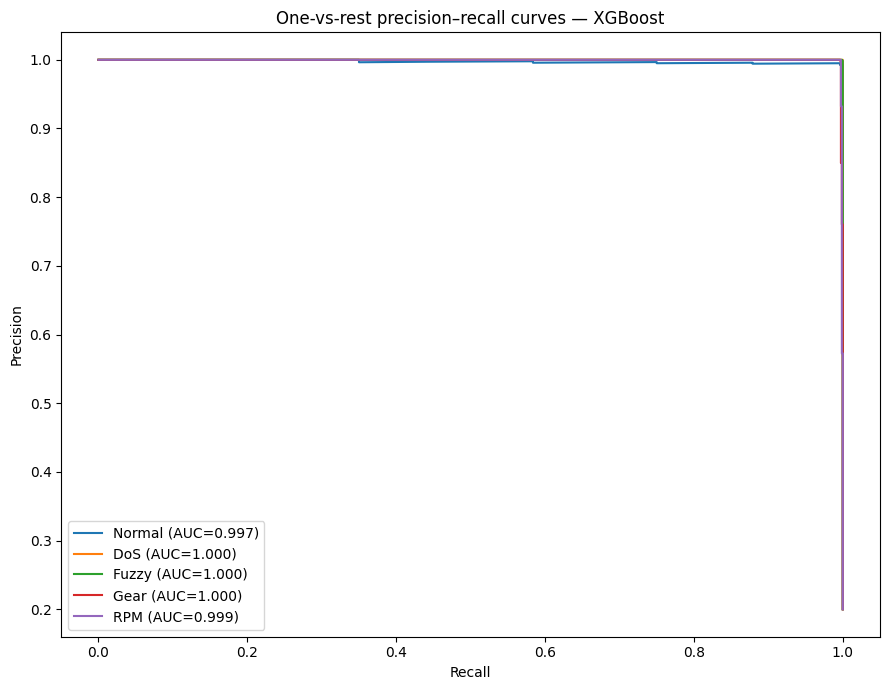

Saved: /kaggle/working/autospectra_outputs/plots/metrics_pr_xgboost.png


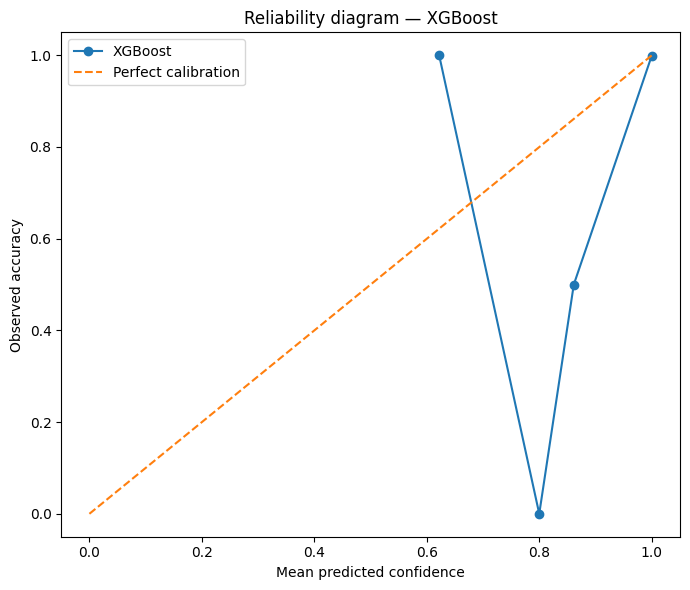

Saved: /kaggle/working/autospectra_outputs/plots/metrics_calibration_xgboost.png


88927

In [116]:

# 8. Train classical models


classical_models = {
    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=SEED,
            ),
        ),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=RF_TREES,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=ET_TREES,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    ),
}


if RUN_XGBOOST and XGBOOST_AVAILABLE:
    classical_models["XGBoost"] = XGBClassifier(
        n_estimators=XGB_TREES,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.10,
        reg_lambda=2.0,
        gamma=0.0,
        objective="multi:softprob",
        num_class=len(CLASS_NAMES),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
    )
elif RUN_XGBOOST:
    print(
        "RUN_XGBOOST=True, but xgboost could not be imported. "
        "The remaining models will still run."
    )

classical_validation_probabilities = {}
classical_test_probabilities = {}

for model_name, model in classical_models.items():
    print(f"\nTraining {model_name}...")

    fit_start = time.perf_counter()
    model.fit(X_train_tab, y_train)
    fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    model_path = (
        MODEL_DIR
        / (
            model_name
            .lower()
            .replace(" ", "_")
            + ".joblib"
        )
    )

    joblib.dump(
        model,
        model_path,
    )

    validation_probabilities = (
        model.predict_proba(
            X_validation_tab
        )
    )

    classical_validation_probabilities[
        model_name
    ] = validation_probabilities

    inference_start = time.perf_counter()

    test_probabilities = model.predict_proba(
        X_test_tab
    )

    inference_seconds = (
        time.perf_counter()
        - inference_start
    )

    classical_test_probabilities[
        model_name
    ] = test_probabilities

    metric_row, _ = evaluate_and_store(
        model_name=model_name,
        y_true=y_test,
        probabilities=test_probabilities,
        inference_seconds=inference_seconds,
        model_path=model_path,
        make_all_plots=(
            model_name
            in {"Random Forest", "XGBoost"}
        ),
    )

    metric_row[
        "Training_Seconds"
    ] = fit_seconds

gc.collect()

,Feature,Importance
0,dominant_id_norm,0.131709
1,id_entropy,0.087295
2,max_id_ratio,0.079569
3,payload_sum_mean,0.072686
4,payload_mean,0.067188
5,zero_id_ratio,0.064837
6,id_transition_rate,0.064477
7,payload_std,0.064047
8,payload_entropy,0.063848
9,unique_id_count,0.063702


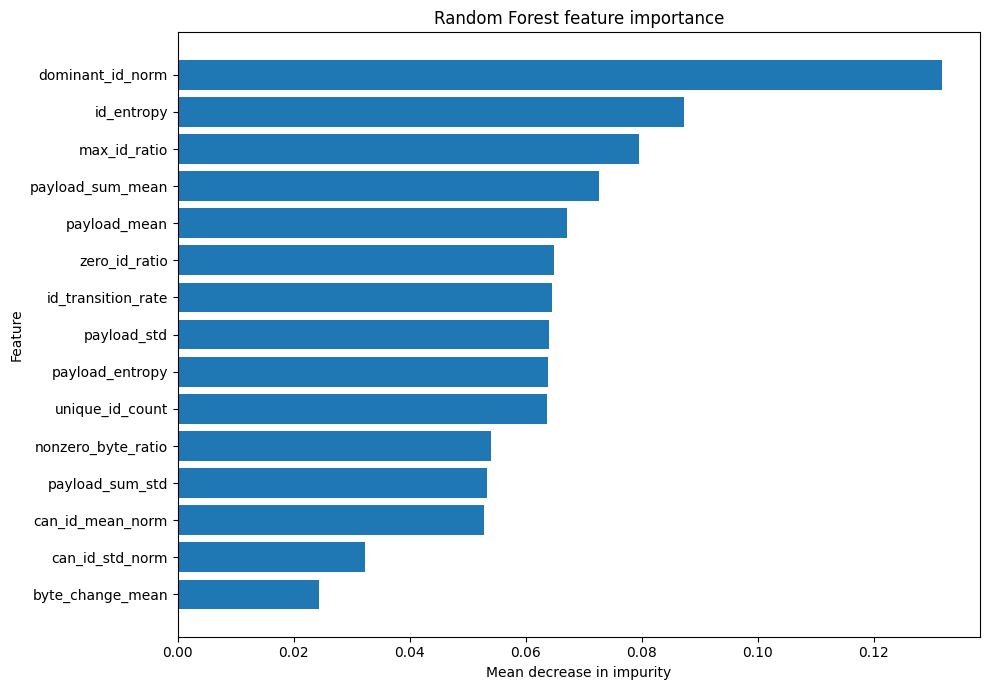

Saved: /kaggle/working/autospectra_outputs/plots/model_random_forest_feature_importance.png


In [117]:
# Random Forest feature importance
random_forest = classical_models[
    "Random Forest"
]

importance_df = (
    pd.DataFrame({
        "Feature": FEATURE_NAMES,
        "Importance":
            random_forest.feature_importances_,
    })
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(importance_df)

plot_importance = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))
plt.barh(
    plot_importance["Feature"],
    plot_importance["Importance"],
)
plt.title("Random Forest feature importance")
plt.xlabel("Mean decrease in impurity")
plt.ylabel("Feature")
save_current_figure(
    "model_random_forest_feature_importance.png"
)

# Part C — Deep-learning models

## CNN: recurrence-style computer vision

Each CAN window becomes a square image whose pixels represent pairwise similarity between positions in a compact traffic signal. Repeated identifiers, payload patterns, and timing behaviour create recurring visual structures.

## LSTM: sequential modelling

The LSTM consumes the ordered sequence directly and can model dependencies among identifiers, payload bytes, DLC, and inter-arrival time.

Both models use:

- Cross-entropy loss.
- AdamW optimisation.
- Validation macro-F1 for early stopping.
- The same chronological train/validation/test windows.

In [143]:

# 9. PyTorch datasets and model definitions


class CANSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        sequence = torch.from_numpy(
            self.sequences[index].astype(np.float32)
        )
        label = torch.tensor(
            int(self.labels[index]),
            dtype=torch.long,
        )
        return sequence, label


class CANRecurrenceDataset(Dataset):
    def __init__(self, sequences, labels, gamma=8.0):
        self.sequences = sequences
        self.labels = labels
        self.gamma = gamma

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        sequence = torch.from_numpy(
            self.sequences[index].astype(np.float32)
        )

        signal = (
            0.35 * sequence[:, 0]
            + 0.10 * sequence[:, 1]
            + 0.45 * sequence[:, 2:10].mean(dim=1)
            + 0.10 * sequence[:, 10]
        )

        distance = torch.abs(
            signal[:, None]
            - signal[None, :]
        )

        image = torch.exp(
            -self.gamma * distance
        ).unsqueeze(0)

        label = torch.tensor(
            int(self.labels[index]),
            dtype=torch.long,
        )

        return image, label


class RecurrenceCNN(nn.Module):
    def __init__(
        self,
        number_of_classes=len(CLASS_NAMES),
    ):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(
                64,
                number_of_classes,
            ),
        )

    def forward(self, inputs):
        return self.classifier(
            self.features(inputs)
        )


class CANLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size=11,
        hidden_size=64,
        number_of_classes=len(CLASS_NAMES),
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Dropout(0.25),
            nn.Linear(
                hidden_size * 2,
                number_of_classes,
            ),
        )

    def forward(self, inputs):
        outputs, _ = self.lstm(inputs)
        representation = outputs.mean(dim=1)
        return self.classifier(representation)


def create_loader(
    dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

In [161]:

# 10. Generic classifier training and probability prediction


def probabilities_from_torch_model(
    model,
    loader,
):
    model.eval()

    probability_batches = []
    label_batches = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(inputs)

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            probability_batches.append(
                probabilities.cpu().numpy()
            )

            label_batches.append(
                labels.numpy()
            )

    return (
        np.concatenate(probability_batches),
        np.concatenate(label_batches),
    )


def train_torch_classifier(
    model,
    train_loader,
    validation_loader,
    model_name,
    epochs=CLASSIFIER_EPOCHS,
):
    class_values = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=class_values,
        y=y_train,
    )

    complete_weights = np.ones(
        len(CLASS_NAMES),
        dtype=np.float32,
    )

    complete_weights[
        class_values
    ] = weights.astype(np.float32)

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(
            complete_weights,
            device=DEVICE,
        ),
        label_smoothing=0.02,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4,
    )

    model = model.to(DEVICE)

    best_state = None
    best_macro_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        seen = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(
                DEVICE,
                non_blocking=True,
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=2.0,
            )

            optimizer.step()

            running_loss += (
                loss.item()
                * len(labels)
            )

            seen += len(labels)

        (
            validation_probabilities,
            validation_labels,
        ) = probabilities_from_torch_model(
            model,
            validation_loader,
        )

        validation_predictions = (
            validation_probabilities.argmax(
                axis=1
            )
        )

        validation_macro_f1 = f1_score(
            validation_labels,
            validation_predictions,
            average="macro",
            zero_division=0,
        )

        epoch_loss = (
            running_loss
            / max(seen, 1)
        )

        history.append({
            "epoch": epoch,
            "training_loss": epoch_loss,
            "validation_macro_f1":
                validation_macro_f1,
        })

        print(
            f"{model_name} | "
            f"epoch {epoch:02d} | "
            f"loss {epoch_loss:.4f} | "
            f"validation macro-F1 "
            f"{validation_macro_f1:.4f}"
        )

        if (
            validation_macro_f1
            > best_macro_f1 + 1e-4
        ):
            best_macro_f1 = (
                validation_macro_f1
            )

            best_state = {
                key:
                    value
                    .detach()
                    .cpu()
                    .clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    return model, pd.DataFrame(history)


def plot_training_history(
    history,
    model_name,
):
    fig, first_axis = plt.subplots(
        figsize=(9, 5)
    )

    first_axis.plot(
        history["epoch"],
        history["training_loss"],
        marker="o",
        label="Training loss",
    )

    first_axis.set_xlabel("Epoch")
    first_axis.set_ylabel(
        "Cross-entropy loss"
    )

    second_axis = first_axis.twinx()

    second_axis.plot(
        history["epoch"],
        history["validation_macro_f1"],
        marker="s",
        linestyle="--",
        label="Validation macro-F1",
    )

    second_axis.set_ylabel(
        "Validation macro-F1"
    )

    plt.title(
        f"Training history — {model_name}"
    )

    path = (
        PLOT_DIR
        / (
            "training_"
            + model_name
            .lower()
            .replace(" ", "_")
            + ".png"
        )
    )

    plt.savefig(
        path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()
    print("Saved:", path)

Recurrence CNN | epoch 01 | loss 0.7663 | validation macro-F1 0.8633
Recurrence CNN | epoch 02 | loss 0.4022 | validation macro-F1 0.7134
Recurrence CNN | epoch 03 | loss 0.2847 | validation macro-F1 0.8694
Recurrence CNN | epoch 04 | loss 0.2369 | validation macro-F1 0.9763
Recurrence CNN | epoch 05 | loss 0.2201 | validation macro-F1 0.9767
Recurrence CNN | epoch 06 | loss 0.2042 | validation macro-F1 0.9508
Recurrence CNN | epoch 07 | loss 0.1949 | validation macro-F1 0.9805
Recurrence CNN | epoch 08 | loss 0.1888 | validation macro-F1 0.9508


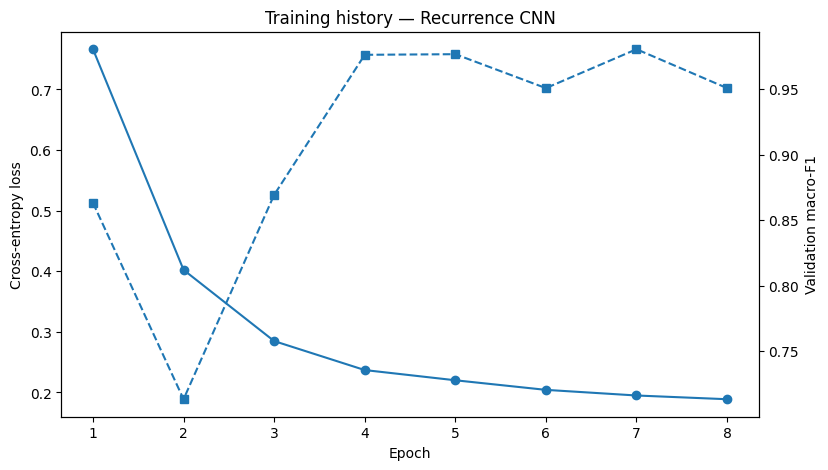

Saved: /kaggle/working/autospectra_outputs/plots/training_recurrence_cnn.png

Recurrence CNN
--------------


,Value
Model,Recurrence CNN
Accuracy,0.9805
Balanced_Accuracy,0.9805
Macro_Precision,0.980952
Macro_Recall,0.9805
Macro_F1,0.980563
Weighted_F1,0.980563
MCC,0.975707
Log_Loss,0.09252
Macro_ROC_AUC_OVR,0.998903


,precision,recall,f1-score,support
Normal,0.967153,0.99375,0.980271,800.0000
DoS,1.000000,0.97625,0.987982,800.0000
Fuzzy,0.993695,0.98500,0.989328,800.0000
Gear,0.951632,0.98375,0.967425,800.0000
RPM,0.992278,0.96375,0.977806,800.0000
accuracy,0.980500,0.98050,0.980500,0.9805
macro avg,0.980952,0.98050,0.980563,4000.0000
weighted avg,0.980952,0.98050,0.980563,4000.0000


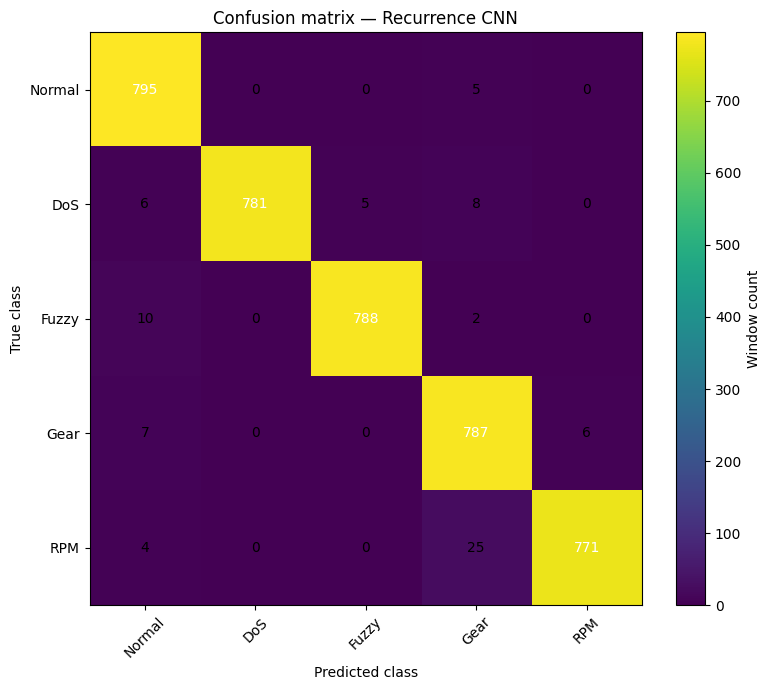

Saved: /kaggle/working/autospectra_outputs/plots/metrics_confusion_recurrence_cnn.png


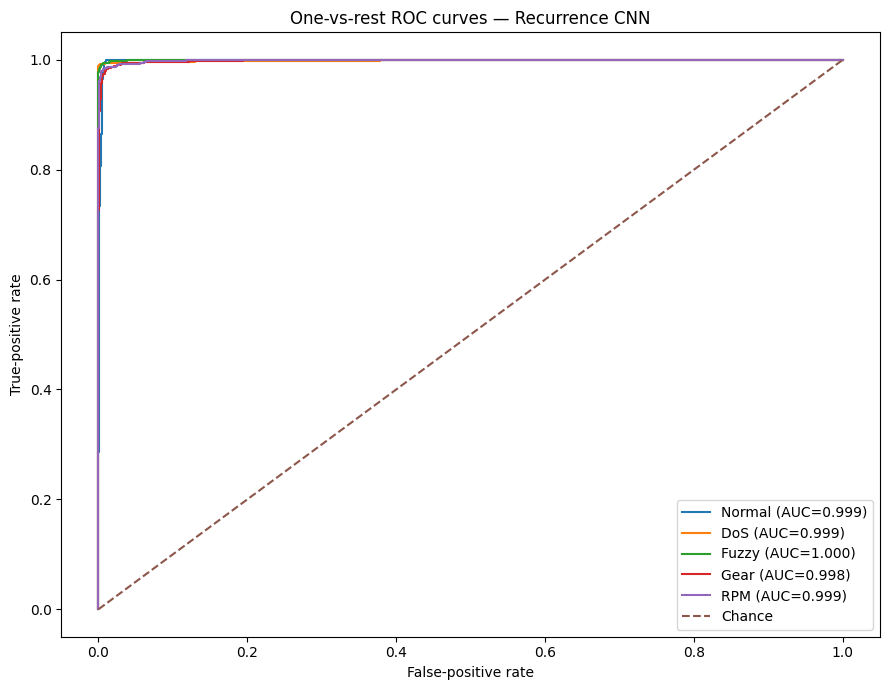

Saved: /kaggle/working/autospectra_outputs/plots/metrics_roc_recurrence_cnn.png


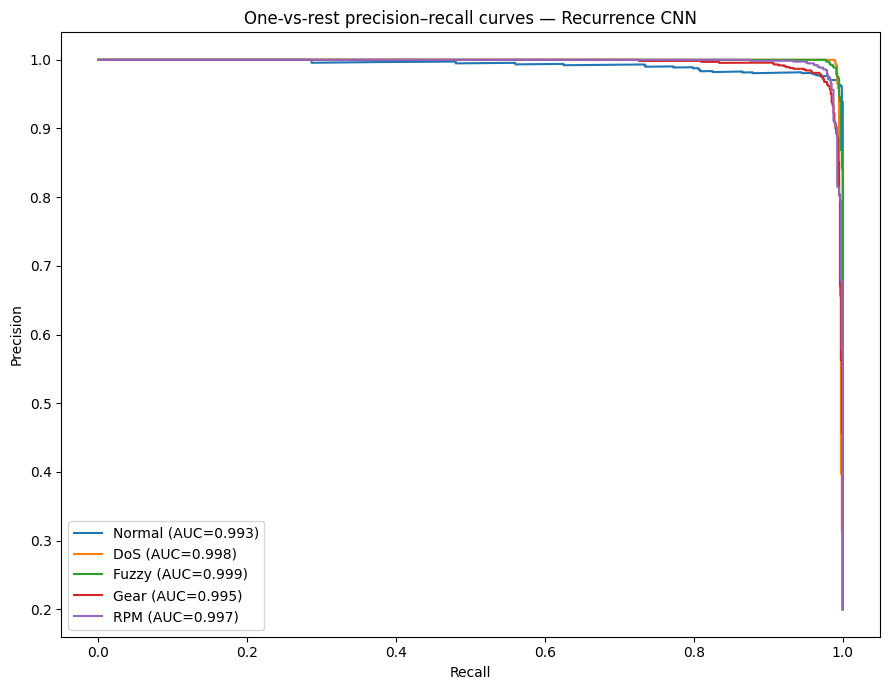

Saved: /kaggle/working/autospectra_outputs/plots/metrics_pr_recurrence_cnn.png


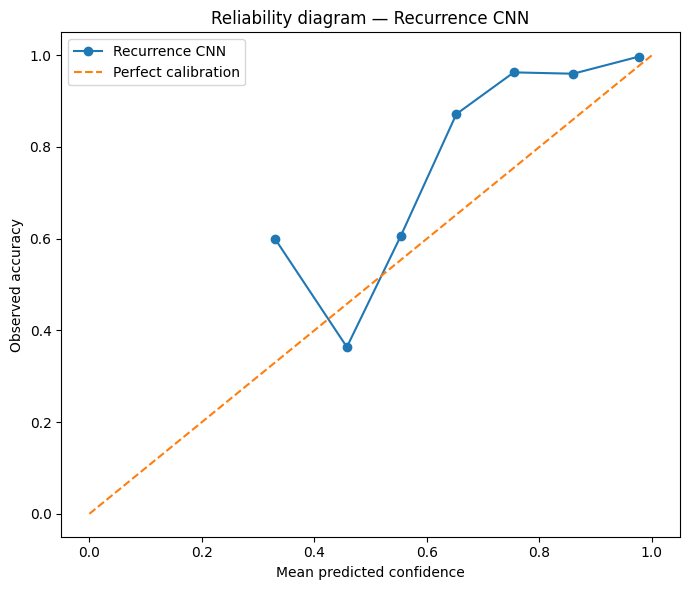

Saved: /kaggle/working/autospectra_outputs/plots/metrics_calibration_recurrence_cnn.png


In [120]:

# 11. Train and evaluate the recurrence CNN


deep_validation_probabilities = {}
deep_test_probabilities = {}

if RUN_DEEP_LEARNING:
    cnn_train_dataset = CANRecurrenceDataset(
        X_train_seq,
        y_train,
    )

    cnn_validation_dataset = CANRecurrenceDataset(
        X_validation_seq,
        y_validation,
    )

    cnn_test_dataset = CANRecurrenceDataset(
        X_test_seq,
        y_test,
    )

    cnn_train_loader = create_loader(
        cnn_train_dataset,
        shuffle=True,
    )

    cnn_validation_loader = create_loader(
        cnn_validation_dataset
    )

    cnn_test_loader = create_loader(
        cnn_test_dataset
    )

    cnn = RecurrenceCNN()

    fit_start = time.perf_counter()

    cnn, cnn_history = train_torch_classifier(
        cnn,
        cnn_train_loader,
        cnn_validation_loader,
        "Recurrence CNN",
    )

    cnn_fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    plot_training_history(
        cnn_history,
        "Recurrence CNN",
    )

    cnn_path = (
        MODEL_DIR
        / "recurrence_cnn.pt"
    )

    torch.save({
        "state_dict": cnn.state_dict(),
        "class_names": CLASS_NAMES,
        "window_size": WINDOW_SIZE,
        "sequence_features": [
            "can_id_norm",
            "dlc_norm",
            "data_0",
            "data_1",
            "data_2",
            "data_3",
            "data_4",
            "data_5",
            "data_6",
            "data_7",
            "iat_log_norm",
        ],
    }, cnn_path)

    (
        cnn_validation_probabilities,
        cnn_validation_labels,
    ) = probabilities_from_torch_model(
        cnn,
        cnn_validation_loader,
    )

    assert np.array_equal(
        cnn_validation_labels,
        y_validation,
    )

    inference_start = time.perf_counter()

    (
        cnn_test_probabilities,
        cnn_test_labels,
    ) = probabilities_from_torch_model(
        cnn,
        cnn_test_loader,
    )

    cnn_inference_seconds = (
        time.perf_counter()
        - inference_start
    )

    assert np.array_equal(
        cnn_test_labels,
        y_test,
    )

    deep_validation_probabilities[
        "Recurrence CNN"
    ] = cnn_validation_probabilities

    deep_test_probabilities[
        "Recurrence CNN"
    ] = cnn_test_probabilities

    row, _ = evaluate_and_store(
        "Recurrence CNN",
        y_test,
        cnn_test_probabilities,
        cnn_inference_seconds,
        cnn_path,
        make_all_plots=True,
    )

    row[
        "Training_Seconds"
    ] = cnn_fit_seconds
else:
    print(
        "Deep learning disabled "
        "by configuration."
    )

LSTM Classifier | epoch 01 | loss 0.6861 | validation macro-F1 0.9950
LSTM Classifier | epoch 02 | loss 0.1391 | validation macro-F1 0.9958
LSTM Classifier | epoch 03 | loss 0.1301 | validation macro-F1 0.9960
LSTM Classifier | epoch 04 | loss 0.1263 | validation macro-F1 0.9965
LSTM Classifier | epoch 05 | loss 0.1250 | validation macro-F1 0.9950
LSTM Classifier | epoch 06 | loss 0.1304 | validation macro-F1 0.9968
LSTM Classifier | epoch 07 | loss 0.1288 | validation macro-F1 0.9965
LSTM Classifier | epoch 08 | loss 0.1265 | validation macro-F1 0.9958


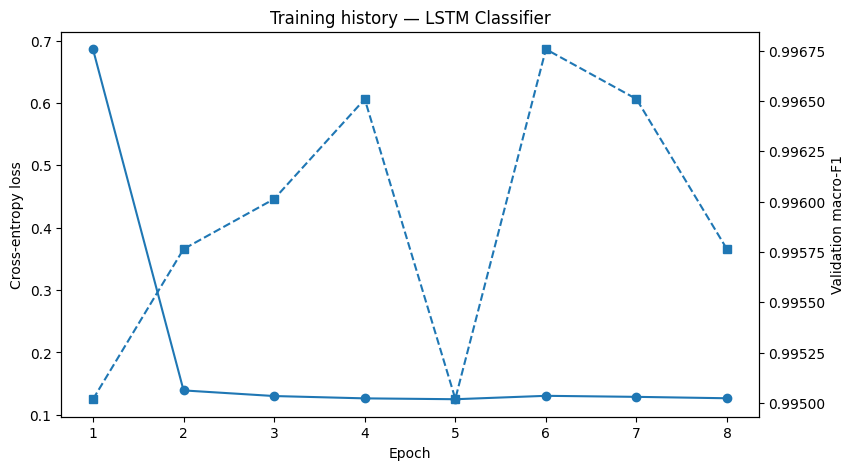

Saved: /kaggle/working/autospectra_outputs/plots/training_lstm_classifier.png

LSTM Classifier
---------------


,Value
Model,LSTM Classifier
Accuracy,0.99475
Balanced_Accuracy,0.99475
Macro_Precision,0.994871
Macro_Recall,0.99475
Macro_F1,0.994771
Weighted_F1,0.994771
MCC,0.993458
Log_Loss,0.036426
Macro_ROC_AUC_OVR,0.999701


,precision,recall,f1-score,support
Normal,0.975610,1.00000,0.987654,800.00000
DoS,1.000000,0.99125,0.995606,800.00000
Fuzzy,1.000000,0.99125,0.995606,800.00000
Gear,0.998745,0.99500,0.996869,800.00000
RPM,1.000000,0.99625,0.998121,800.00000
accuracy,0.994750,0.99475,0.994750,0.99475
macro avg,0.994871,0.99475,0.994771,4000.00000
weighted avg,0.994871,0.99475,0.994771,4000.00000


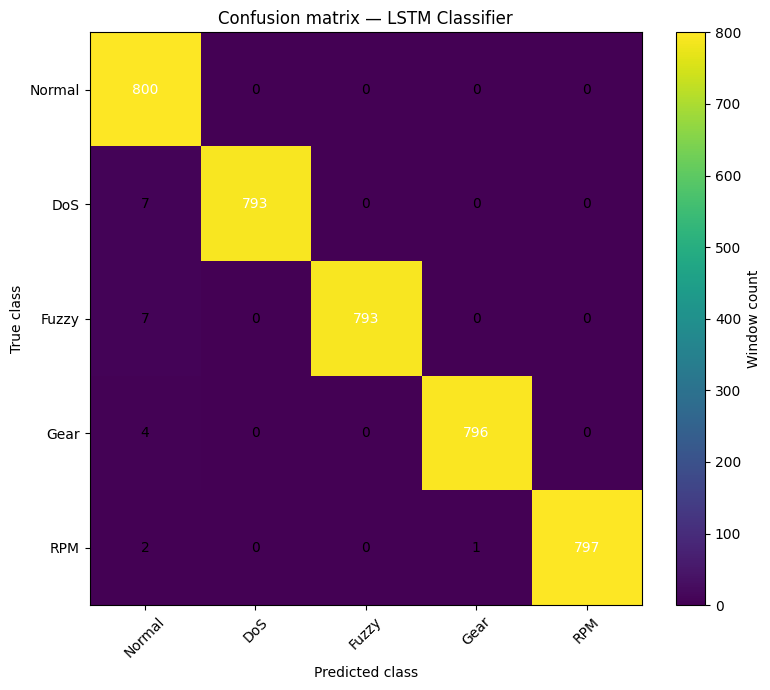

Saved: /kaggle/working/autospectra_outputs/plots/metrics_confusion_lstm_classifier.png


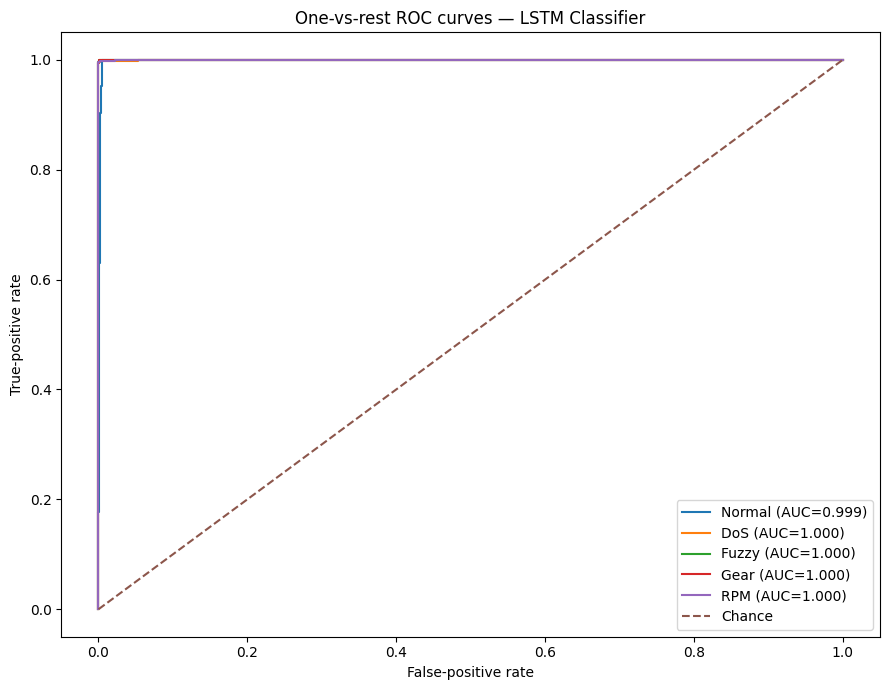

Saved: /kaggle/working/autospectra_outputs/plots/metrics_roc_lstm_classifier.png


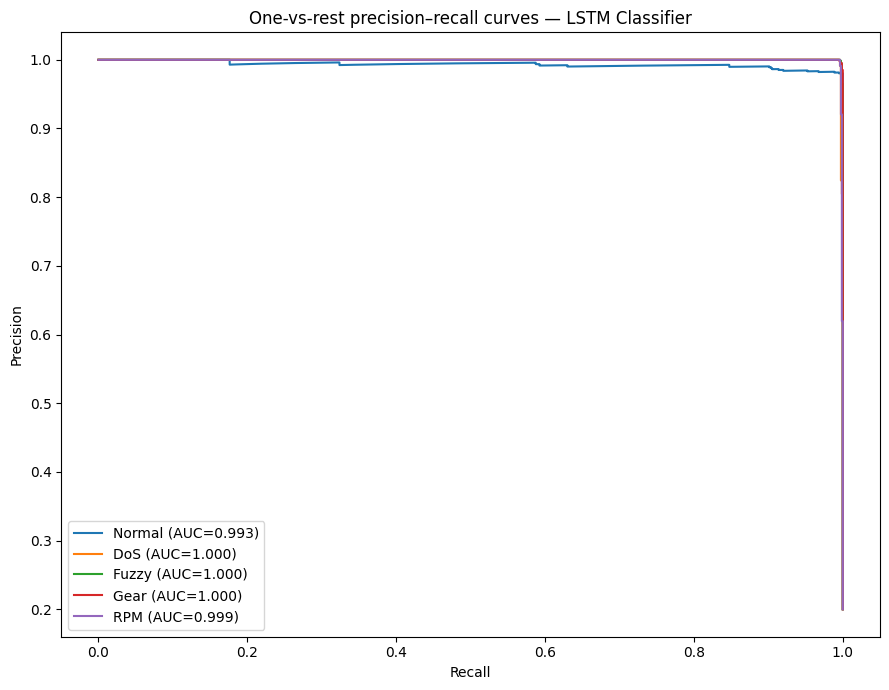

Saved: /kaggle/working/autospectra_outputs/plots/metrics_pr_lstm_classifier.png


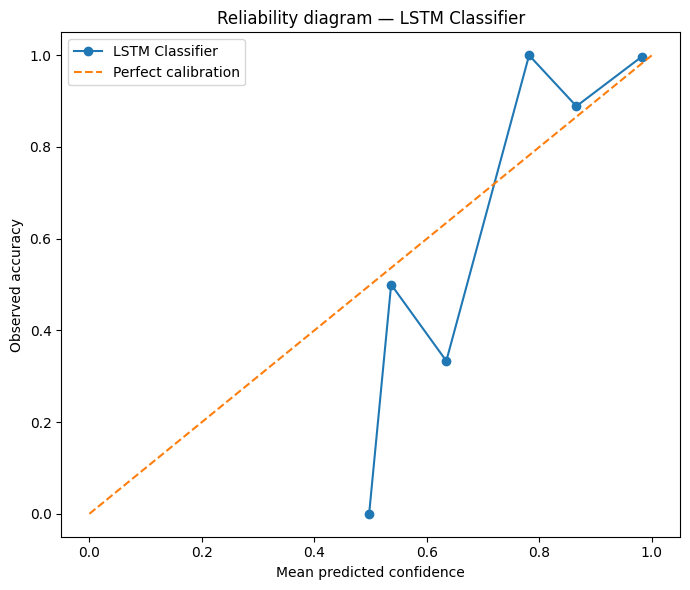

Saved: /kaggle/working/autospectra_outputs/plots/metrics_calibration_lstm_classifier.png


In [121]:

# 12. Train and evaluate the LSTM classifier


if RUN_DEEP_LEARNING:
    lstm_train_dataset = CANSequenceDataset(
        X_train_seq,
        y_train,
    )

    lstm_validation_dataset = CANSequenceDataset(
        X_validation_seq,
        y_validation,
    )

    lstm_test_dataset = CANSequenceDataset(
        X_test_seq,
        y_test,
    )

    lstm_train_loader = create_loader(
        lstm_train_dataset,
        shuffle=True,
    )

    lstm_validation_loader = create_loader(
        lstm_validation_dataset
    )

    lstm_test_loader = create_loader(
        lstm_test_dataset
    )

    lstm_classifier = (
        CANLSTMClassifier()
    )

    fit_start = time.perf_counter()

    (
        lstm_classifier,
        lstm_history,
    ) = train_torch_classifier(
        lstm_classifier,
        lstm_train_loader,
        lstm_validation_loader,
        "LSTM Classifier",
    )

    lstm_fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    plot_training_history(
        lstm_history,
        "LSTM Classifier",
    )

    lstm_path = (
        MODEL_DIR
        / "lstm_classifier.pt"
    )

    torch.save({
        "state_dict":
            lstm_classifier.state_dict(),
        "class_names": CLASS_NAMES,
        "window_size": WINDOW_SIZE,
        "input_size": 11,
    }, lstm_path)

    (
        lstm_validation_probabilities,
        lstm_validation_labels,
    ) = probabilities_from_torch_model(
        lstm_classifier,
        lstm_validation_loader,
    )

    assert np.array_equal(
        lstm_validation_labels,
        y_validation,
    )

    inference_start = time.perf_counter()

    (
        lstm_test_probabilities,
        lstm_test_labels,
    ) = probabilities_from_torch_model(
        lstm_classifier,
        lstm_test_loader,
    )

    lstm_inference_seconds = (
        time.perf_counter()
        - inference_start
    )

    assert np.array_equal(
        lstm_test_labels,
        y_test,
    )

    deep_validation_probabilities[
        "LSTM Classifier"
    ] = lstm_validation_probabilities

    deep_test_probabilities[
        "LSTM Classifier"
    ] = lstm_test_probabilities

    row, _ = evaluate_and_store(
        "LSTM Classifier",
        y_test,
        lstm_test_probabilities,
        lstm_inference_seconds,
        lstm_path,
        make_all_plots=True,
    )

    row[
        "Training_Seconds"
    ] = lstm_fit_seconds

# Part D — Unsupervised LSTM autoencoder

The autoencoder is trained **only on normal training windows**. It learns to reconstruct ordinary CAN sequences. A high reconstruction error is treated as anomalous.

This model answers a different research question from the five-class classifiers:

> Can an unsupervised model detect traffic that differs from the learned normal pattern?

It is evaluated as a binary detector (`Normal` versus `Attack`). It is not expected to identify the specific attack class without an additional classifier.

Two thresholds are calculated on validation data:

1. `Normal_99th_percentile`: controls validation false alarms by using the 99th percentile of normal reconstruction error.
2. `Maximum_validation_F1`: chooses the threshold that maximises binary validation F1.

The first is used by default because false alarms are operationally important in a vehicle.

In [122]:

# 13. LSTM autoencoder definition and training


class LSTMSequenceAutoencoder(nn.Module):
    def __init__(
        self,
        input_size=11,
        hidden_size=48,
    ):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.output_layer = nn.Linear(
            hidden_size,
            input_size,
        )

    def forward(self, inputs):
        _, (hidden, _) = self.encoder(inputs)

        context = hidden[-1]

        repeated_context = (
            context
            .unsqueeze(1)
            .repeat(1, inputs.size(1), 1)
        )

        decoded, _ = self.decoder(
            repeated_context
        )

        return self.output_layer(decoded)


class SequenceOnlyDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return torch.from_numpy(
            self.sequences[
                index
            ].astype(np.float32)
        )


def train_autoencoder(
    model,
    train_loader,
    epochs=AUTOENCODER_EPOCHS,
):
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-5,
    )

    criterion = nn.MSELoss()

    history = []
    best_loss = np.inf
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        model.train()

        total_loss = 0.0
        seen = 0

        for sequences in train_loader:
            sequences = sequences.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            reconstruction = model(sequences)

            loss = criterion(
                reconstruction,
                sequences,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=2.0,
            )

            optimizer.step()

            total_loss += (
                loss.item()
                * len(sequences)
            )

            seen += len(sequences)

        epoch_loss = (
            total_loss
            / max(seen, 1)
        )

        history.append({
            "epoch": epoch,
            "reconstruction_loss":
                epoch_loss,
        })

        print(
            "Autoencoder | "
            f"epoch {epoch:02d} | "
            "reconstruction loss "
            f"{epoch_loss:.6f}"
        )

        if epoch_loss < best_loss - 1e-6:
            best_loss = epoch_loss

            best_state = {
                key:
                    value
                    .detach()
                    .cpu()
                    .clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "Autoencoder early stopping."
            )
            break

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    return model, pd.DataFrame(history)


def autoencoder_scores(
    model,
    sequences,
    batch_size=BATCH_SIZE,
):
    loader = DataLoader(
        SequenceOnlyDataset(sequences),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    scores = []
    model.eval()

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(
                DEVICE,
                non_blocking=True,
            )

            reconstruction = model(batch)

            batch_scores = (
                (reconstruction - batch) ** 2
            ).mean(dim=(1, 2))

            scores.append(
                batch_scores.cpu().numpy()
            )

    return np.concatenate(scores)


def best_f1_threshold(
    y_binary,
    scores,
):
    precision, recall, thresholds = (
        precision_recall_curve(
            y_binary,
            scores,
        )
    )

    f1_values = (
        2
        * precision
        * recall
        / np.maximum(
            precision + recall,
            1e-12,
        )
    )

    if len(thresholds) == 0:
        return float(
            np.median(scores)
        )

    best_index = int(
        np.nanargmax(
            f1_values[:-1]
        )
    )

    return float(
        thresholds[best_index]
    )

Autoencoder | epoch 01 | reconstruction loss 0.191825
Autoencoder | epoch 02 | reconstruction loss 0.092144
Autoencoder | epoch 03 | reconstruction loss 0.069548
Autoencoder | epoch 04 | reconstruction loss 0.067296
Autoencoder | epoch 05 | reconstruction loss 0.066799
Autoencoder | epoch 06 | reconstruction loss 0.066490
Autoencoder | epoch 07 | reconstruction loss 0.066293
Autoencoder | epoch 08 | reconstruction loss 0.066123


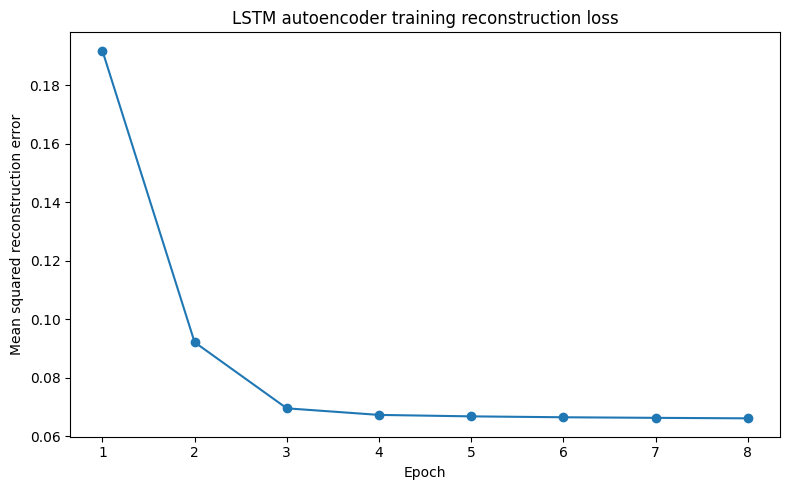

Saved: /kaggle/working/autospectra_outputs/plots/training_lstm_autoencoder.png


,Direction,Threshold,Validation_Precision,Validation_Recall,Validation_F1,Validation_Accuracy,Validation_FPR
234,higher_is_attack,0.068936,0.962335,0.63875,0.767844,0.691,0.1


,Value
Model,LSTM Autoencoder (binary)
Threshold_Method,Validation_F1_with_FPR_constraint
Score_Direction,higher_is_attack
Threshold,0.068936
Accuracy,0.6895
Precision,0.955773
Recall,0.641563
F1,0.767764
ROC_AUC,0.713541
PR_AUC,0.932182


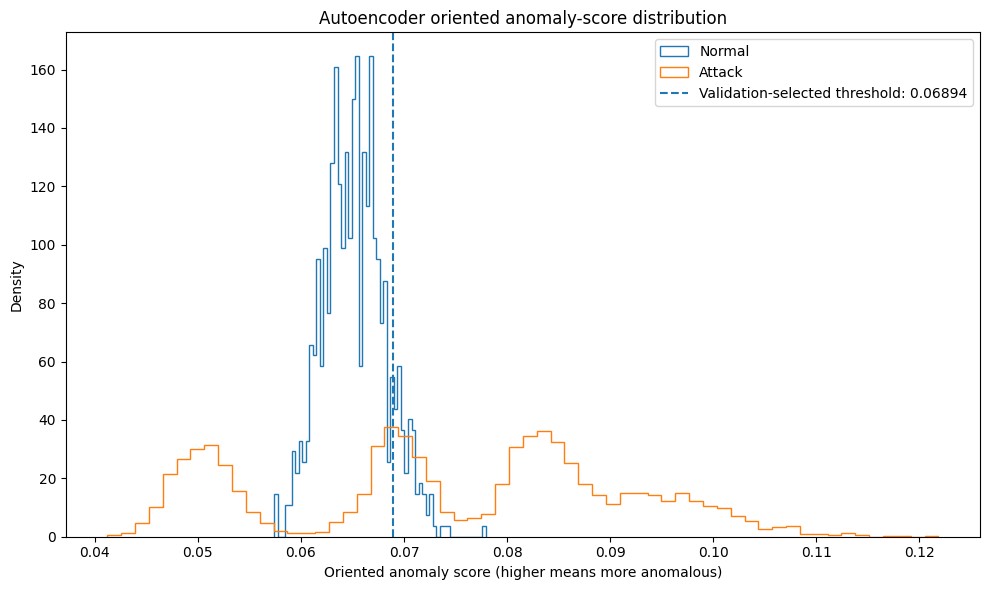

Saved: /kaggle/working/autospectra_outputs/plots/autoencoder_score_distribution.png


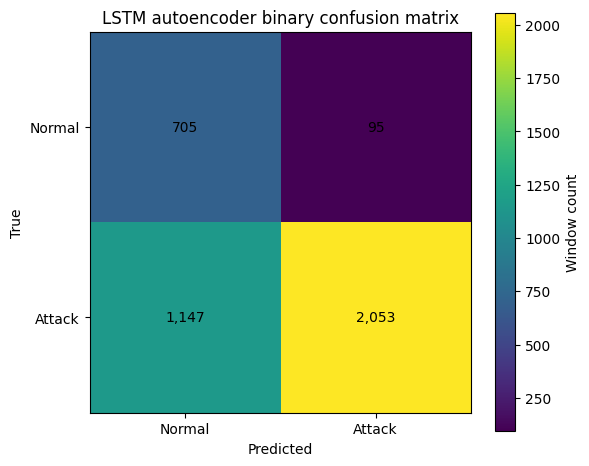

Saved: /kaggle/working/autospectra_outputs/plots/autoencoder_confusion_matrix.png


In [123]:

# 13B. Train and evaluate the normal-only LSTM autoencoder


autoencoder_results = None


def apply_anomaly_rule(
    scores,
    threshold,
    direction,
):
    """Convert reconstruction scores to 0=normal / 1=attack."""
    if direction == "higher_is_attack":
        return (
            np.asarray(scores)
            >= threshold
        ).astype(int)

    if direction == "lower_is_attack":
        return (
            np.asarray(scores)
            <= threshold
        ).astype(int)

    raise ValueError(
        f"Unknown anomaly direction: {direction}"
    )


def select_validation_anomaly_rule(
    y_binary,
    scores,
    maximum_fpr=0.10,
):
    """
    Select threshold and score direction using validation data only.

    A normal-only autoencoder normally gives attacks higher errors, but some
    feature distributions can reverse that relationship. Both orientations
    are evaluated transparently. The test set is never used for selection.
    """
    y_binary = np.asarray(
        y_binary,
        dtype=int,
    )
    scores = np.asarray(
        scores,
        dtype=float,
    )

    if set(np.unique(y_binary)) != {0, 1}:
        raise ValueError(
            "Validation data must contain both normal and attack windows."
        )

    quantile_grid = np.linspace(
        0.001,
        0.999,
        500,
    )
    candidates = np.unique(
        np.quantile(
            scores,
            quantile_grid,
        )
    )

    rows = []

    for direction in [
        "higher_is_attack",
        "lower_is_attack",
    ]:
        for threshold in candidates:
            predictions = apply_anomaly_rule(
                scores,
                float(threshold),
                direction,
            )

            tn, fp, fn, tp = confusion_matrix(
                y_binary,
                predictions,
                labels=[0, 1],
            ).ravel()

            fpr = fp / max(
                fp + tn,
                1,
            )

            rows.append({
                "direction": direction,
                "threshold": float(threshold),
                "precision": precision_score(
                    y_binary,
                    predictions,
                    zero_division=0,
                ),
                "recall": recall_score(
                    y_binary,
                    predictions,
                    zero_division=0,
                ),
                "f1": f1_score(
                    y_binary,
                    predictions,
                    zero_division=0,
                ),
                "accuracy": accuracy_score(
                    y_binary,
                    predictions,
                ),
                "fpr": fpr,
            })

    search_df = pd.DataFrame(rows)

    constrained = search_df[
        search_df["fpr"]
        <= maximum_fpr
    ]

    selection_pool = (
        constrained
        if not constrained.empty
        else search_df
    )

    selected = (
        selection_pool
        .sort_values(
            [
                "f1",
                "recall",
                "precision",
                "accuracy",
                "fpr",
            ],
            ascending=[
                False,
                False,
                False,
                False,
                True,
            ],
        )
        .iloc[0]
    )

    return selected, search_df


if RUN_AUTOENCODER:
    normal_training_sequences = X_train_seq[
        y_train
        == CLASS_TO_INDEX["Normal"]
    ]

    if len(normal_training_sequences) == 0:
        raise RuntimeError(
            "No normal training windows were found."
        )

    autoencoder_train_loader = DataLoader(
        SequenceOnlyDataset(
            normal_training_sequences
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    autoencoder = LSTMSequenceAutoencoder()

    fit_start = time.perf_counter()

    (
        autoencoder,
        autoencoder_history,
    ) = train_autoencoder(
        autoencoder,
        autoencoder_train_loader,
    )

    autoencoder_fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    plt.figure(figsize=(8, 5))
    plt.plot(
        autoencoder_history["epoch"],
        autoencoder_history[
            "reconstruction_loss"
        ],
        marker="o",
    )
    plt.title(
        "LSTM autoencoder training "
        "reconstruction loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel(
        "Mean squared reconstruction error"
    )
    save_current_figure(
        "training_lstm_autoencoder.png"
    )

    autoencoder_path = (
        MODEL_DIR
        / "lstm_autoencoder.pt"
    )

    torch.save({
        "state_dict":
            autoencoder.state_dict(),
        "window_size": WINDOW_SIZE,
        "input_size": 11,
    }, autoencoder_path)

    validation_scores = autoencoder_scores(
        autoencoder,
        X_validation_seq,
    )

    test_score_start = time.perf_counter()

    test_scores = autoencoder_scores(
        autoencoder,
        X_test_seq,
    )

    autoencoder_inference_seconds = (
        time.perf_counter()
        - test_score_start
    )

    y_validation_binary = (
        y_validation
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    y_test_binary = (
        y_test
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    if set(
        np.unique(
            y_validation_binary
        )
    ) != {0, 1}:
        raise RuntimeError(
            "The validation split must contain normal and attack windows."
        )

    if set(
        np.unique(
            y_test_binary
        )
    ) != {0, 1}:
        raise RuntimeError(
            "The test split must contain normal and attack windows."
        )

    selected_rule, threshold_search_df = (
        select_validation_anomaly_rule(
            y_validation_binary,
            validation_scores,
            maximum_fpr=0.10,
        )
    )

    selected_threshold = float(
        selected_rule["threshold"]
    )
    selected_direction = str(
        selected_rule["direction"]
    )

    display(
        pd.DataFrame(
            [selected_rule]
        ).rename(
            columns={
                "direction":
                    "Direction",
                "threshold":
                    "Threshold",
                "precision":
                    "Validation_Precision",
                "recall":
                    "Validation_Recall",
                "f1":
                    "Validation_F1",
                "accuracy":
                    "Validation_Accuracy",
                "fpr":
                    "Validation_FPR",
            }
        )
    )

    threshold_config_path = (
        MODEL_DIR
        / "autoencoder_threshold.json"
    )

    with threshold_config_path.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump({
            "threshold":
                selected_threshold,
            "direction":
                selected_direction,
            "selected_on":
                "validation set",
            "maximum_validation_fpr":
                0.10,
        }, handle, indent=2)

    autoencoder_test_prediction = (
        apply_anomaly_rule(
            test_scores,
            selected_threshold,
            selected_direction,
        )
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test_binary,
        autoencoder_test_prediction,
        labels=[0, 1],
    ).ravel()

    oriented_validation_scores = (
        validation_scores
        if selected_direction
        == "higher_is_attack"
        else -validation_scores
    )

    oriented_test_scores = (
        test_scores
        if selected_direction
        == "higher_is_attack"
        else -test_scores
    )

    autoencoder_results = {
        "Model":
            "LSTM Autoencoder (binary)",
        "Threshold_Method":
            "Validation_F1_with_FPR_constraint",
        "Score_Direction":
            selected_direction,
        "Threshold":
            selected_threshold,
        "Accuracy":
            accuracy_score(
                y_test_binary,
                autoencoder_test_prediction,
            ),
        "Precision":
            precision_score(
                y_test_binary,
                autoencoder_test_prediction,
                zero_division=0,
            ),
        "Recall":
            recall_score(
                y_test_binary,
                autoencoder_test_prediction,
                zero_division=0,
            ),
        "F1":
            f1_score(
                y_test_binary,
                autoencoder_test_prediction,
                zero_division=0,
            ),
        "ROC_AUC":
            roc_auc_score(
                y_test_binary,
                oriented_test_scores,
            ),
        "PR_AUC":
            average_precision_score(
                y_test_binary,
                oriented_test_scores,
            ),
        "FPR":
            fp / max(fp + tn, 1),
        "FNR":
            fn / max(fn + tp, 1),
        "Inference_ms_per_window":
            autoencoder_inference_seconds
            * 1000
            / len(y_test_binary),
        "Model_Size_MB":
            model_file_size_mb(
                autoencoder_path
            ),
        "Training_Seconds":
            autoencoder_fit_seconds,
    }

    display(
        pd.DataFrame(
            [autoencoder_results]
        )
        .T
        .rename(
            columns={0: "Value"}
        )
    )

    # Save the complete validation threshold search for auditability.
    threshold_search_df.to_csv(
        REPORT_DIR
        / "autoencoder_threshold_search.csv",
        index=False,
    )

    plt.figure(figsize=(10, 6))

    plt.hist(
        oriented_test_scores[
            y_test_binary == 0
        ],
        bins=60,
        density=True,
        histtype="step",
        label="Normal",
    )

    plt.hist(
        oriented_test_scores[
            y_test_binary == 1
        ],
        bins=60,
        density=True,
        histtype="step",
        label="Attack",
    )

    oriented_threshold = (
        selected_threshold
        if selected_direction
        == "higher_is_attack"
        else -selected_threshold
    )

    plt.axvline(
        oriented_threshold,
        linestyle="--",
        label=(
            "Validation-selected threshold: "
            f"{oriented_threshold:.5f}"
        ),
    )

    plt.title(
        "Autoencoder oriented anomaly-score "
        "distribution"
    )
    plt.xlabel(
        "Oriented anomaly score "
        "(higher means more anomalous)"
    )
    plt.ylabel("Density")
    plt.legend()

    save_current_figure(
        "autoencoder_score_distribution.png"
    )

    matrix = confusion_matrix(
        y_test_binary,
        autoencoder_test_prediction,
        labels=[0, 1],
    )

    plt.figure(figsize=(6, 5))
    image = plt.imshow(matrix)
    plt.colorbar(
        image,
        label="Window count",
    )
    plt.xticks(
        [0, 1],
        ["Normal", "Attack"],
    )
    plt.yticks(
        [0, 1],
        ["Normal", "Attack"],
    )

    for row_index in range(2):
        for column_index in range(2):
            plt.text(
                column_index,
                row_index,
                f"{matrix[row_index, column_index]:,}",
                ha="center",
                va="center",
            )

    plt.title(
        "LSTM autoencoder "
        "binary confusion matrix"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")

    save_current_figure(
        "autoencoder_confusion_matrix.png"
    )


# Part E — Model fusion and confidence calibration

The proposal describes fusing feature-based, image-based, and sequence-based evidence. The notebook therefore combines:

- Random Forest probabilities.
- Recurrence CNN probabilities.
- LSTM classifier probabilities.

Each model receives a weight proportional to its validation macro-F1. This makes the weighting data-driven without consulting the test set.

A simple temperature-scaling grid is then fitted on validation probabilities to reduce overconfidence. The calibrated fusion is reported separately.

,Model,Validation_Macro_F1,Fusion_Weight
0,Random Forest,0.998751,0.335597
1,Recurrence CNN,0.980534,0.329476
2,LSTM Classifier,0.996757,0.334927



RF + CNN + LSTM Fusion
----------------------


,Value
Model,RF + CNN + LSTM Fusion
Accuracy,0.99525
Balanced_Accuracy,0.99525
Macro_Precision,0.99536
Macro_Recall,0.99525
Macro_F1,0.99527
Weighted_F1,0.99527
MCC,0.994081
Log_Loss,0.03798
Macro_ROC_AUC_OVR,0.999858


,precision,recall,f1-score,support
Normal,0.976801,1.00000,0.988264,800.00000
DoS,1.000000,0.99250,0.996236,800.00000
Fuzzy,1.000000,0.99125,0.995606,800.00000
Gear,1.000000,0.99500,0.997494,800.00000
RPM,1.000000,0.99750,0.998748,800.00000
accuracy,0.995250,0.99525,0.995250,0.99525
macro avg,0.995360,0.99525,0.995270,4000.00000
weighted avg,0.995360,0.99525,0.995270,4000.00000


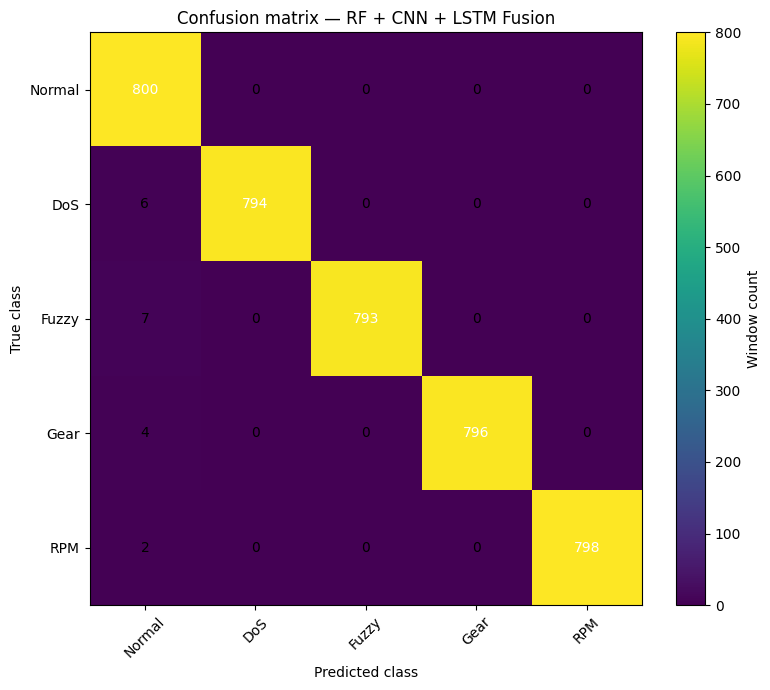

Saved: /kaggle/working/autospectra_outputs/plots/metrics_confusion_rf_plus_cnn_plus_lstm_fusion.png


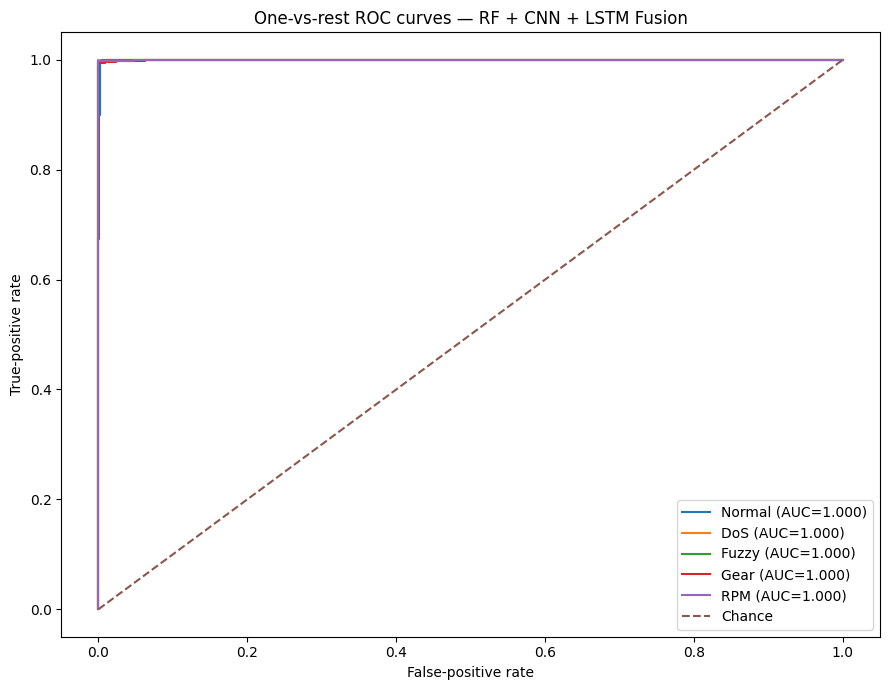

Saved: /kaggle/working/autospectra_outputs/plots/metrics_roc_rf_plus_cnn_plus_lstm_fusion.png


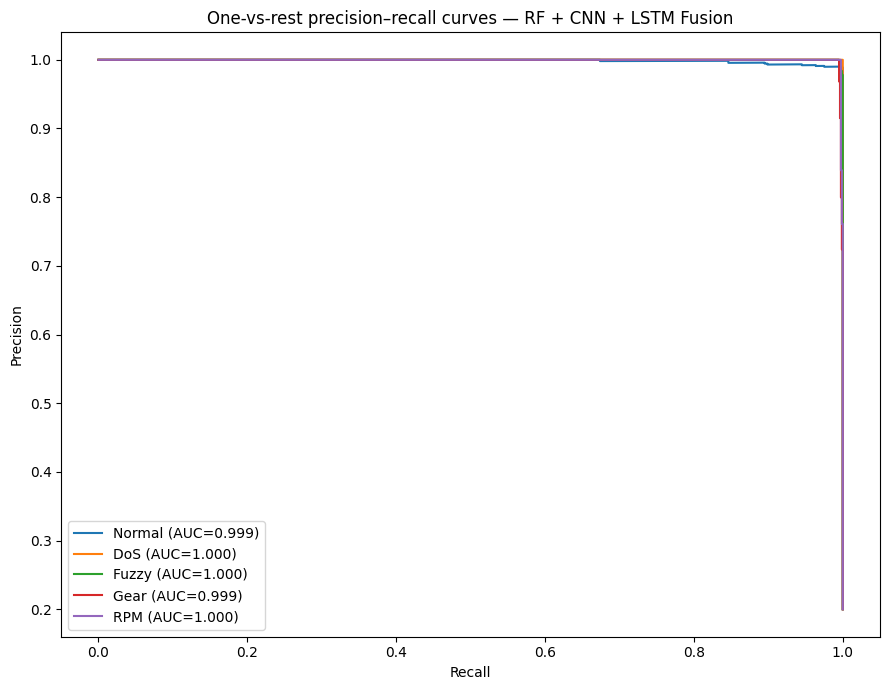

Saved: /kaggle/working/autospectra_outputs/plots/metrics_pr_rf_plus_cnn_plus_lstm_fusion.png


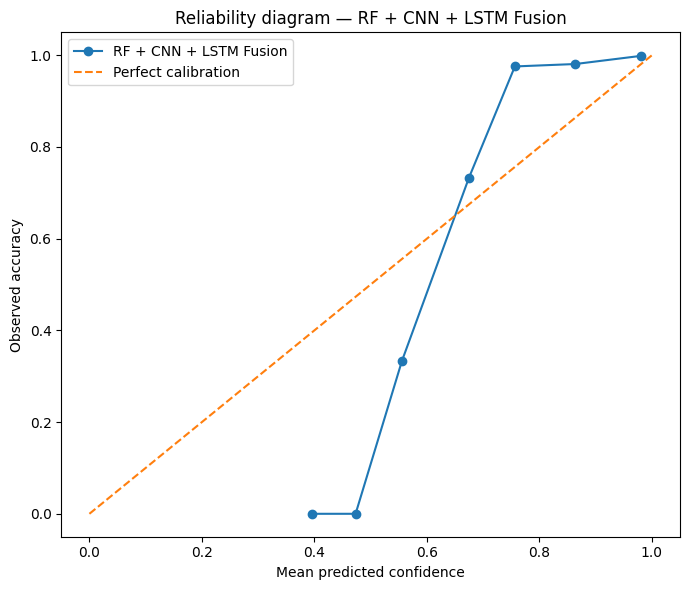

Saved: /kaggle/working/autospectra_outputs/plots/metrics_calibration_rf_plus_cnn_plus_lstm_fusion.png


In [124]:

# 14. Soft-voting fusion


def validation_macro_f1(
    probabilities,
):
    return f1_score(
        y_validation,
        probabilities.argmax(axis=1),
        average="macro",
        zero_division=0,
    )


if RUN_DEEP_LEARNING:
    fusion_validation_sources = {
        "Random Forest":
            classical_validation_probabilities[
                "Random Forest"
            ],
        "Recurrence CNN":
            deep_validation_probabilities[
                "Recurrence CNN"
            ],
        "LSTM Classifier":
            deep_validation_probabilities[
                "LSTM Classifier"
            ],
    }

    fusion_test_sources = {
        "Random Forest":
            classical_test_probabilities[
                "Random Forest"
            ],
        "Recurrence CNN":
            deep_test_probabilities[
                "Recurrence CNN"
            ],
        "LSTM Classifier":
            deep_test_probabilities[
                "LSTM Classifier"
            ],
    }

    raw_weights = {
        name:
            max(
                validation_macro_f1(
                    probability
                ),
                1e-6,
            )
        for name, probability
        in fusion_validation_sources.items()
    }

    total_weight = sum(
        raw_weights.values()
    )

    fusion_weights = {
        name:
            value / total_weight
        for name, value
        in raw_weights.items()
    }

    display(
        pd.DataFrame({
            "Model":
                list(fusion_weights),
            "Validation_Macro_F1": [
                raw_weights[name]
                for name in fusion_weights
            ],
            "Fusion_Weight": [
                fusion_weights[name]
                for name in fusion_weights
            ],
        })
    )

    fusion_validation_probabilities = sum(
        fusion_weights[name]
        * probabilities
        for name, probabilities
        in fusion_validation_sources.items()
    )

    fusion_test_probabilities = sum(
        fusion_weights[name]
        * probabilities
        for name, probabilities
        in fusion_test_sources.items()
    )

    fusion_start = time.perf_counter()

    _ = sum(
        fusion_weights[name]
        * probabilities
        for name, probabilities
        in fusion_test_sources.items()
    )

    fusion_overhead_seconds = (
        time.perf_counter()
        - fusion_start
    )

    inference_by_model = {
        row["Model"]:
            row["Inference_ms_per_window"]
            * len(y_test)
            / 1000.0
        for row in evaluation_rows
    }

    fusion_total_inference_seconds = (
        inference_by_model[
            "Random Forest"
        ]
        + inference_by_model[
            "Recurrence CNN"
        ]
        + inference_by_model[
            "LSTM Classifier"
        ]
        + fusion_overhead_seconds
    )

    fusion_config_path = (
        MODEL_DIR
        / "fusion_weights.json"
    )

    with (
        fusion_config_path.open("w")
    ) as handle:
        json.dump(
            fusion_weights,
            handle,
            indent=2,
        )

    evaluate_and_store(
        "RF + CNN + LSTM Fusion",
        y_test,
        fusion_test_probabilities,
        fusion_total_inference_seconds,
        fusion_config_path,
        make_all_plots=True,
    )

Selected temperature: 0.5

Calibrated RF + CNN + LSTM Fusion
---------------------------------


,Value
Model,Calibrated RF + CNN + LSTM Fusion
Accuracy,0.99525
Balanced_Accuracy,0.99525
Macro_Precision,0.99536
Macro_Recall,0.99525
Macro_F1,0.99527
Weighted_F1,0.99527
MCC,0.994081
Log_Loss,0.019051
Macro_ROC_AUC_OVR,0.999858


,precision,recall,f1-score,support
Normal,0.976801,1.00000,0.988264,800.00000
DoS,1.000000,0.99250,0.996236,800.00000
Fuzzy,1.000000,0.99125,0.995606,800.00000
Gear,1.000000,0.99500,0.997494,800.00000
RPM,1.000000,0.99750,0.998748,800.00000
accuracy,0.995250,0.99525,0.995250,0.99525
macro avg,0.995360,0.99525,0.995270,4000.00000
weighted avg,0.995360,0.99525,0.995270,4000.00000


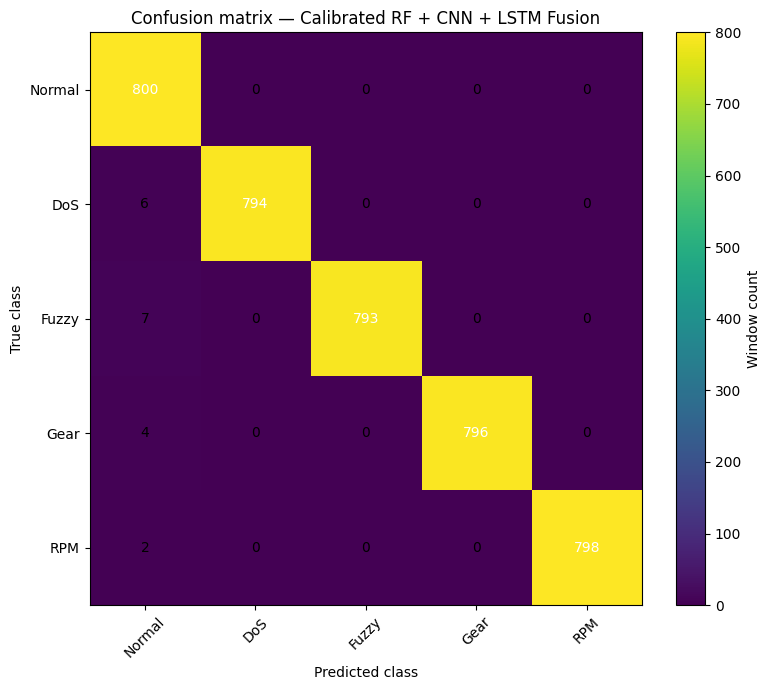

Saved: /kaggle/working/autospectra_outputs/plots/metrics_confusion_calibrated_rf_plus_cnn_plus_lstm_fusion.png


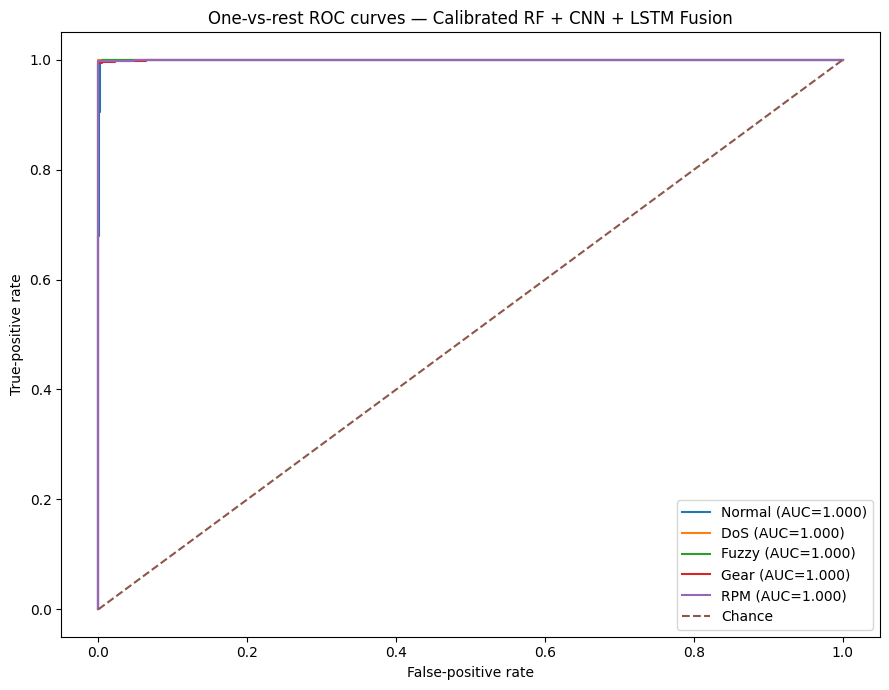

Saved: /kaggle/working/autospectra_outputs/plots/metrics_roc_calibrated_rf_plus_cnn_plus_lstm_fusion.png


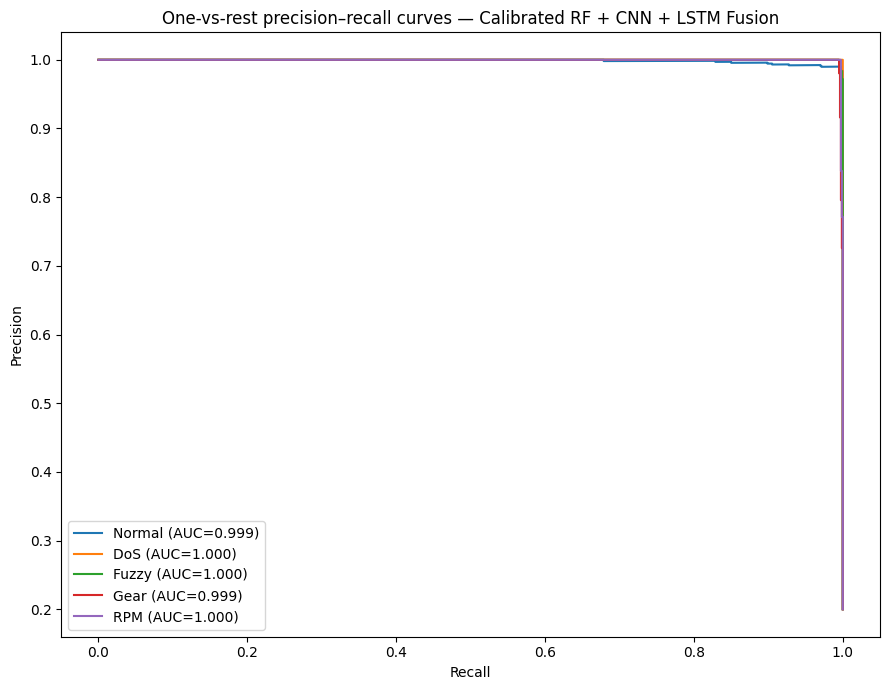

Saved: /kaggle/working/autospectra_outputs/plots/metrics_pr_calibrated_rf_plus_cnn_plus_lstm_fusion.png


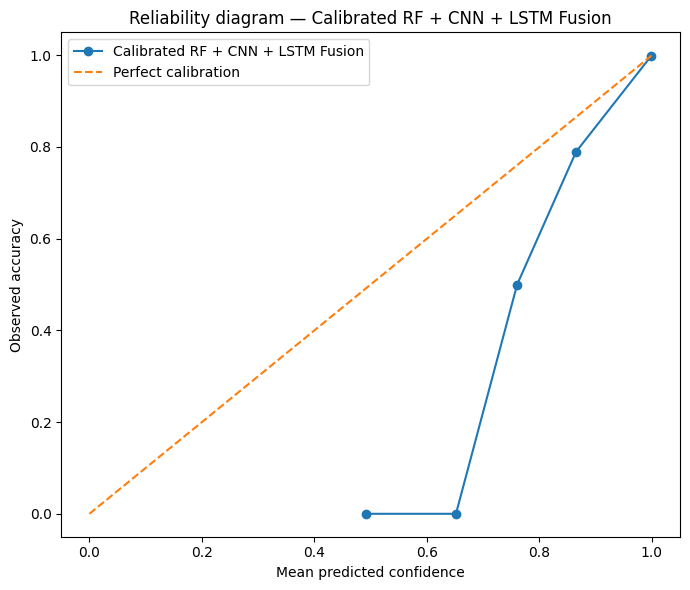

Saved: /kaggle/working/autospectra_outputs/plots/metrics_calibration_calibrated_rf_plus_cnn_plus_lstm_fusion.png


In [125]:

# 15. Temperature calibration fitted on validation data


def apply_temperature(
    probabilities,
    temperature,
):
    clipped = np.clip(
        probabilities,
        1e-12,
        1.0,
    )

    adjusted = (
        clipped
        ** (1.0 / temperature)
    )

    return (
        adjusted
        / adjusted.sum(
            axis=1,
            keepdims=True,
        )
    )


if RUN_DEEP_LEARNING:
    temperature_candidates = np.linspace(
        0.5,
        3.0,
        51,
    )

    validation_losses = []

    for temperature in temperature_candidates:
        calibrated_validation = (
            apply_temperature(
                fusion_validation_probabilities,
                temperature,
            )
        )

        validation_losses.append(
            log_loss(
                y_validation,
                calibrated_validation,
                labels=np.arange(
                    len(CLASS_NAMES)
                ),
            )
        )

    best_temperature = float(
        temperature_candidates[
            int(
                np.argmin(
                    validation_losses
                )
            )
        ]
    )

    calibrated_fusion_test = (
        apply_temperature(
            fusion_test_probabilities,
            best_temperature,
        )
    )

    calibration_path = (
        MODEL_DIR
        / "fusion_calibration.json"
    )

    with (
        calibration_path.open("w")
    ) as handle:
        json.dump({
            "temperature":
                best_temperature,
            "selection_metric":
                "validation log loss",
        }, handle, indent=2)

    print(
        "Selected temperature:",
        best_temperature,
    )

    evaluate_and_store(
        "Calibrated RF + CNN + LSTM Fusion",
        y_test,
        calibrated_fusion_test,
        fusion_total_inference_seconds,
        calibration_path,
        make_all_plots=True,
    )

# Part F — Comparative results and critical evaluation

Unseen test support: {'Normal': 800, 'DoS': 800, 'Fuzzy': 800, 'Gear': 800, 'RPM': 800}


,Model,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,MCC,Macro_ROC_AUC_OVR,Macro_PR_AUC,Attack_FPR,Attack_FNR,ECE_10_bins,Log_Loss,Inference_ms_per_window,Throughput_windows_per_second,Model_Size_MB,Training_Seconds
1,Random Forest,0.99775,0.99775,0.997775,0.99775,0.997754,0.997754,0.997192,0.999475,0.998556,0.00000,0.002812,0.000438,0.033783,0.021374,46785.519040,2.673676,3.436610
3,XGBoost,0.99775,0.99775,0.997775,0.99775,0.997754,0.997754,0.997192,0.999828,0.999278,0.00000,0.002812,0.001758,0.012293,0.006690,149470.865662,1.257285,1.543344
2,Extra Trees,0.99725,0.99725,0.997287,0.99725,0.997256,0.997256,0.996569,0.999651,0.999272,0.00000,0.003438,0.002360,0.021083,0.021399,46731.580415,8.566468,0.767095
0,Logistic Regression,0.99650,0.99650,0.996560,0.99650,0.996511,0.996511,0.995635,0.999544,0.998335,0.00000,0.004375,0.000743,0.018683,0.001416,706108.847735,0.002824,0.356476
7,Calibrated RF + CNN + LSTM Fusion,0.99525,0.99525,0.995360,0.99525,0.995270,0.995270,0.994081,0.999858,0.999472,0.00000,0.005938,0.001828,0.019051,0.228699,4372.560354,0.000066,NaN
6,RF + CNN + LSTM Fusion,0.99525,0.99525,0.995360,0.99525,0.995270,0.995270,0.994081,0.999858,0.999473,0.00000,0.005938,0.024620,0.037980,0.228699,4372.560354,0.000118,NaN
5,LSTM Classifier,0.99475,0.99475,0.994871,0.99475,0.994771,0.994771,0.993458,0.999701,0.998464,0.00000,0.006250,0.015321,0.036426,0.053775,18596.083299,0.157395,5.740516
4,Recurrence CNN,0.98050,0.98050,0.980952,0.98050,0.980563,0.980563,0.975707,0.998903,0.996465,0.00625,0.008438,0.038077,0.092520,0.153487,6515.198965,0.100137,25.173911


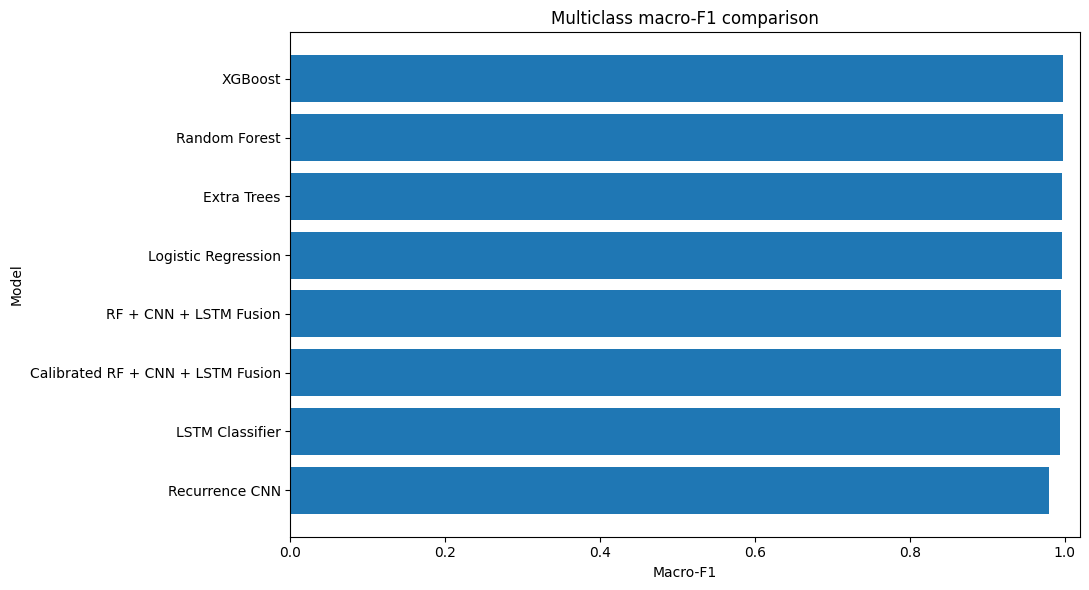

Saved: /kaggle/working/autospectra_outputs/plots/comparison_macro_f1.png


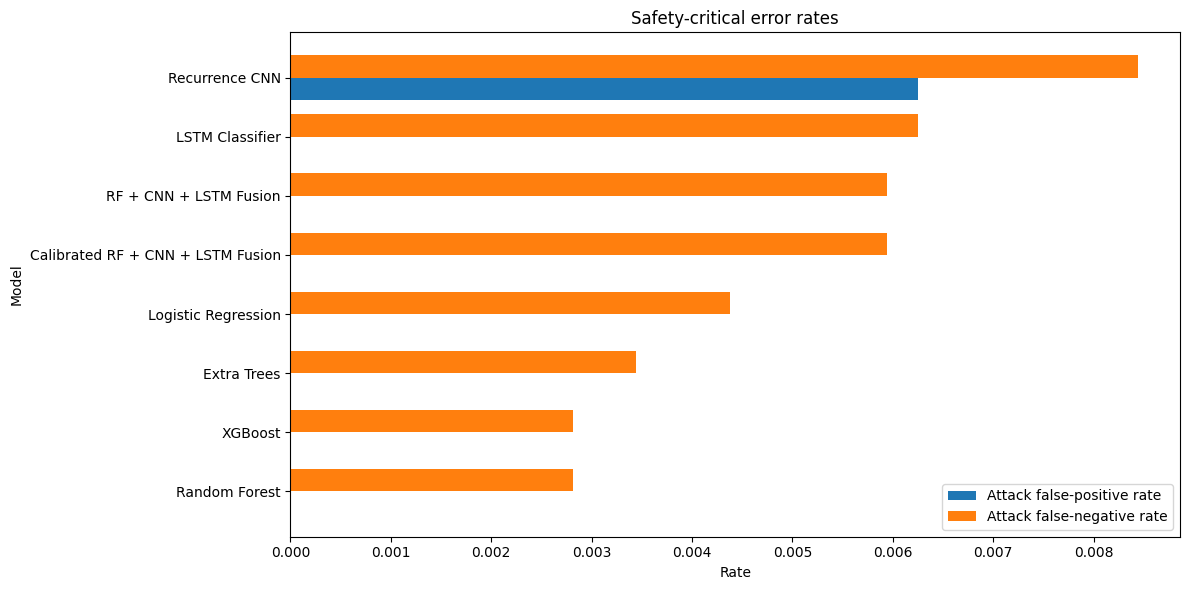

Saved: /kaggle/working/autospectra_outputs/plots/comparison_fpr_fnr.png


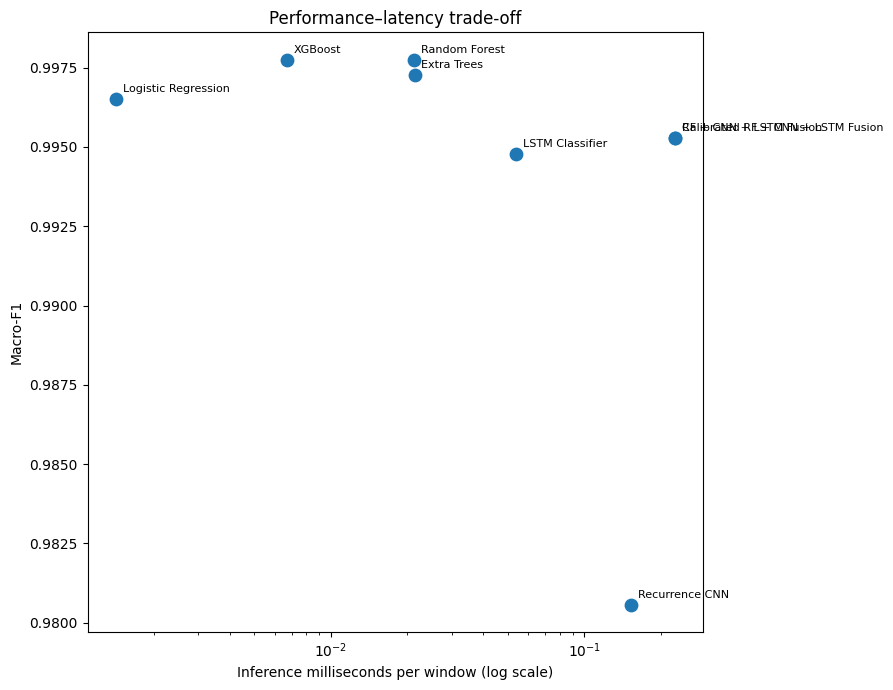

Saved: /kaggle/working/autospectra_outputs/plots/comparison_performance_latency.png


In [126]:

# 16. Final comparison table and charts



# Final safety check: metrics are valid only when all five true classes
# have non-zero support in the unseen test set.
test_support = (
    pd.Series(y_test)
    .value_counts()
    .reindex(
        range(len(CLASS_NAMES)),
        fill_value=0,
    )
)

if (test_support == 0).any():
    missing = [
        CLASS_NAMES[index]
        for index, count
        in test_support.items()
        if count == 0
    ]
    raise RuntimeError(
        "Cannot create the final comparison: unseen test support is "
        "zero for " + ", ".join(missing)
    )

print(
    "Unseen test support:",
    {
        CLASS_NAMES[index]: int(count)
        for index, count
        in test_support.items()
    },
)


evaluation_df = pd.DataFrame(
    evaluation_rows
)

if (
    "Training_Seconds"
    not in evaluation_df.columns
):
    evaluation_df[
        "Training_Seconds"
    ] = np.nan

ordered_columns = [
    "Model",
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1",
    "Weighted_F1",
    "MCC",
    "Macro_ROC_AUC_OVR",
    "Macro_PR_AUC",
    "Attack_FPR",
    "Attack_FNR",
    "ECE_10_bins",
    "Log_Loss",
    "Inference_ms_per_window",
    "Throughput_windows_per_second",
    "Model_Size_MB",
    "Training_Seconds",
]

evaluation_df = (
    evaluation_df[
        [
            column
            for column in ordered_columns
            if column
            in evaluation_df.columns
        ]
    ]
    .sort_values(
        "Macro_F1",
        ascending=False,
    )
)

display(evaluation_df)

evaluation_df.to_csv(
    OUTPUT_DIR
    / "multiclass_model_comparison.csv",
    index=False,
)

plot_frame = evaluation_df.sort_values(
    "Macro_F1"
)

plt.figure(figsize=(11, 6))
plt.barh(
    plot_frame["Model"],
    plot_frame["Macro_F1"],
)
plt.xlim(0, 1.02)
plt.title(
    "Multiclass macro-F1 comparison"
)
plt.xlabel("Macro-F1")
plt.ylabel("Model")

save_current_figure(
    "comparison_macro_f1.png"
)

plot_frame = evaluation_df.sort_values(
    "Attack_FNR"
)

positions = np.arange(
    len(plot_frame)
)

width = 0.38

plt.figure(figsize=(12, 6))

plt.barh(
    positions - width / 2,
    plot_frame["Attack_FPR"],
    height=width,
    label="Attack false-positive rate",
)

plt.barh(
    positions + width / 2,
    plot_frame["Attack_FNR"],
    height=width,
    label="Attack false-negative rate",
)

plt.yticks(
    positions,
    plot_frame["Model"],
)

plt.xlabel("Rate")
plt.ylabel("Model")
plt.title(
    "Safety-critical error rates"
)
plt.legend()

save_current_figure(
    "comparison_fpr_fnr.png"
)

plt.figure(figsize=(9, 7))

plt.scatter(
    evaluation_df[
        "Inference_ms_per_window"
    ],
    evaluation_df["Macro_F1"],
    s=80,
)

for _, row in evaluation_df.iterrows():
    plt.annotate(
        row["Model"],
        (
            row[
                "Inference_ms_per_window"
            ],
            row["Macro_F1"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

plt.xscale("log")
plt.title(
    "Performance–latency trade-off"
)
plt.xlabel(
    "Inference milliseconds per window "
    "(log scale)"
)
plt.ylabel("Macro-F1")

save_current_figure(
    "comparison_performance_latency.png"
)

,Model,Class,Precision,Recall,F1,Support
0,Logistic Regression,Normal,0.982801,1.00000,0.991326,800
1,Logistic Regression,DoS,1.000000,0.99500,0.997494,800
2,Logistic Regression,Fuzzy,1.000000,0.99500,0.997494,800
3,Logistic Regression,Gear,1.000000,0.99500,0.997494,800
4,Logistic Regression,RPM,1.000000,0.99750,0.998748,800
5,Random Forest,Normal,0.988875,1.00000,0.994406,800
6,Random Forest,DoS,1.000000,1.00000,1.000000,800
7,Random Forest,Fuzzy,1.000000,0.99500,0.997494,800
8,Random Forest,Gear,1.000000,0.99625,0.998121,800
9,Random Forest,RPM,1.000000,0.99750,0.998748,800


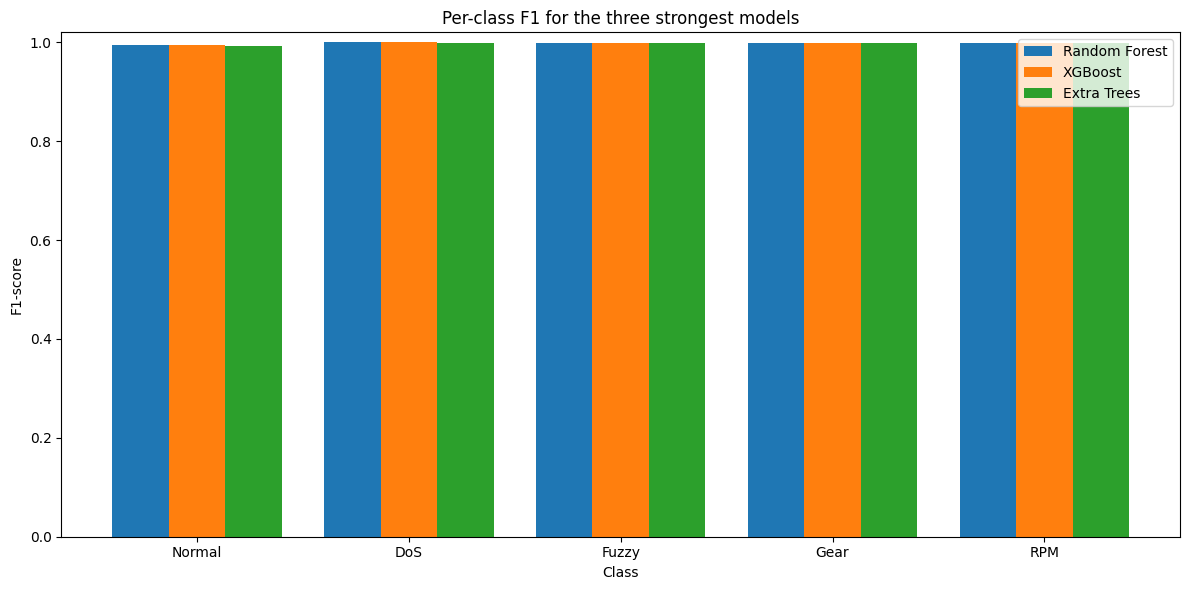

Saved: /kaggle/working/autospectra_outputs/plots/comparison_per_class_f1.png


In [127]:
# Per-class F1 comparison for every multiclass model
per_class_rows = []

for (
    model_name,
    stored,
) in prediction_store.items():
    (
        precision,
        recall,
        f1_values,
        support,
    ) = precision_recall_fscore_support(
        y_test,
        stored["predictions"],
        labels=np.arange(
            len(CLASS_NAMES)
        ),
        zero_division=0,
    )

    for (
        class_index,
        class_name,
    ) in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "Model": model_name,
            "Class": class_name,
            "Precision":
                precision[class_index],
            "Recall":
                recall[class_index],
            "F1":
                f1_values[class_index],
            "Support":
                support[class_index],
        })

per_class_df = pd.DataFrame(
    per_class_rows
)

display(per_class_df)

per_class_df.to_csv(
    OUTPUT_DIR
    / "per_class_metrics.csv",
    index=False,
)

top_models = (
    evaluation_df
    .head(3)["Model"]
    .tolist()
)

plot_data = per_class_df[
    per_class_df[
        "Model"
    ].isin(top_models)
]

x = np.arange(
    len(CLASS_NAMES)
)

bar_width = (
    0.8
    / len(top_models)
)

plt.figure(figsize=(12, 6))

for (
    model_index,
    model_name,
) in enumerate(top_models):
    values = (
        plot_data[
            plot_data["Model"]
            == model_name
        ]
        .set_index("Class")
        .reindex(CLASS_NAMES)["F1"]
        .to_numpy()
    )

    plt.bar(
        x + model_index * bar_width,
        values,
        width=bar_width,
        label=model_name,
    )

plt.xticks(
    x
    + bar_width
    * (len(top_models) - 1)
    / 2,
    CLASS_NAMES,
)

plt.ylim(0, 1.02)

plt.title(
    "Per-class F1 for "
    "the three strongest models"
)
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.legend()

save_current_figure(
    "comparison_per_class_f1.png"
)

,Model,true_class,count,mean,median,p95
0,Random Forest,DoS,800,77.025894,55.607080,205.259621
1,Random Forest,Fuzzy,796,97.424939,53.623080,294.878364
2,Random Forest,Gear,797,33.738251,28.923988,60.580778
3,Random Forest,RPM,798,30.406062,25.748968,52.041578
4,XGBoost,DoS,800,77.025894,55.607080,205.259621
5,XGBoost,Fuzzy,796,97.424939,53.623080,294.878364
6,XGBoost,Gear,797,33.738251,28.923988,60.580778
7,XGBoost,RPM,798,30.406062,25.748968,52.041578
8,Extra Trees,DoS,799,77.121979,55.623055,205.268264
9,Extra Trees,Fuzzy,796,97.424939,53.623080,294.878364


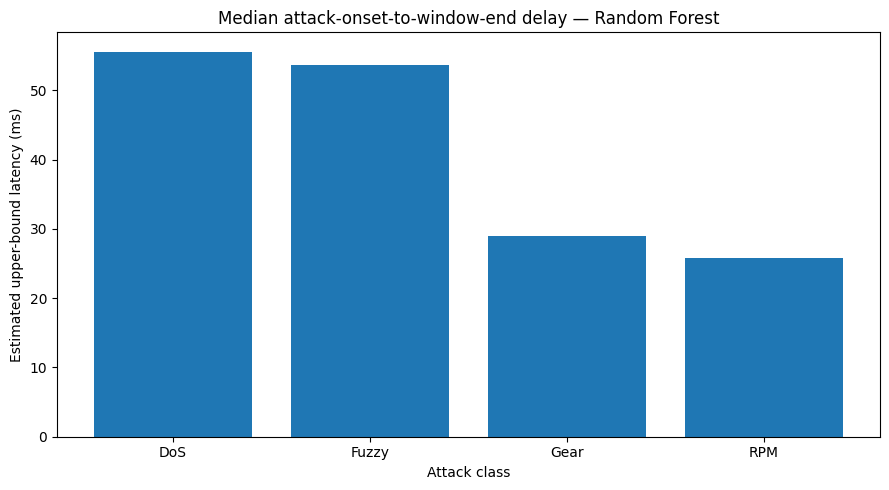

Saved: /kaggle/working/autospectra_outputs/plots/comparison_detection_latency.png


In [128]:

# 17. Estimated detection latency from attack onset to window end


def detection_latency_table(
    model_name,
):
    metadata = (
        DATA["test"]["metadata"]
        .copy()
    )

    predictions = prediction_store[
        model_name
    ]["predictions"]

    metadata["true_label"] = y_test
    metadata["prediction"] = predictions

    attack_mask = (
        metadata["true_label"]
        != CLASS_TO_INDEX["Normal"]
    )

    correctly_detected = (
        attack_mask
        & (
            metadata["prediction"]
            != CLASS_TO_INDEX["Normal"]
        )
    )

    detected = metadata[
        correctly_detected
    ].copy()

    detected["true_class"] = (
        detected["true_label"]
        .map(INDEX_TO_CLASS)
    )

    summary = (
        detected
        .groupby(
            "true_class"
        )[
            "latency_upper_bound_ms"
        ]
        .agg(
            count="count",
            mean="mean",
            median="median",
            p95=lambda values:
                values.quantile(0.95),
        )
        .reindex(CLASS_NAMES[1:])
        .reset_index()
    )

    summary.insert(
        0,
        "Model",
        model_name,
    )

    return summary


latency_frames = []

for model_name in evaluation_df[
    "Model"
]:
    if model_name in prediction_store:
        latency_frames.append(
            detection_latency_table(
                model_name
            )
        )

latency_df = pd.concat(
    latency_frames,
    ignore_index=True,
)

display(latency_df)

latency_df.to_csv(
    OUTPUT_DIR
    / "estimated_detection_latency.csv",
    index=False,
)

best_model_name = (
    evaluation_df.iloc[0]["Model"]
)

best_latency = latency_df[
    latency_df["Model"]
    == best_model_name
]

plt.figure(figsize=(9, 5))

plt.bar(
    best_latency["true_class"],
    best_latency["median"],
)

plt.title(
    "Median attack-onset-to-window-end "
    f"delay — {best_model_name}"
)
plt.xlabel("Attack class")
plt.ylabel(
    "Estimated upper-bound latency (ms)"
)

save_current_figure(
    "comparison_detection_latency.png"
)

# Part G — Ablation studies

Ablations test whether each information group contributes useful evidence. The default ablation compares:

- Timing only.
- CAN-ID behaviour only.
- Payload only.
- ID + timing.
- All engineered features.

Every ablation uses the same chronological windows and test set.

,Feature_Group,Feature_Count,Macro_F1,Balanced_Accuracy,Attack_FPR,Attack_FNR,Training_Seconds,Inference_ms_per_window
3,ID + timing,14,0.997754,0.99775,0.00000,0.002812,1.636059,0.013556
4,All features,24,0.997505,0.99750,0.00000,0.003125,2.110870,0.013772
1,CAN ID only,8,0.997505,0.99750,0.00000,0.003125,1.110719,0.016335
2,Payload only,10,0.993527,0.99350,0.00125,0.007500,2.112191,0.013701
0,Timing only,6,0.707266,0.71375,0.02875,0.020938,3.125404,0.016430


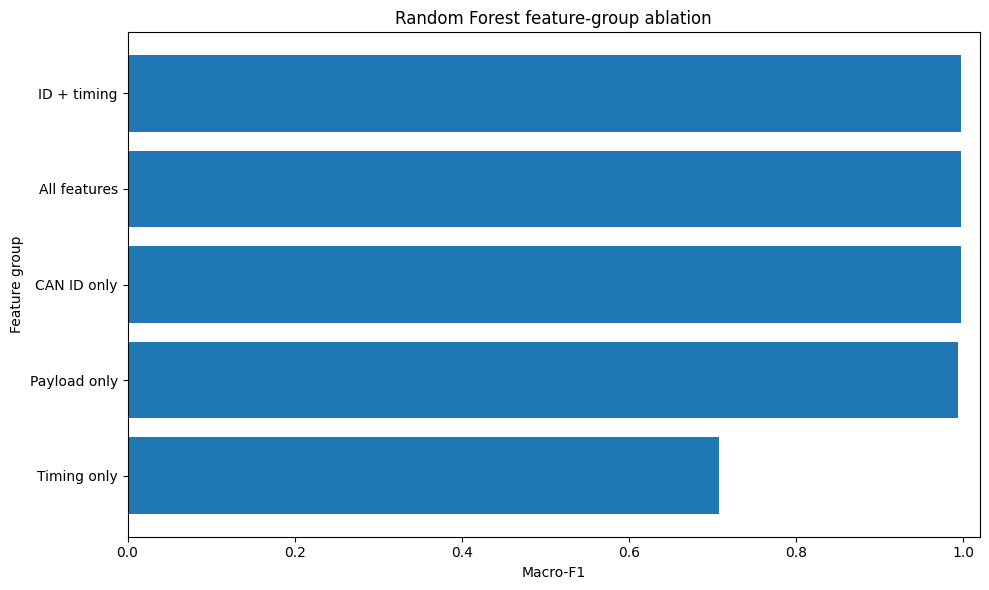

Saved: /kaggle/working/autospectra_outputs/plots/ablation_feature_groups.png


In [129]:

# 18. Feature-group ablation with Random Forest


FEATURE_GROUPS = {
    "Timing only": [
        "duration_s",
        "message_rate_hz",
        "iat_mean_ms",
        "iat_std_ms",
        "iat_p95_ms",
        "iat_max_ms",
    ],
    "CAN ID only": [
        "unique_id_count",
        "id_entropy",
        "max_id_ratio",
        "id_transition_rate",
        "can_id_mean_norm",
        "can_id_std_norm",
        "dominant_id_norm",
        "zero_id_ratio",
    ],
    "Payload only": [
        "dlc_mean",
        "dlc_std",
        "payload_mean",
        "payload_std",
        "payload_entropy",
        "nonzero_byte_ratio",
        "byte_change_mean",
        "byte_change_std",
        "payload_sum_mean",
        "payload_sum_std",
    ],
    "ID + timing": [
        "duration_s",
        "message_rate_hz",
        "iat_mean_ms",
        "iat_std_ms",
        "iat_p95_ms",
        "iat_max_ms",
        "unique_id_count",
        "id_entropy",
        "max_id_ratio",
        "id_transition_rate",
        "can_id_mean_norm",
        "can_id_std_norm",
        "dominant_id_norm",
        "zero_id_ratio",
    ],
    "All features":
        FEATURE_NAMES,
}

ablation_rows = []

if RUN_FEATURE_ABLATION:
    for (
        group_name,
        group_features,
    ) in FEATURE_GROUPS.items():
        indices = [
            FEATURE_NAMES.index(feature)
            for feature in group_features
        ]

        model = RandomForestClassifier(
            n_estimators=(
                140
                if FAST_MODE
                else 250
            ),
            min_samples_leaf=2,
            class_weight=
                "balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        )

        fit_start = time.perf_counter()

        model.fit(
            X_train_tab[:, indices],
            y_train,
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        inference_start = (
            time.perf_counter()
        )

        probabilities = model.predict_proba(
            X_test_tab[:, indices]
        )

        inference_seconds = (
            time.perf_counter()
            - inference_start
        )

        predictions = (
            probabilities.argmax(axis=1)
        )

        binary_matrix = confusion_matrix(
            (y_test != 0).astype(int),
            (predictions != 0).astype(int),
            labels=[0, 1],
        )

        (
            ablation_tn,
            ablation_fp,
            ablation_fn,
            ablation_tp,
        ) = binary_matrix.ravel()

        ablation_rows.append({
            "Feature_Group":
                group_name,
            "Feature_Count":
                len(indices),
            "Macro_F1":
                f1_score(
                    y_test,
                    predictions,
                    average="macro",
                    zero_division=0,
                ),
            "Balanced_Accuracy":
                balanced_accuracy_score(
                    y_test,
                    predictions,
                ),
            "Attack_FPR":
                ablation_fp
                / max(
                    ablation_fp
                    + ablation_tn,
                    1,
                ),
            "Attack_FNR":
                ablation_fn
                / max(
                    ablation_fn
                    + ablation_tp,
                    1,
                ),
            "Training_Seconds":
                fit_seconds,
            "Inference_ms_per_window":
                inference_seconds
                * 1000
                / len(y_test),
        })

    ablation_df = (
        pd.DataFrame(
            ablation_rows
        )
        .sort_values(
            "Macro_F1",
            ascending=False,
        )
    )

    display(ablation_df)

    ablation_df.to_csv(
        OUTPUT_DIR
        / "feature_ablation_results.csv",
        index=False,
    )

    plot_data = (
        ablation_df
        .sort_values("Macro_F1")
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_data["Feature_Group"],
        plot_data["Macro_F1"],
    )

    plt.xlim(0, 1.02)
    plt.title(
        "Random Forest "
        "feature-group ablation"
    )
    plt.xlabel("Macro-F1")
    plt.ylabel("Feature group")

    save_current_figure(
        "ablation_feature_groups.png"
    )

## Optional expensive window-size ablation

Changing the window length requires rescanning and rebuilding the raw dataset. The experiment below is intentionally disabled by default. For the final research run, execute the notebook separately with:

- `WINDOW_SIZE=32, STRIDE=32`
- `WINDOW_SIZE=64, STRIDE=64`
- `WINDOW_SIZE=128, STRIDE=128`

Use different cache hashes and combine the resulting `multiclass_model_comparison.csv` files. This is safer than keeping several large window datasets in one Kaggle process.

In [130]:
# Export the recommended window-ablation plan.
window_ablation_plan = pd.DataFrame([
    {
        "Window_Size": 32,
        "Stride": 32,
        "Purpose":
            "Lower delay, less temporal context",
    },
    {
        "Window_Size": 64,
        "Stride": 64,
        "Purpose":
            "Primary balanced setting",
    },
    {
        "Window_Size": 128,
        "Stride": 128,
        "Purpose":
            "More context, higher delay",
    },
])

display(window_ablation_plan)

window_ablation_plan.to_csv(
    OUTPUT_DIR
    / "window_ablation_plan.csv",
    index=False,
)

if RUN_EXPENSIVE_WINDOW_ABLATION:
    raise NotImplementedError(
        "Run the notebook as three separate Kaggle versions "
        "with the window/stride pairs shown above. "
        "This prevents memory exhaustion and preserves "
        "a complete cache for each experiment."
    )

,Window_Size,Stride,Purpose
0,32,32,"Lower delay, less temporal context"
1,64,64,Primary balanced setting
2,128,128,"More context, higher delay"


# Part H — Plain-language NLP incident reporting

The report generator is deliberately:

- Offline.
- Deterministic.
- Auditable.
- Safe for a live demonstration.
- Independent of an external API.

It converts structured model output into natural language. This is a template-based NLP/NLG component, not a claim of a fine-tuned large language model.

In [131]:

# 19. Structured incident-report generator


SEVERITY_BY_CLASS = {
    "Normal": "Informational",
    "DoS": "Critical",
    "Fuzzy": "High",
    "Gear": "Critical",
    "RPM": "High",
}

RECOMMENDATION_BY_CLASS = {
    "Normal": (
        "Continue monitoring. No automated vehicle-control "
        "action is recommended."
    ),
    "DoS": (
        "Alert the security operator, preserve the CAN trace, "
        "identify the flooding identifier, and isolate the "
        "suspected interface only after human review."
    ),
    "Fuzzy": (
        "Alert the security operator, preserve the trace, "
        "investigate unusual identifiers and payloads, and "
        "verify ECU integrity."
    ),
    "Gear": (
        "Issue a high-priority alert, preserve evidence, "
        "verify transmission-related signals, and require "
        "human confirmation before any intervention."
    ),
    "RPM": (
        "Issue a high-priority alert, preserve evidence, "
        "verify engine-speed signals, and require human "
        "confirmation before any intervention."
    ),
}


def generate_incident_report(
    probabilities: np.ndarray,
    metadata_row: pd.Series,
    feature_values: np.ndarray,
    model_name: str,
):
    predicted_index = int(
        np.argmax(probabilities)
    )

    predicted_class = INDEX_TO_CLASS[
        predicted_index
    ]

    confidence = float(
        np.max(probabilities)
    )

    feature_lookup = dict(
        zip(
            FEATURE_NAMES,
            feature_values,
        )
    )

    severity = SEVERITY_BY_CLASS[
        predicted_class
    ]

    recommendation = (
        RECOMMENDATION_BY_CLASS[
            predicted_class
        ]
    )

    structured_record = {
        "system": "AutoSPECTRA",
        "model": model_name,
        "predicted_class":
            predicted_class,
        "confidence":
            round(confidence, 4),
        "severity": severity,
        "window_start_timestamp":
            float(
                metadata_row[
                    "start_timestamp"
                ]
            ),
        "window_end_timestamp":
            float(
                metadata_row[
                    "end_timestamp"
                ]
            ),
        "window_size_frames":
            WINDOW_SIZE,
        "dominant_can_id":
            metadata_row[
                "dominant_can_id_hex"
            ],
        "message_rate_hz":
            round(
                float(
                    feature_lookup[
                        "message_rate_hz"
                    ]
                ),
                2,
            ),
        "unique_can_ids":
            int(
                round(
                    float(
                        feature_lookup[
                            "unique_id_count"
                        ]
                    )
                )
            ),
        "id_entropy_bits":
            round(
                float(
                    feature_lookup[
                        "id_entropy"
                    ]
                ),
                3,
            ),
        "recommended_action":
            recommendation,
        "human_oversight": (
            "Decision-support alert only. Do not automatically "
            "disable braking, steering, engine, transmission, "
            "or other safety-critical functions."
        ),
    }

    if predicted_class == "Normal":
        narrative = (
            f"AutoSPECTRA analysed a {WINDOW_SIZE}-frame CAN "
            f"window ending at "
            f"{structured_record['window_end_timestamp']:.6f}. "
            f"The {model_name} classified the traffic as normal "
            f"with {confidence:.1%} confidence. The window "
            f"contained approximately "
            f"{structured_record['message_rate_hz']:.1f} "
            f"messages per second and "
            f"{structured_record['unique_can_ids']} unique CAN "
            f"identifiers. Recommended action: {recommendation}"
        )
    else:
        narrative = (
            f"{severity} AutoSPECTRA alert: {predicted_class} "
            f"activity was detected in the CAN window from "
            f"{structured_record['window_start_timestamp']:.6f} "
            f"to {structured_record['window_end_timestamp']:.6f}. "
            f"The {model_name} confidence was {confidence:.1%}. "
            f"The dominant identifier was "
            f"{structured_record['dominant_can_id']}; the window "
            f"contained approximately "
            f"{structured_record['message_rate_hz']:.1f} messages "
            f"per second and "
            f"{structured_record['unique_can_ids']} unique "
            f"identifiers. Recommended action: {recommendation} "
            f"This is a decision-support alert and requires "
            f"human review."
        )

    return structured_record, narrative

In [132]:

# 19. Generate representative incident reports safely

# This version is robust when one or more classes are absent from
# the unseen test split. It only creates reports from genuine test
# windows and never calls np.argmax() on an empty array.

import json
import numpy as np
import pandas as pd

# Prefer the calibrated fusion model when it exists. Otherwise use
# the highest-ranked model in the evaluation table.
preferred_report_model = "Calibrated RF + CNN + LSTM Fusion"

if preferred_report_model in prediction_store:
    selected_model_name = preferred_report_model
else:
    selected_model_name = str(evaluation_df.iloc[0]["Model"])

print(f"Selected incident-report model: {selected_model_name}")

selected_probabilities = np.asarray(
    prediction_store[selected_model_name]["probabilities"]
)
y_test_array = np.asarray(y_test).reshape(-1)
X_test_tab_array = np.asarray(X_test_tab)

test_metadata = (
    DATA["test"]["metadata"]
    .reset_index(drop=True)
)

# Validate that all test objects refer to the same windows.
expected_rows = len(y_test_array)
shape_checks = {
    "probability rows": len(selected_probabilities),
    "metadata rows": len(test_metadata),
    "tabular-feature rows": len(X_test_tab_array),
}

for object_name, row_count in shape_checks.items():
    if row_count != expected_rows:
        raise ValueError(
            f"Mismatch in unseen test data: y_test has {expected_rows} "
            f"rows but {object_name} has {row_count}. Re-run the data, "
            "prediction, and evaluation cells in order."
        )

if selected_probabilities.ndim != 2:
    raise ValueError(
        "The stored probabilities must be a two-dimensional array "
        "with shape (number_of_test_windows, number_of_classes)."
    )

if selected_probabilities.shape[1] != len(CLASS_NAMES):
    raise ValueError(
        "Probability-column count does not match CLASS_NAMES: "
        f"{selected_probabilities.shape[1]} probability columns versus "
        f"{len(CLASS_NAMES)} classes."
    )

# Display the class coverage of the current unseen test split.
unique_test_labels, unique_test_counts = np.unique(
    y_test_array,
    return_counts=True,
)

coverage_rows = []
for class_index, class_name in enumerate(CLASS_NAMES):
    count = int(np.sum(y_test_array == class_index))
    coverage_rows.append({
        "Class_Index": class_index,
        "Class_Name": class_name,
        "Unseen_Test_Windows": count,
        "Report_Status": "Available" if count > 0 else "Absent from test split",
    })

test_class_coverage_df = pd.DataFrame(coverage_rows)
print("\nUnseen test-set class coverage:")
display(test_class_coverage_df)

predicted_class_indices = np.argmax(
    selected_probabilities,
    axis=1,
)

report_rows = []
missing_report_classes = []

for class_index, class_name in enumerate(CLASS_NAMES):
    # Indices of genuine unseen windows with this true class.
    candidate_indices = np.flatnonzero(
        y_test_array == class_index
    )

    if candidate_indices.size == 0:
        missing_report_classes.append(class_name)
        print("\n" + "=" * 100)
        print(f"TRUE CLASS: {class_name}")
        print(
            "No unseen test windows for this class are present in the "
            "current split. The class is skipped rather than using a "
            "training or validation example."
        )
        continue

    # Prefer a correctly classified window. If none exists, select the
    # window receiving the largest probability for its true class.
    correctly_classified = candidate_indices[
        predicted_class_indices[candidate_indices] == class_index
    ]

    if correctly_classified.size > 0:
        selection_pool = correctly_classified
        selection_status = "Correctly classified unseen test window"
    else:
        selection_pool = candidate_indices
        selection_status = (
            "No correctly classified window available; selected the "
            "largest true-class probability"
        )

    true_class_scores = selected_probabilities[
        selection_pool,
        class_index,
    ]

    selected_index = int(
        selection_pool[int(np.argmax(true_class_scores))]
    )

    structured, narrative = generate_incident_report(
        selected_probabilities[selected_index],
        test_metadata.iloc[selected_index],
        X_test_tab_array[selected_index],
        selected_model_name,
    )

    predicted_class = str(structured["predicted_class"])
    confidence = float(structured["confidence"])
    true_class_probability = float(
        selected_probabilities[selected_index, class_index]
    )

    report_rows.append({
        "Test_Index": selected_index,
        "True_Class": class_name,
        "Predicted_Class": predicted_class,
        "Correct_Prediction": predicted_class == class_name,
        "Selection_Status": selection_status,
        "Confidence": confidence,
        "True_Class_Probability": true_class_probability,
        "Narrative": narrative,
        "Structured_JSON": json.dumps(
            structured,
            ensure_ascii=False,
        ),
    })

    print("\n" + "=" * 100)
    print(f"TRUE CLASS      : {class_name}")
    print(f"PREDICTED CLASS : {predicted_class}")
    print(f"TEST INDEX      : {selected_index}")
    print(f"SELECTION       : {selection_status}")
    print(f"CONFIDENCE      : {confidence:.4f}")
    print(f"TRUE-CLASS PROB.: {true_class_probability:.4f}")
    print("-" * 100)
    print(narrative)
    print("-" * 100)
    print(
        json.dumps(
            structured,
            indent=2,
            ensure_ascii=False,
        )
    )

report_columns = [
    "Test_Index",
    "True_Class",
    "Predicted_Class",
    "Correct_Prediction",
    "Selection_Status",
    "Confidence",
    "True_Class_Probability",
    "Narrative",
    "Structured_JSON",
]

incident_reports_df = pd.DataFrame(
    report_rows,
    columns=report_columns,
)

csv_report_path = REPORT_DIR / "example_incident_reports.csv"
json_report_path = REPORT_DIR / "example_incident_reports.json"
coverage_report_path = REPORT_DIR / "test_class_coverage.csv"

incident_reports_df.to_csv(
    csv_report_path,
    index=False,
)

test_class_coverage_df.to_csv(
    coverage_report_path,
    index=False,
)

structured_report_records = [
    json.loads(value)
    for value in incident_reports_df["Structured_JSON"].tolist()
]

with json_report_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        structured_report_records,
        handle,
        indent=2,
        ensure_ascii=False,
    )

print("\n" + "=" * 100)
print("INCIDENT REPORT GENERATION COMPLETE")
print("=" * 100)
print(f"Reports generated : {len(incident_reports_df)}")
print(f"CSV report        : {csv_report_path}")
print(f"JSON report       : {json_report_path}")
print(f"Class coverage    : {coverage_report_path}")

if missing_report_classes:
    print(
        "\nClasses absent from the current unseen test split: "
        + ", ".join(missing_report_classes)
    )
    print(
        "This is expected when a strict chronological split leaves "
        "some capture classes outside the final test period."
    )

display(incident_reports_df)


Selected incident-report model: Calibrated RF + CNN + LSTM Fusion

Unseen test-set class coverage:


,Class_Index,Class_Name,Unseen_Test_Windows,Report_Status
0,0,Normal,800,Available
1,1,DoS,800,Available
2,2,Fuzzy,800,Available
3,3,Gear,800,Available
4,4,RPM,800,Available



TRUE CLASS      : Normal
PREDICTED CLASS : Normal
TEST INDEX      : 503
SELECTION       : Correctly classified unseen test window
CONFIDENCE      : 1.0000
TRUE-CLASS PROB.: 1.0000
----------------------------------------------------------------------------------------------------
AutoSPECTRA analysed a 64-frame CAN window ending at 1478201156.284908. The Calibrated RF + CNN + LSTM Fusion classified the traffic as normal with 100.0% confidence. The window contained approximately 1928.8 messages per second and 21 unique CAN identifiers. Recommended action: Continue monitoring. No automated vehicle-control action is recommended.
----------------------------------------------------------------------------------------------------
{
  "system": "AutoSPECTRA",
  "model": "Calibrated RF + CNN + LSTM Fusion",
  "predicted_class": "Normal",
  "confidence": 1.0,
  "severity": "Informational",
  "window_start_timestamp": 1478201156.251726,
  "window_end_timestamp": 1478201156.284908,
  "window_si

,Test_Index,True_Class,Predicted_Class,Correct_Prediction,Selection_Status,Confidence,True_Class_Probability,Narrative,Structured_JSON
0,503,Normal,Normal,True,Correctly classified unseen test window,1.0,0.999982,AutoSPECTRA analysed a 64-frame CAN window end...,"{""system"": ""AutoSPECTRA"", ""model"": ""Calibrated..."
1,2917,DoS,DoS,True,Correctly classified unseen test window,1.0,0.999993,Critical AutoSPECTRA alert: DoS activity was d...,"{""system"": ""AutoSPECTRA"", ""model"": ""Calibrated..."
2,2447,Fuzzy,Fuzzy,True,Correctly classified unseen test window,1.0,0.999995,High AutoSPECTRA alert: Fuzzy activity was det...,"{""system"": ""AutoSPECTRA"", ""model"": ""Calibrated..."
3,2869,Gear,Gear,True,Correctly classified unseen test window,1.0,0.999994,Critical AutoSPECTRA alert: Gear activity was ...,"{""system"": ""AutoSPECTRA"", ""model"": ""Calibrated..."
4,3243,RPM,RPM,True,Correctly classified unseen test window,1.0,0.999998,High AutoSPECTRA alert: RPM activity was detec...,"{""system"": ""AutoSPECTRA"", ""model"": ""Calibrated..."


# Part I — Live-demonstration cell

For the pitch, run this cell after all models are loaded. It selects one unseen test window, shows the recurrence image, compares model probabilities, and prints the final incident report.

The demo does not use screenshots or prerecorded output.

Live-demo true class : Gear
Live-demo test index : 2869


,Model,Prediction,Confidence,P(Normal),P(DoS),P(Fuzzy),P(Gear),P(RPM)
0,Logistic Regression,Gear,0.999995,1.201770e-09,4.468773e-08,1.440286e-10,0.999995,0.000004
1,Random Forest,Gear,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000
2,Extra Trees,Gear,0.997471,1.662477e-04,6.758035e-07,1.351607e-06,0.997471,0.002361
3,XGBoost,Gear,0.999802,4.431256e-05,3.221788e-05,2.535589e-05,0.999802,0.000096
4,Recurrence CNN,Gear,0.999465,9.488378e-05,9.643764e-05,1.816238e-05,0.999465,0.000326
5,LSTM Classifier,Gear,0.986645,3.296785e-03,3.425985e-03,2.877073e-03,0.986645,0.003755
6,RF + CNN + LSTM Fusion,Gear,0.995351,1.135445e-03,1.179229e-03,9.695940e-04,0.995351,0.001365
7,Calibrated RF + CNN + LSTM Fusion,Gear,0.999994,1.301300e-06,1.403595e-06,9.489103e-07,0.999994,0.000002


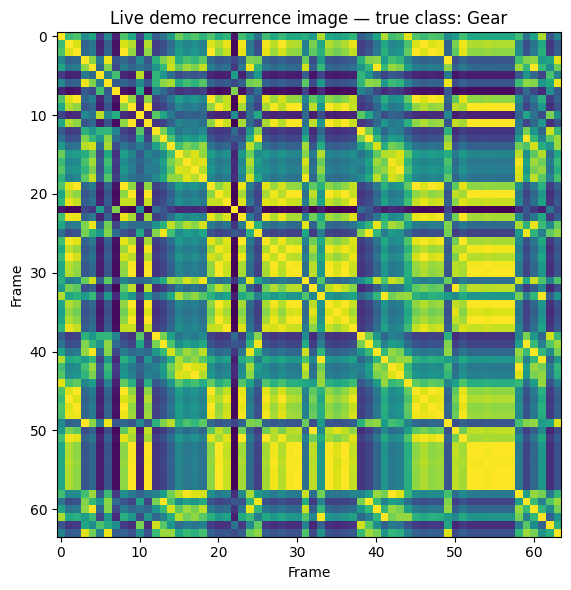


FINAL INCIDENT REPORT

Critical AutoSPECTRA alert: Gear activity was detected in the CAN window from 1478195119.443586 to 1478195119.567996. The Calibrated RF + CNN + LSTM Fusion confidence was 100.0%. The dominant identifier was 0x43F; the window contained approximately 514.4 messages per second and 20 unique identifiers. Recommended action: Issue a high-priority alert, preserve evidence, verify transmission-related signals, and require human confirmation before any intervention. This is a decision-support alert and requires human review.

STRUCTURED RECORD

{
  "system": "AutoSPECTRA",
  "model": "Calibrated RF + CNN + LSTM Fusion",
  "predicted_class": "Gear",
  "confidence": 1.0,
  "severity": "Critical",
  "window_start_timestamp": 1478195119.443586,
  "window_end_timestamp": 1478195119.567996,
  "window_size_frames": 64,
  "dominant_can_id": "0x43F",
  "message_rate_hz": 514.43,
  "unique_can_ids": 20,
  "id_entropy_bits": 3.33,
  "recommended_action": "Issue a high-priority ale

In [133]:

# 20. One-window live demonstration (safe class fallback)


DEMO_TRUE_CLASS = "Gear"
# Change to Normal, DoS, Fuzzy, Gear, or RPM.

if DEMO_TRUE_CLASS not in CLASS_TO_INDEX:
    raise ValueError(
        f"Unknown DEMO_TRUE_CLASS={DEMO_TRUE_CLASS!r}. "
        f"Choose one of: {', '.join(CLASS_NAMES)}"
    )

requested_class_index = CLASS_TO_INDEX[DEMO_TRUE_CLASS]
demo_candidates = np.flatnonzero(
    y_test_array == requested_class_index
)

# A strict chronological split may not contain every class. For a
# reliable live demonstration, fall back to the first class that is
# genuinely present in the unseen test set.
if demo_candidates.size == 0:
    available_indices = [
        class_index
        for class_index in range(len(CLASS_NAMES))
        if np.any(y_test_array == class_index)
    ]

    if not available_indices:
        raise ValueError(
            "The unseen test split contains no windows. Re-run the "
            "data preparation and split cells."
        )

    fallback_class_index = int(available_indices[0])
    fallback_class_name = CLASS_NAMES[fallback_class_index]

    print(
        f"Requested demo class '{DEMO_TRUE_CLASS}' is absent from "
        f"the current unseen test split. Using '{fallback_class_name}' "
        "instead."
    )

    DEMO_TRUE_CLASS = fallback_class_name
    requested_class_index = fallback_class_index
    demo_candidates = np.flatnonzero(
        y_test_array == requested_class_index
    )

# Prefer a correctly classified and highly confident example for a
# clear demonstration. If none is correct, use the strongest true-
# class probability among the available unseen windows.
correct_demo_candidates = demo_candidates[
    predicted_class_indices[demo_candidates] == requested_class_index
]

demo_selection_pool = (
    correct_demo_candidates
    if correct_demo_candidates.size > 0
    else demo_candidates
)

demo_true_class_scores = selected_probabilities[
    demo_selection_pool,
    requested_class_index,
]

demo_index = int(
    demo_selection_pool[int(np.argmax(demo_true_class_scores))]
)

print(f"Live-demo true class : {DEMO_TRUE_CLASS}")
print(f"Live-demo test index : {demo_index}")

demo_probability_rows = []

for model_name, stored in prediction_store.items():
    probabilities = np.asarray(
        stored["probabilities"]
    )[demo_index]

    demo_probability_rows.append({
        "Model": model_name,
        "Prediction": INDEX_TO_CLASS[
            int(np.argmax(probabilities))
        ],
        "Confidence": float(np.max(probabilities)),
        **{
            f"P({class_name})": float(
                probabilities[class_index]
            )
            for class_index, class_name in enumerate(CLASS_NAMES)
        },
    })

demo_probability_df = pd.DataFrame(demo_probability_rows)
display(demo_probability_df)

demo_recurrence = sequence_to_recurrence(
    X_test_seq[demo_index]
)

plt.figure(figsize=(6, 6))
plt.imshow(demo_recurrence)
plt.title(
    "Live demo recurrence image — "
    f"true class: {DEMO_TRUE_CLASS}"
)
plt.xlabel("Frame")
plt.ylabel("Frame")
plt.tight_layout()
plt.show()

structured_demo, narrative_demo = generate_incident_report(
    selected_probabilities[demo_index],
    test_metadata.iloc[demo_index],
    X_test_tab_array[demo_index],
    selected_model_name,
)

print("\nFINAL INCIDENT REPORT\n")
print(narrative_demo)

print("\nSTRUCTURED RECORD\n")
print(
    json.dumps(
        structured_demo,
        indent=2,
        ensure_ascii=False,
    )
)


# Part J — Ethics, responsible AI, and limitations

## Safety-critical error asymmetry

- **False negative:** an attack is missed. This may allow malicious traffic to continue without an alert.
- **False positive:** normal traffic is treated as malicious. Excessive false alarms can distract operators, reduce trust, and cause unsafe responses if alerts are linked directly to automatic control.

AutoSPECTRA is therefore positioned as a **decision-support alerting prototype**, not an autonomous system for disabling an ECU or controlling a vehicle.

## Dual use

The project analyses public attack captures for defensive detection. The repository should not include instructions or scripts for attacking a real vehicle. Findings should be presented through responsible disclosure and defensive recommendations.

## Privacy

The public dataset contains CAN traces rather than direct personal identifiers. In deployment, however, CAN and telematics data may reveal driving behaviour and, when combined with other systems, location or usage patterns. Local processing and data minimisation are therefore recommended.

## Dataset bias and generalisation

The HCRL captures come from one real vehicle and four relatively conspicuous message-injection attacks. High test performance does not demonstrate universal protection across manufacturers, vehicle models, unseen ECUs, stealth attacks, or adversarial manipulation.

## Known methodological limitations

1. The per-file blocked split reduces temporal leakage but still evaluates different periods of the same vehicle and capture type.
2. Normal windows originate from attack-capture files; they may contain capture-session artefacts.
3. `R` and `T` are frame labels, while this project predicts window labels.
4. A window with one injected frame is labelled as an attack, which favours early detection but creates mixed windows.
5. Detection latency is estimated from recorded timestamps and window boundaries, not measured on an ECU.
6. Recurrence images are a designed representation and must be justified against simpler sequence/tabular models.
7. Confidence values require calibration and human interpretation.
8. Cross-vehicle validation is future work, ideally using ROAD or a multi-vehicle curated dataset.

## Responsible deployment principle

No prediction should automatically disable braking, steering, engine, transmission, or other safety-critical functionality. A qualified operator should review the alert and supporting evidence.

# Part K — Save reproducibility package

In [134]:

# 21. Export configuration, summaries, requirements, and ZIP


with (
    OUTPUT_DIR
    / "class_mapping.json"
).open("w") as handle:
    json.dump(
        CLASS_TO_INDEX,
        handle,
        indent=2,
    )

experiment_summary = {
    "project": "AutoSPECTRA",
    "dataset":
        "HCRL Car-Hacking Dataset via Kaggle",
    "classes": CLASS_NAMES,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "split_strategy": SPLIT_STRATEGY,
    "chronological_split": {
        "train": TRAIN_FRACTION,
        "validation": VALID_FRACTION,
        "test": TEST_FRACTION,
    },
    "fast_mode": FAST_MODE,
    "best_multiclass_model":
        evaluation_df.iloc[0]["Model"],
    "best_macro_f1":
        float(
            evaluation_df.iloc[0][
                "Macro_F1"
            ]
        ),
    "device": str(DEVICE),
    "seed": SEED,
}

if autoencoder_results is not None:
    experiment_summary[
        "autoencoder_binary_results"
    ] = {
        key: (
            float(value)
            if isinstance(
                value,
                (
                    np.floating,
                    np.integer,
                ),
            )
            else value
        )
        for key, value
        in autoencoder_results.items()
    }

with (
    OUTPUT_DIR
    / "experiment_summary.json"
).open("w") as handle:
    json.dump(
        experiment_summary,
        handle,
        indent=2,
    )

requirements_text = "\n".join([
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "xgboost",
    "joblib",
    "torch",
    "",
])

(
    OUTPUT_DIR
    / "requirements.txt"
).write_text(
    requirements_text
)

readme_lines = [
    "# AutoSPECTRA Output Package",
    "",
    "## Primary experiment",
    (
        "- Classes: "
        + ", ".join(CLASS_NAMES)
    ),
    (
        "- Window size: "
        + str(WINDOW_SIZE)
    ),
    (
        "- Stride: "
        + str(STRIDE)
    ),
    (
        "- Split: source-aware and class-stratified chronological "
        "70% train / 15% validation / 15% test"
    ),
    (
        "- Best multiclass model: "
        + str(
            evaluation_df.iloc[0][
                "Model"
            ]
        )
    ),
    (
        "- Best macro-F1: "
        + f"{evaluation_df.iloc[0]['Macro_F1']:.6f}"
    ),
    "",
    "## Important files",
    (
        "- `multiclass_model_comparison.csv`: "
        "model-level metrics"
    ),
    (
        "- `per_class_metrics.csv`: "
        "class-wise precision, recall, and F1"
    ),
    (
        "- `estimated_detection_latency.csv`: "
        "window-based latency estimate"
    ),
    (
        "- `feature_ablation_results.csv`: "
        "Random Forest feature-group ablation"
    ),
    "- `models/`: serialised models",
    "- `plots/`: report- and pitch-ready figures",
    (
        "- `reports/`: structured and plain-language "
        "incident reports"
    ),
    "",
    "## Reproducibility",
    (
        "Attach Kaggle dataset "
        "`pranavjha24/car-hacking-dataset`, "
        "enable a GPU, and run the notebook "
        "from the first cell."
    ),
    "",
]

(
    OUTPUT_DIR
    / "README.md"
).write_text(
    "\n".join(readme_lines)
)

import shutil

zip_base = Path(
    "/kaggle/working/"
    "AutoSPECTRA_Artifacts"
)

zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Experiment complete.")
print(
    "Output directory:",
    OUTPUT_DIR,
)
print(
    "ZIP package:",
    zip_path,
)
print(
    json.dumps(
        experiment_summary,
        indent=2,
    )
)

Experiment complete.
Output directory: /kaggle/working/autospectra_outputs
ZIP package: /kaggle/working/AutoSPECTRA_Artifacts.zip
{
  "project": "AutoSPECTRA",
  "dataset": "HCRL Car-Hacking Dataset via Kaggle",
  "classes": [
    "Normal",
    "DoS",
    "Fuzzy",
    "Gear",
    "RPM"
  ],
  "window_size": 64,
  "stride": 64,
  "split_strategy": "source_class_chronological_v3",
  "chronological_split": {
    "train": 0.7,
    "validation": 0.15,
    "test": 0.15
  },
  "fast_mode": true,
  "best_multiclass_model": "Random Forest",
  "best_macro_f1": 0.9977540222586209,
  "device": "cuda",
  "seed": 42,
  "autoencoder_binary_results": {
    "Model": "LSTM Autoencoder (binary)",
    "Threshold_Method": "Validation_F1_with_FPR_constraint",
    "Score_Direction": "higher_is_attack",
    "Threshold": 0.06893573568761349,
    "Accuracy": 0.6895,
    "Precision": 0.9557728119180633,
    "Recall": 0.6415625,
    "F1": 0.7677636499626028,
    "ROC_AUC": 0.7135414062500001,
    "PR_AUC": 0.9321

# References and dataset attribution

The primary experiment uses the HCRL Car-Hacking Dataset distributed through
Kaggle. The notebook retains the original Normal, DoS, Fuzzy, Gear-spoofing
and RPM-spoofing semantics and does not use the attack flag as a model input.

The corrected evaluation follows a source-aware, class-stratified
chronological design so every unseen test class has genuine support. Metrics
must be interpreted together with the single-vehicle limitation and should
not be presented as proof of universal automotive deployment readiness.


# Part L — Build the complete Flask deployment ZIP

Run the following cell **after all training and model-export cells have completed**. It will:

1. Create the full `AutoSPECTRA_Flask_App` folder in `/kaggle/working`.
2. Include Flask source code, templates, styling, JavaScript, requirements, launch scripts, README, and a sample CAN file.
3. Copy all trained classical and deep-learning model artifacts from `autospectra_outputs/models`.
4. Export the exact validation-derived fusion weights and calibration temperature when available.
5. Add experiment configuration and a deployment manifest.
6. Create `AutoSPECTRA_Flask_Deployment.zip` and display a Kaggle download link.

The resulting ZIP can be extracted and run locally with `run_local.bat` on Windows or `run_local.sh` on Linux/macOS.


In [135]:

# 22. Build a self-contained AutoSPECTRA Flask deployment ZIP


import base64
import io
import json
import os
import shutil
import zipfile
from datetime import datetime, timezone
from pathlib import Path
from IPython.display import FileLink, display

# The Flask application template is embedded in this notebook so no
# additional upload is needed when the training run finishes.
FLASK_TEMPLATE_BASE64 = """..."""

WORKING_DIR = Path("/kaggle/working")
if not WORKING_DIR.exists():
    # This fallback only helps when testing the notebook outside Kaggle.
    WORKING_DIR = Path.cwd()

FLASK_APP_DIR = WORKING_DIR / "AutoSPECTRA_Flask_App"
FINAL_ZIP_BASE = WORKING_DIR / "AutoSPECTRA_Flask_Deployment"
FINAL_ZIP_PATH = FINAL_ZIP_BASE.with_suffix(".zip")

# Rebuild the folder cleanly so stale model files cannot enter the package.
if FLASK_APP_DIR.exists():
    shutil.rmtree(FLASK_APP_DIR)
FLASK_APP_DIR.mkdir(parents=True, exist_ok=True)

# Decode and extract every Flask-required source file.
template_bytes = base64.b64decode(FLASK_TEMPLATE_BASE64.encode("ascii"))
with zipfile.ZipFile(io.BytesIO(template_bytes), "r") as archive:
    archive.extractall(FLASK_APP_DIR)

for required_dir in ("models", "uploads", "results"):
    (FLASK_APP_DIR / required_dir).mkdir(parents=True, exist_ok=True)

# Resolve the trained-model directory produced by this notebook.
if "MODEL_DIR" in globals():
    TRAINED_MODEL_DIR = Path(MODEL_DIR)
else:
    TRAINED_MODEL_DIR = WORKING_DIR / "autospectra_outputs" / "models"

if not TRAINED_MODEL_DIR.exists():
    raise FileNotFoundError(
        f"Trained model directory not found: {TRAINED_MODEL_DIR}. "
        "Run all model-training/export cells before this Flask packaging cell."
    )

FLASK_MODEL_DIR = FLASK_APP_DIR / "models"
known_model_files = [
    "random_forest.joblib",
    "extra_trees.joblib",
    "logistic_regression.joblib",
    "xgboost.joblib",
    "recurrence_cnn.pt",
    "lstm_classifier.pt",
    "lstm_autoencoder.pt",
    "fusion_weights.json",
    "fusion_calibration.json",
    "autoencoder_threshold.json",
]

copied_models = []
for filename in known_model_files:
    source = TRAINED_MODEL_DIR / filename
    if source.exists() and source.is_file():
        destination = FLASK_MODEL_DIR / filename
        shutil.copy2(source, destination)
        copied_models.append(filename)

# Copy any additional JSON/joblib/PT artifacts without overwriting the
# explicitly copied files. This future-proofs the package for later models.
for source in TRAINED_MODEL_DIR.iterdir():
    if source.is_file() and source.suffix.lower() in {".json", ".joblib", ".pt", ".pth"}:
        destination = FLASK_MODEL_DIR / source.name
        if not destination.exists():
            shutil.copy2(source, destination)
            copied_models.append(source.name)

if "random_forest.joblib" not in copied_models:
    raise FileNotFoundError(
        "random_forest.joblib was not found. The Flask app requires at least "
        "one trained classifier; rerun the classical-model training cell."
    )

# Export exact fusion weights and temperature in the structure expected by
# the Flask ModelRegistry. The app still works with Random Forest if the deep
# models were intentionally disabled.
fusion_payload = None
if "fusion_weights" in globals():
    fusion_payload = {
        "weights": {
            str(name): float(value)
            for name, value in fusion_weights.items()
        },
        "temperature": float(globals().get("best_temperature", 1.0)),
        "selection": "validation macro-F1 weights plus validation log-loss temperature",
    }
else:
    legacy_weights_path = TRAINED_MODEL_DIR / "fusion_weights.json"
    if legacy_weights_path.exists():
        legacy_weights = json.loads(legacy_weights_path.read_text(encoding="utf-8"))
        calibration_path = TRAINED_MODEL_DIR / "fusion_calibration.json"
        temperature = 1.0
        if calibration_path.exists():
            temperature = float(
                json.loads(calibration_path.read_text(encoding="utf-8")).get(
                    "temperature", 1.0
                )
            )
        fusion_payload = {
            "weights": {str(name): float(value) for name, value in legacy_weights.items()},
            "temperature": temperature,
            "selection": "loaded from exported notebook JSON files",
        }

if fusion_payload is not None:
    (FLASK_MODEL_DIR / "fusion_config.json").write_text(
        json.dumps(fusion_payload, indent=2),
        encoding="utf-8",
    )
    if "fusion_config.json" not in copied_models:
        copied_models.append("fusion_config.json")

# Copy useful experiment outputs into the deployment package.
OUTPUT_SOURCE = Path(globals().get("OUTPUT_DIR", WORKING_DIR / "autospectra_outputs"))
for filename in (
    "class_mapping.json",
    "experiment_summary.json",
    "multiclass_model_comparison.csv",
    "per_class_metrics.csv",
    "estimated_detection_latency.csv",
):
    source = OUTPUT_SOURCE / filename
    if source.exists():
        shutil.copy2(source, FLASK_APP_DIR / filename)

# Save a deployment-specific configuration and audit manifest.
deployment_config = {
    "project": "AutoSPECTRA",
    "classes": list(globals().get("CLASS_NAMES", ["Normal", "DoS", "Fuzzy", "Gear", "RPM"])),
    "window_size": int(globals().get("WINDOW_SIZE", 64)),
    "recommended_stride": int(globals().get("STRIDE", 64)),
    "feature_count": len(globals().get("FEATURE_NAMES", [])) or 24,
    "minimum_required_model": "random_forest.joblib",
    "copied_model_artifacts": sorted(set(copied_models)),
    "fusion_enabled": all(
        filename in copied_models
        for filename in ("random_forest.joblib", "recurrence_cnn.pt", "lstm_classifier.pt", "fusion_config.json")
    ),
    "generated_utc": datetime.now(timezone.utc).isoformat(),
}

(FLASK_APP_DIR / "deployment_manifest.json").write_text(
    json.dumps(deployment_config, indent=2),
    encoding="utf-8",
)

# Create a runtime .env example containing the trained window size.
(FLASK_APP_DIR / ".env.example").write_text(
    "\n".join([
        "FLASK_SECRET_KEY=replace-with-a-random-secret",
        f"AUTOSPECTRA_WINDOW_SIZE={deployment_config['window_size']}",
        f"AUTOSPECTRA_STRIDE={deployment_config['recommended_stride']}",
        "AUTOSPECTRA_MAX_WINDOWS=5000",
        "AUTOSPECTRA_MAX_UPLOAD_MB=300",
        "PORT=5000",
        "",
    ]),
    encoding="utf-8",
)

# Remove runtime files that should not enter a clean submission package.
for cache_dir in FLASK_APP_DIR.rglob("__pycache__"):
    shutil.rmtree(cache_dir, ignore_errors=True)
for pyc_file in FLASK_APP_DIR.rglob("*.pyc"):
    pyc_file.unlink(missing_ok=True)

# Build the downloadable archive. The ZIP contains the application folder as
# its top-level directory, making extraction clean on Windows/macOS/Linux.
if FINAL_ZIP_PATH.exists():
    FINAL_ZIP_PATH.unlink()
with zipfile.ZipFile(
    FINAL_ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=9,
) as archive:
    for path in sorted(FLASK_APP_DIR.rglob("*")):
        if path.is_file():
            archive_name = Path(FLASK_APP_DIR.name) / path.relative_to(FLASK_APP_DIR)
            archive.write(path, archive_name.as_posix())

# Verify the most important files before presenting the download link.
required_files = [
    "app.py",
    "requirements.txt",
    "README.md",
    "autospectra/config.py",
    "autospectra/modeling.py",
    "autospectra/preprocessing.py",
    "autospectra/reporting.py",
    "templates/index.html",
    "templates/results.html",
    "static/css/style.css",
    "models/random_forest.joblib",
    "deployment_manifest.json",
]
missing_files = [
    filename
    for filename in required_files
    if not (FLASK_APP_DIR / filename).exists()
]
if missing_files:
    raise RuntimeError(f"Flask export is incomplete. Missing: {missing_files}")

print("AutoSPECTRA Flask package created successfully.")
print("Application folder:", FLASK_APP_DIR)
print("Model artifacts copied:", sorted(set(copied_models)))
print("Fusion enabled:", deployment_config["fusion_enabled"])
print("ZIP size (MB):", round(FINAL_ZIP_PATH.stat().st_size / (1024 ** 2), 2))
print("Download from Kaggle Output using the link below:")
display(FileLink(str(FINAL_ZIP_PATH)))


AutoSPECTRA Flask package created successfully.
Application folder: /kaggle/working/AutoSPECTRA_Flask_App
Model artifacts copied: ['autoencoder_threshold.json', 'extra_trees.joblib', 'fusion_calibration.json', 'fusion_config.json', 'fusion_weights.json', 'logistic_regression.joblib', 'lstm_autoencoder.pt', 'lstm_classifier.pt', 'random_forest.joblib', 'recurrence_cnn.pt', 'xgboost.joblib']
Fusion enabled: True
ZIP size (MB): 3.22
Download from Kaggle Output using the link below:


/kaggle/working/AutoSPECTRA_Flask_Deployment.zip

## Run the exported Flask application

After downloading and extracting the ZIP:

**Windows**
```bat
run_local.bat
```

**Linux/macOS**
```bash
chmod +x run_local.sh
./run_local.sh
```

Then open `http://127.0.0.1:5000`. The application uses the packaged model files and does not require the training notebook to be running. For a Kaggle public demonstration, follow the ngrok instructions in the packaged `README.md`.
